# Modified Determinat

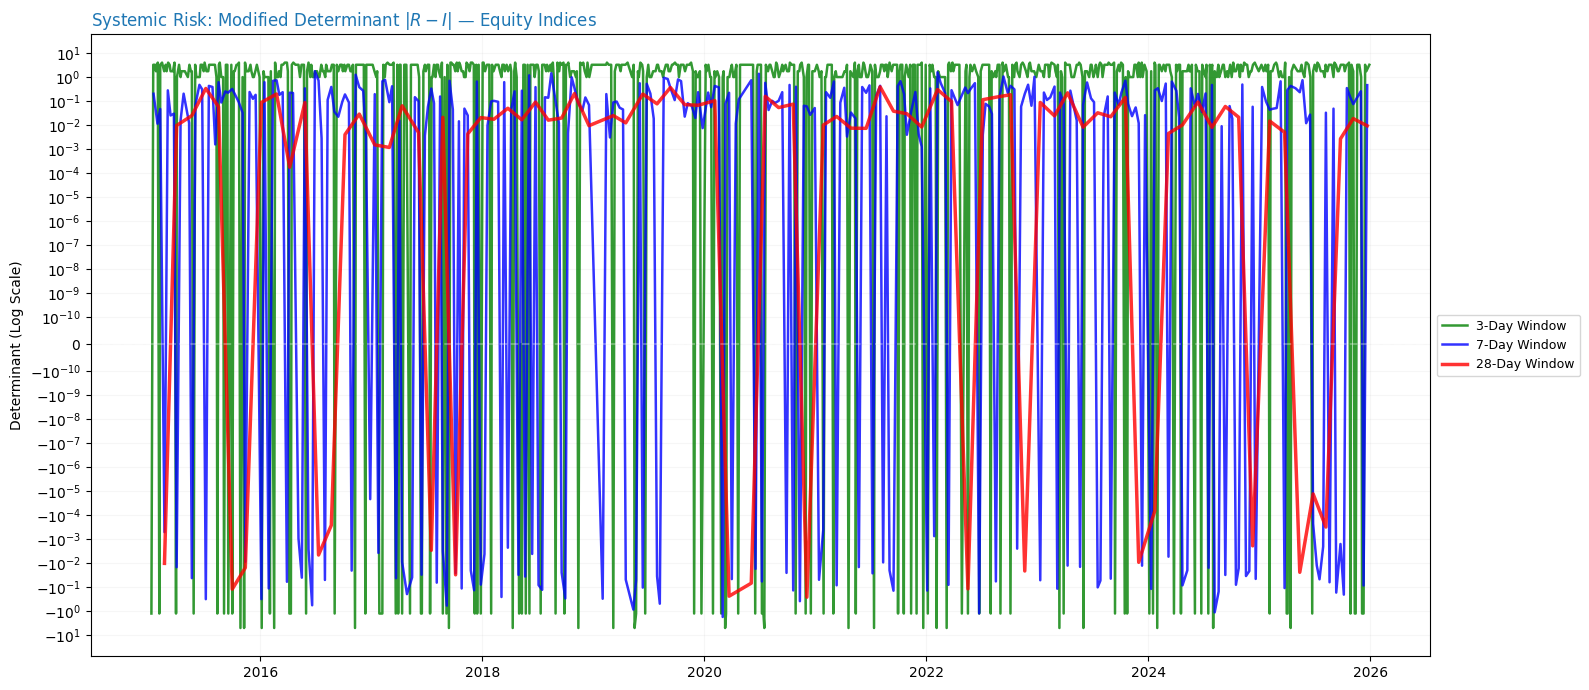

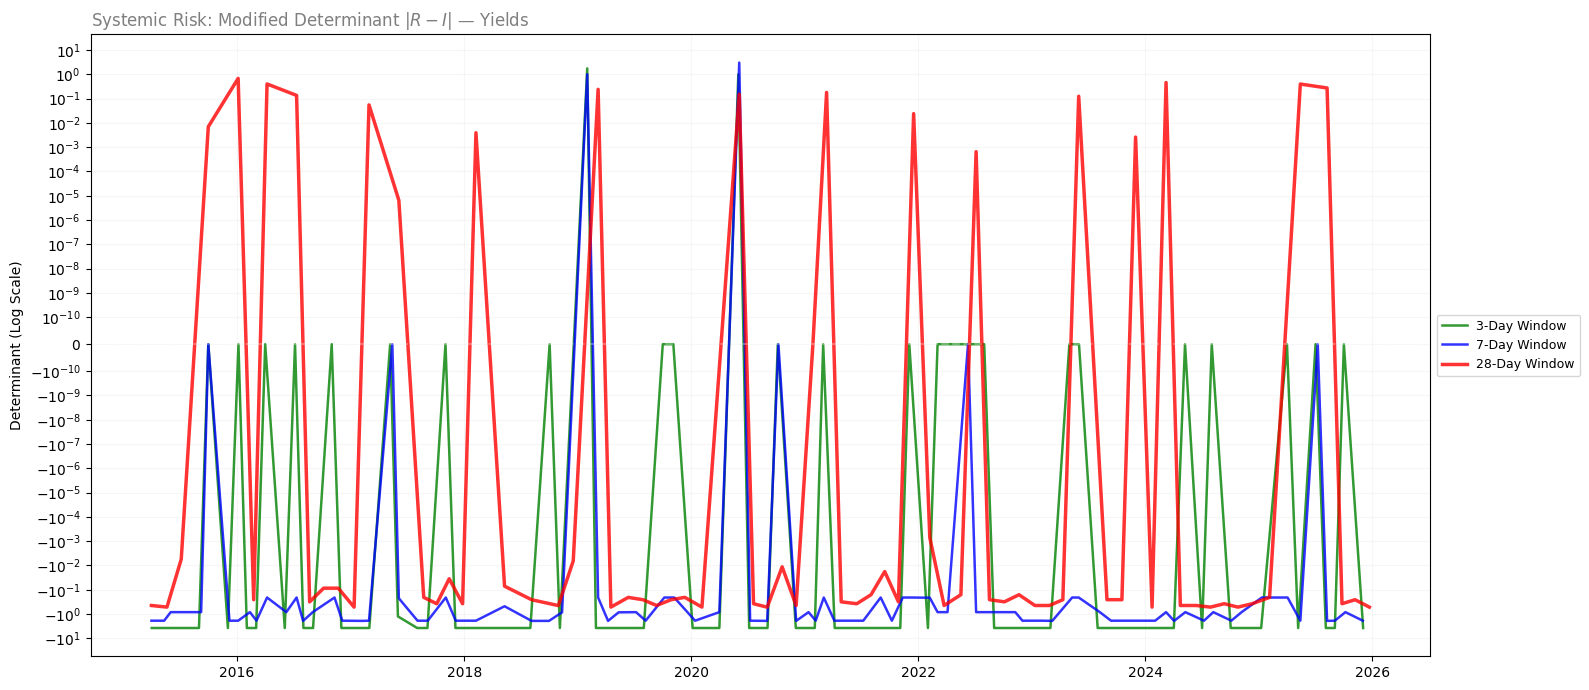

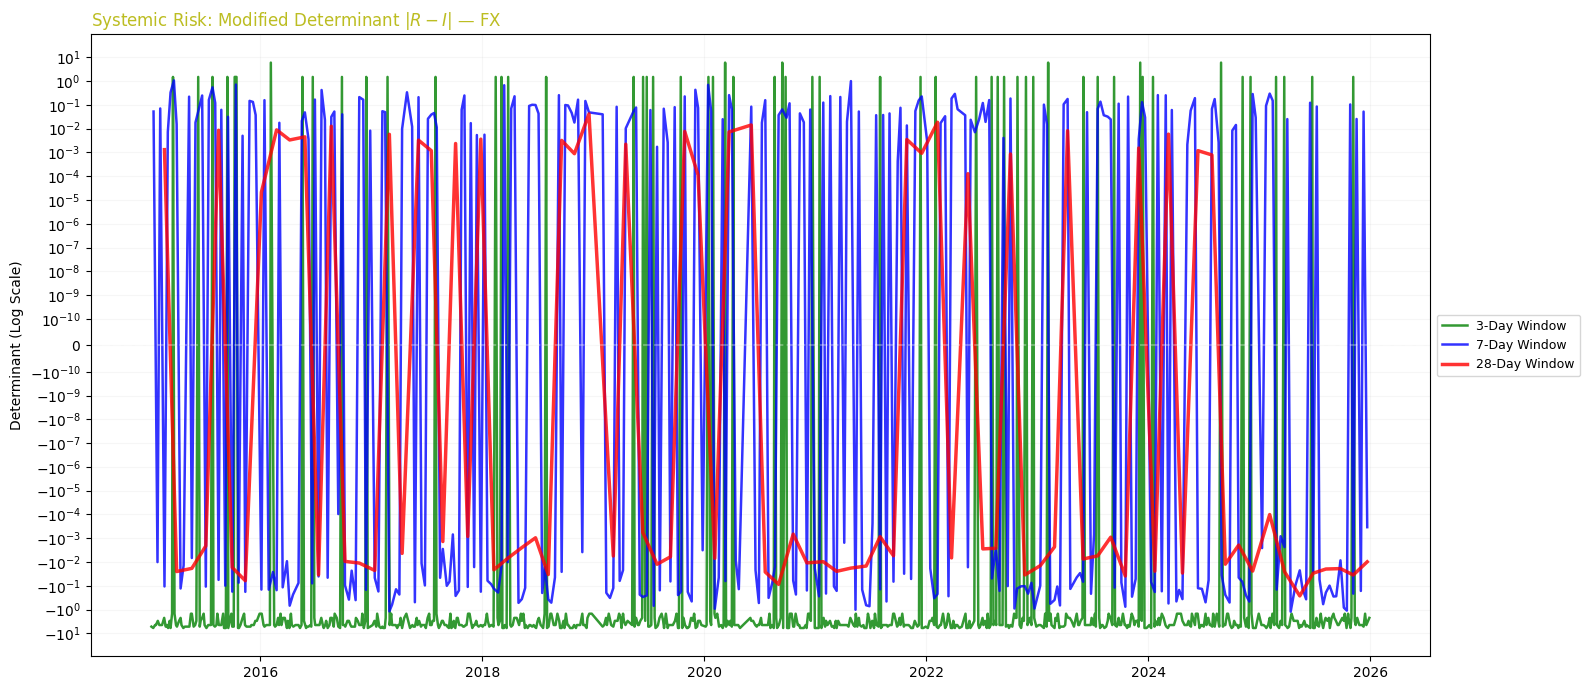

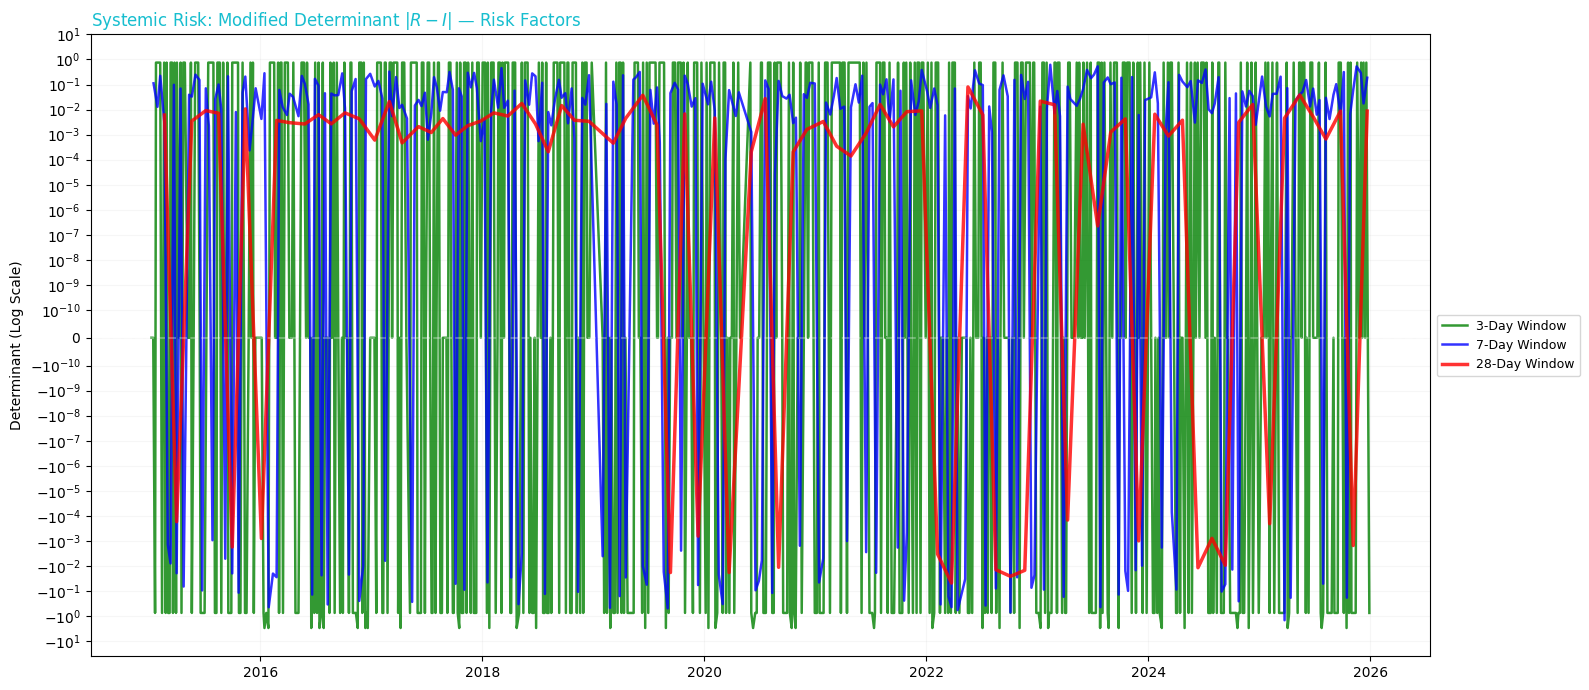

In [2]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import StringIO
import hashlib

# 1. Load data from GitHub
def load_data_from_github():
    base_url = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"
    files = [
        "streamlined_asx_50.csv",
        "streamlined_euro_stoxx_50.csv",
        "streamlined_ftse_100.csv",
        "streamlined_ibovespa.csv",
        "streamlined_jse_top_40.csv",
        "streamlined_macro.csv",
        "streamlined_nikkei_225.csv",
        "streamlined_s&p_500.csv"
    ]
    all_data = {}
    for file in files:
        url = base_url + file
        try:
            response = requests.get(url)
            response.raise_for_status()
            data = pd.read_csv(StringIO(response.text), index_col=0, parse_dates=True)
            data.columns = data.columns.str.replace('[^a-zA-Z0-9]', '_', regex=True)
            all_data[file.replace("streamlined_", "").replace(".csv", "").upper()] = data
        except Exception as e:
            print(f"Error loading {file}: {str(e)}")
            continue
    if not all_data:
        raise ValueError("No data files could be loaded.")
    return all_data

# 2. Configuration
DET_WINDOWS = [3, 7, 28]
WINDOW_COLORS = {
    3: 'green',
    7: 'blue',
    28: 'red'
}

# Index colors for consistent visualization
INDEX_COLORS = {
    'SP500': '#1f77b4',  # Blue
    'BOVESPA': '#ff7f0e',  # Orange
    'EUROSTOXX50': '#2ca02c',  # Green
    'FTSE100': '#d62728',  # Red
    'JSE40': '#9467bd',  # Purple
    'NIKKEI225': '#8c564b',  # Brown
    'ASX50': '#e377c2',  # Pink
    'Yields': '#7f7f7f',  # Gray
    'FX': '#bcbd22',  # Olive
    'Risk Factors': '#17becf'  # Cyan
}

# 3. Core Functions
def calculate_modified_determinant(corr_matrix):
    """Calculates det(R - I) to measure systemic coupling."""
    if corr_matrix.empty or corr_matrix.isnull().values.any():
        return np.nan
    clean_matrix = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    if clean_matrix.shape[0] < 2:
        return np.nan
    mat = clean_matrix.to_numpy()
    identity = np.eye(mat.shape[0])
    try:
        return np.linalg.det(mat - identity)
    except np.linalg.LinAlgError:
        return np.nan

# 4. Main Analysis
def run_systemic_risk_analysis():
    # Load data
    all_data = load_data_from_github()
    all_assets = pd.concat(all_data.values(), axis=1)
    all_assets = all_assets.loc[:, ~all_assets.columns.duplicated()]

    # Calculate returns
    simple_returns = all_assets.pct_change().dropna()

    # Group assets
    asset_groups = {
        'Equity Indices': ['SP500', 'BOVESPA', 'EUROSTOXX50', 'FTSE100', 'JSE40', 'NIKKEI225', 'ASX50'],
        'Yields': [c for c in all_assets.columns if '10Y' in c],
        'FX': [c for c in all_assets.columns if any(x in c for x in ['USD', 'EUR', 'GBP'])],
        'Risk Factors': ['Gold', 'Oil', 'VIX', 'Bitcoin']
    }

    # Analyze each group
    for group_name, cols in asset_groups.items():
        valid_cols = [c for c in cols if c in simple_returns.columns]
        if len(valid_cols) < 2: continue

        plt.figure(figsize=(16, 7))
        group_returns = simple_returns[valid_cols]

        # Get group color
        color_key = 'SP500' if group_name == 'Equity Indices' else group_name
        group_color = INDEX_COLORS.get(color_key, '#ffffff')

        # Calculate and plot determinants
        for window in DET_WINDOWS:
            det_history = []
            for start in range(0, len(group_returns) - window, window):
                window_slice = group_returns.iloc[start:start+window]
                if window_slice.isnull().values.any():
                    continue
                corr_mat = window_slice.corr(method='spearman')
                det_val = calculate_modified_determinant(corr_mat)
                if not np.isnan(det_val):
                    det_history.append({'Date': window_slice.index[-1], 'Det': det_val})

            if det_history:
                df_det = pd.DataFrame(det_history).set_index('Date')
                plt.plot(df_det.index, df_det['Det'],
                        label=f'{window}-Day Window',
                        color=WINDOW_COLORS[window],
                        alpha=0.8,
                        linewidth=2.5 if window == 28 else 1.8)

        # Format plot
        plt.yscale('symlog', linthresh=1e-10)
        plt.axhline(0, color='white', linestyle='--', alpha=0.3)
        plt.title(f'Systemic Risk: Modified Determinant $|R - I|$ — {group_name}', loc='left', color=group_color)
        plt.ylabel('Determinant (Log Scale)')
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
        plt.grid(True, alpha=0.1)
        plt.tight_layout()
        plt.show()

# Run the analysis
run_systemic_risk_analysis()


# Sign Detection

In [ ]:
# @title
# ---- Redefine variables from the first run ----
all_data = load_data_from_github()
all_assets = pd.concat(all_data.values(), axis=1)
all_assets = all_assets.loc[:, ~all_assets.columns.duplicated()]

simple_returns = all_assets.pct_change().dropna()

asset_groups = {
    'Equity Indices': ['SP500', 'BOVESPA', 'EUROSTOXX50', 'FTSE100', 'JSE40', 'NIKKEI225', 'ASX50'],
    'Yields': [c for c in all_assets.columns if '10Y' in c],
    'FX': [c for c in all_assets.columns if any(x in c for x in ['USD', 'EUR', 'GBP'])],
    'Risk Factors': ['Gold', 'Oil', 'VIX', 'Bitcoin']
}

print("✅ Variables ready — now run the sign analysis cell")


✅ Variables ready — now run the sign analysis cell


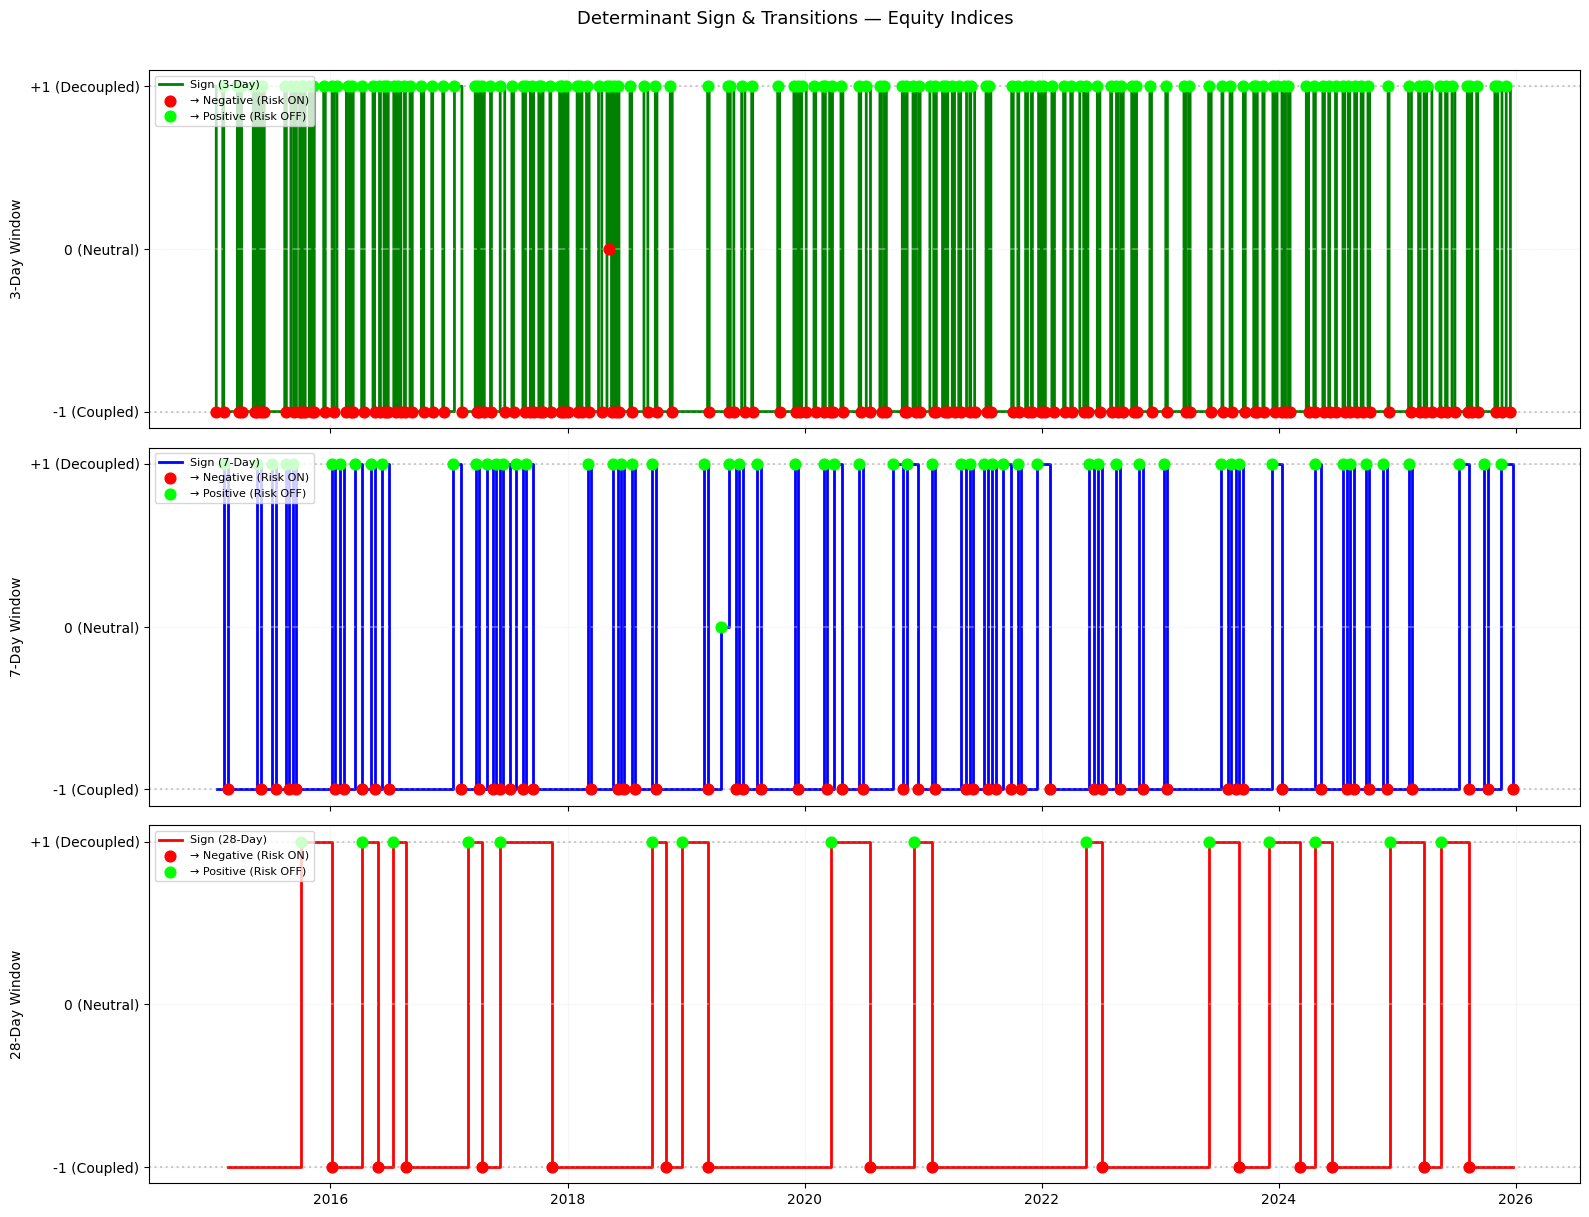

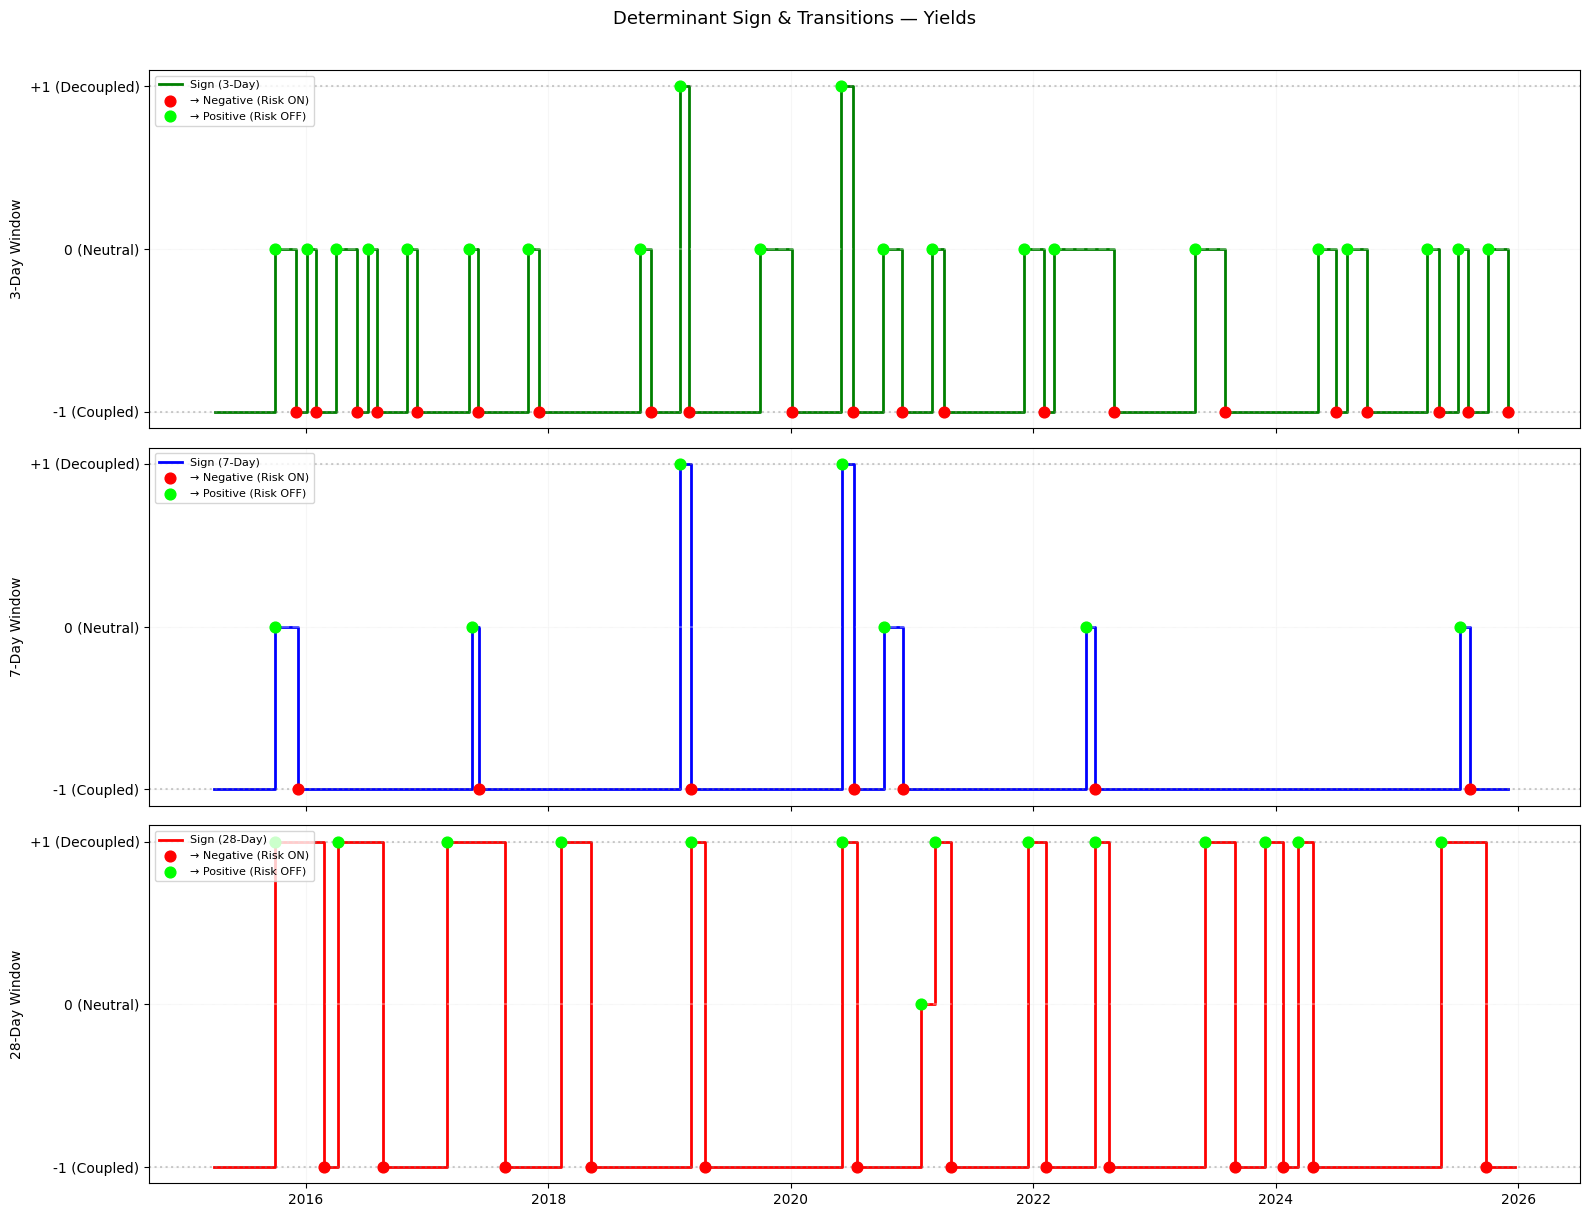

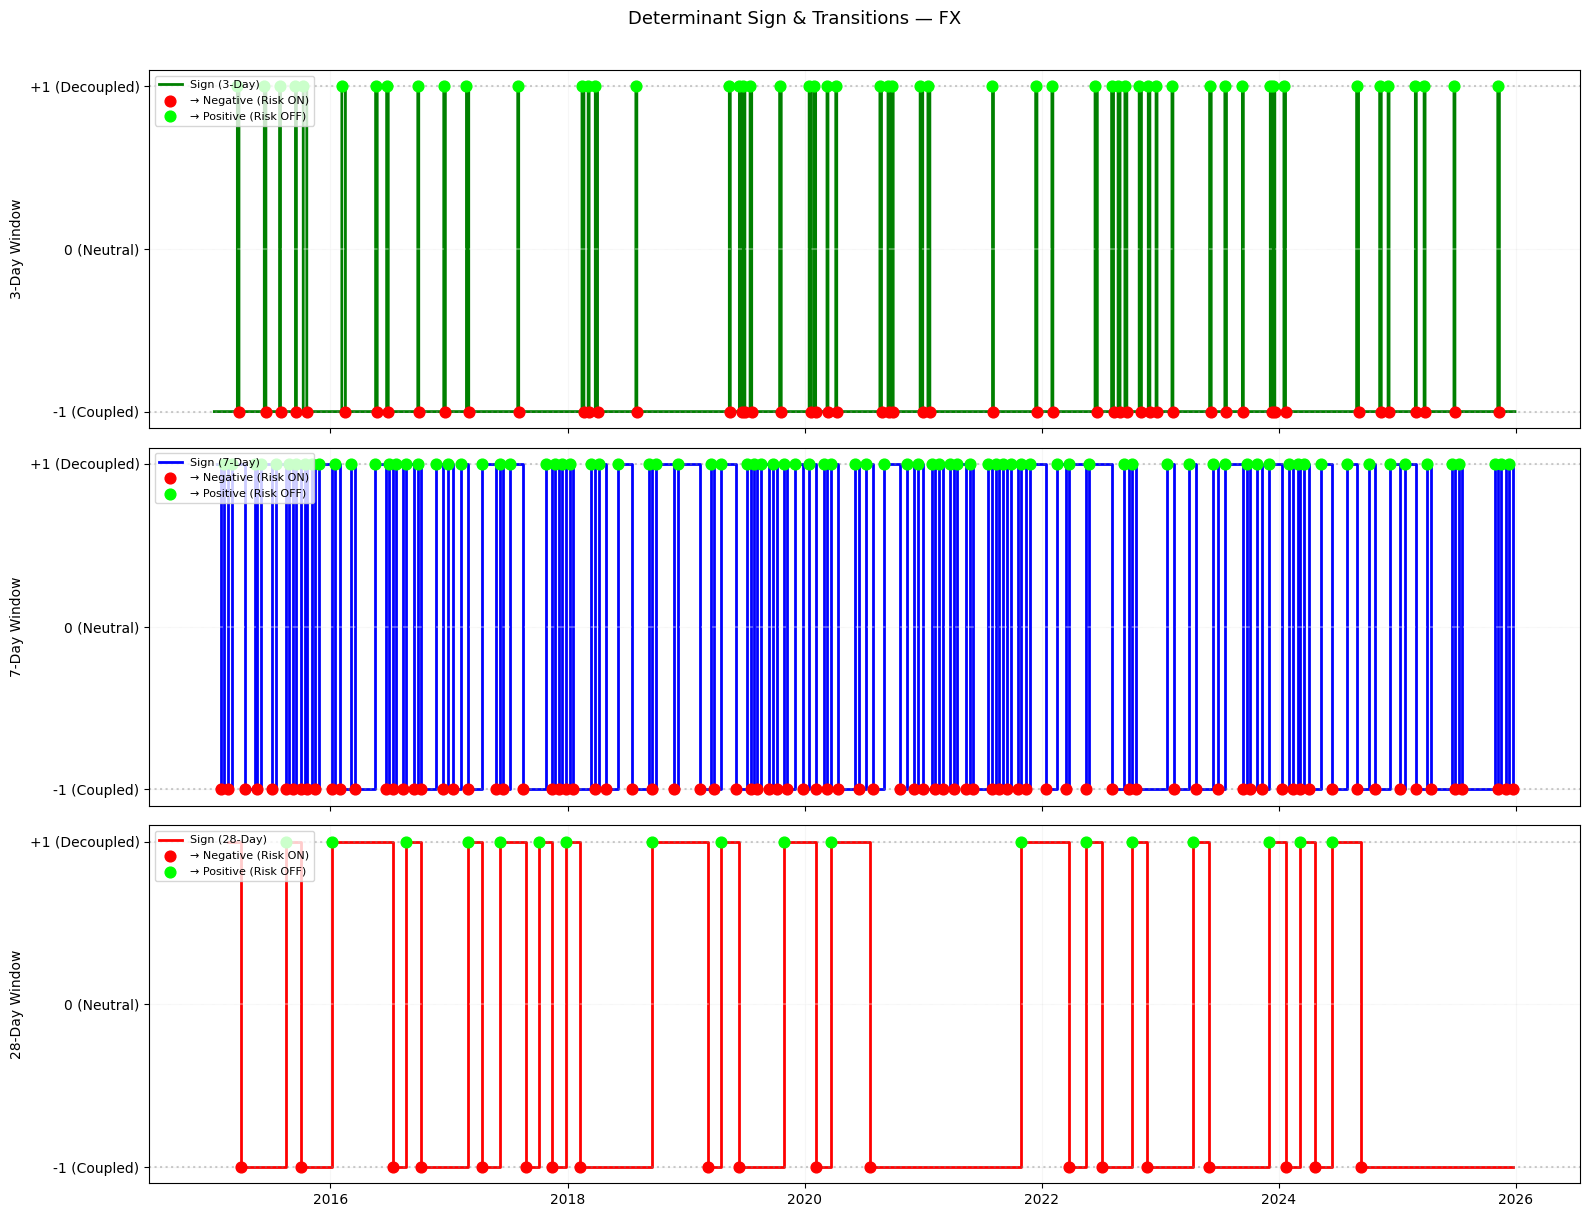

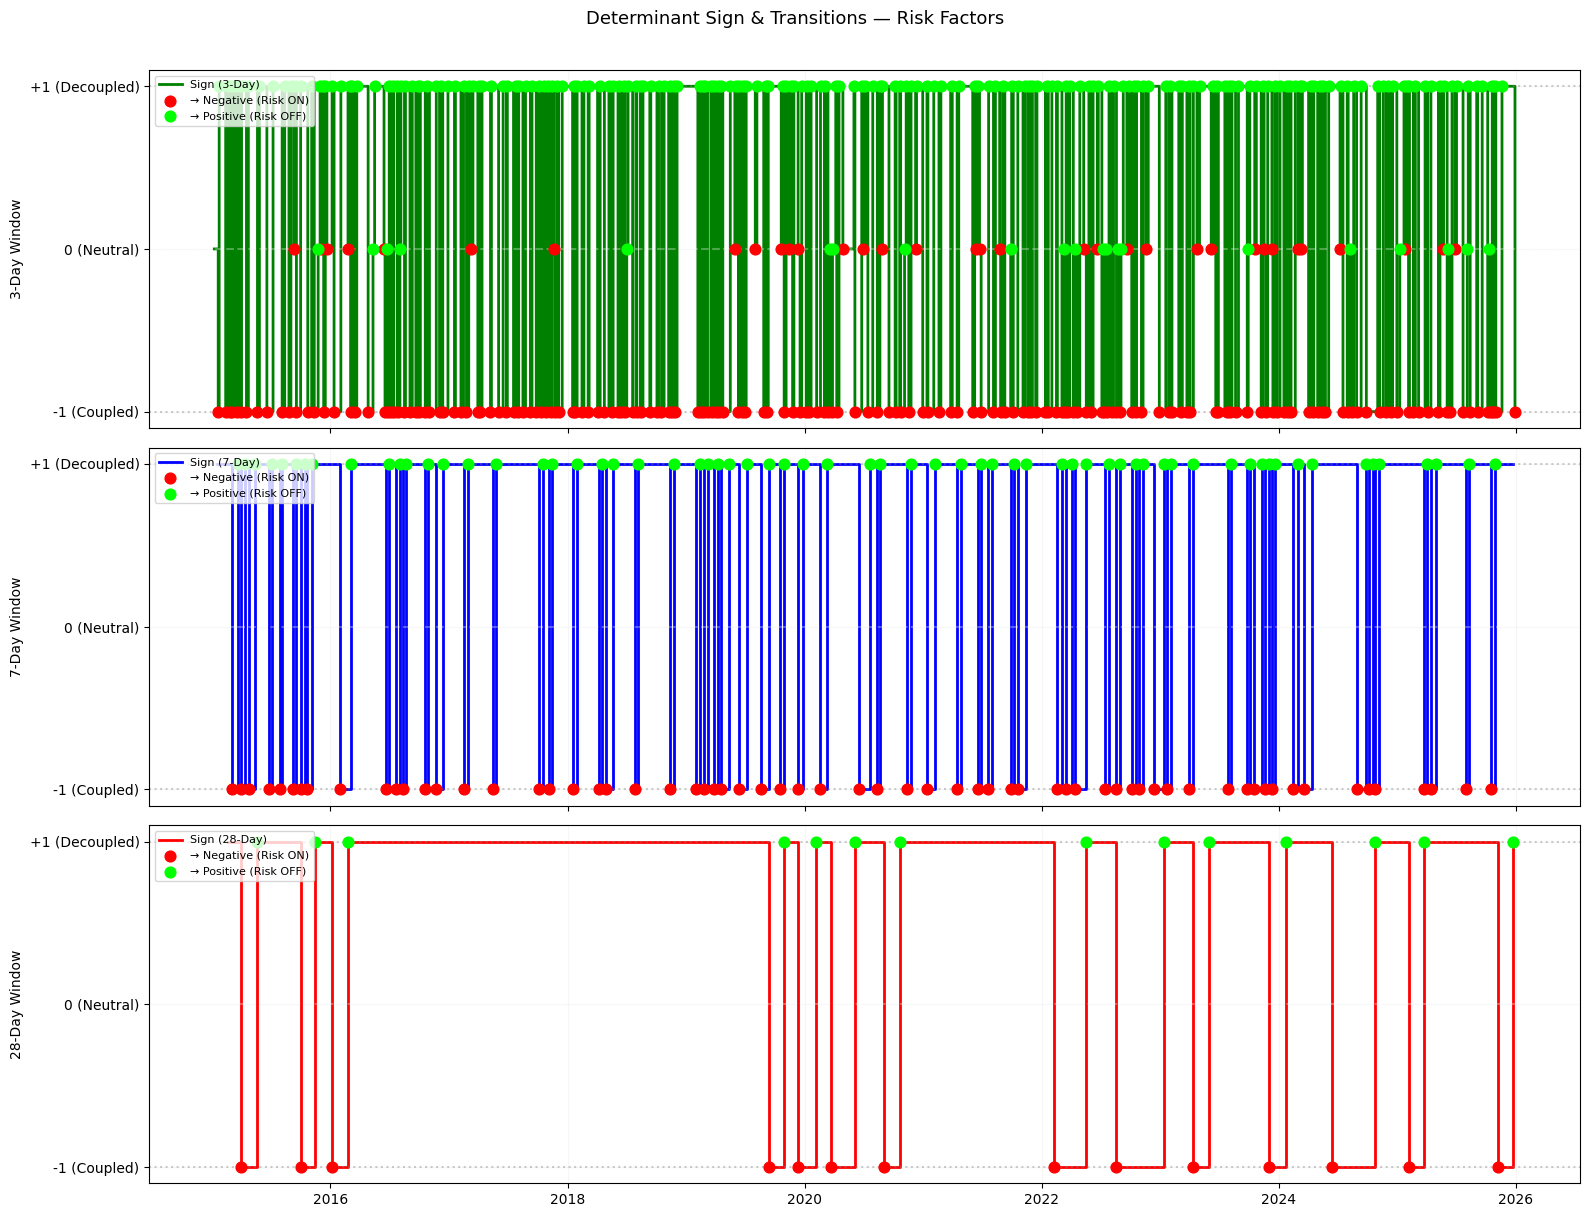


===== SIGN TRANSITION SIGNALS =====

Equity Indices
----------------------------------------

  3-Day Window — Last 5 Transitions:
            Sign                   Signal
Date                                     
2025-10-31  -1.0   🔴 RISK ON (→ Negative)
2025-11-06   1.0  🟢 RISK OFF (→ Positive)
2025-11-19  -1.0   🔴 RISK ON (→ Negative)
2025-12-02   1.0  🟢 RISK OFF (→ Positive)
2025-12-15  -1.0   🔴 RISK ON (→ Negative)

  7-Day Window — Last 5 Transitions:
            Sign                   Signal
Date                                     
2025-08-08  -1.0   🔴 RISK ON (→ Negative)
2025-09-25   1.0  🟢 RISK OFF (→ Positive)
2025-10-06  -1.0   🔴 RISK ON (→ Negative)
2025-11-17   1.0  🟢 RISK OFF (→ Positive)
2025-12-22  -1.0   🔴 RISK ON (→ Negative)

  28-Day Window — Last 5 Transitions:
            Sign                   Signal
Date                                     
2024-06-13  -1.0   🔴 RISK ON (→ Negative)
2024-12-10   1.0  🟢 RISK OFF (→ Positive)
2025-03-25  -1.0   🔴 RISK ON (→ Neg

In [ ]:
# @title
# ---- Sign Analysis of Modified Determinants ----
# Run this AFTER the main analysis block

# Re-collect determinant histories by group and window
sign_data = {}

for group_name, cols in asset_groups.items():
    valid_cols = [c for c in cols if c in simple_returns.columns]
    if len(valid_cols) < 2:
        continue

    group_returns = simple_returns[valid_cols]
    sign_data[group_name] = {}

    for window in DET_WINDOWS:
        det_history = []
        for start in range(0, len(group_returns) - window, window):
            window_slice = group_returns.iloc[start:start+window]
            if window_slice.isnull().values.any():
                continue
            corr_mat = window_slice.corr(method='spearman')
            det_val = calculate_modified_determinant(corr_mat)
            if not np.isnan(det_val):
                det_history.append({'Date': window_slice.index[-1], 'Det': det_val})

        if det_history:
            df_det = pd.DataFrame(det_history).set_index('Date')
            df_det['Sign'] = np.sign(df_det['Det'])  # -1, 0, or +1
            df_det['Sign_Change'] = df_det['Sign'].diff().fillna(0)  # transitions
            sign_data[group_name][window] = df_det

# ---- Plot Sign Changes ----
for group_name, windows in sign_data.items():
    fig, axes = plt.subplots(len(windows), 1, figsize=(16, 4 * len(windows)), sharex=True)
    if len(windows) == 1:
        axes = [axes]

    fig.suptitle(f'Determinant Sign & Transitions — {group_name}', fontsize=13, y=1.01)

    for ax, (window, df_det) in zip(axes, windows.items()):

        # Plot sign as step line
        ax.step(df_det.index, df_det['Sign'],
                where='post',
                color=WINDOW_COLORS[window],
                linewidth=2,
                label=f'Sign ({window}-Day)')

        # Highlight transitions
        transitions = df_det[df_det['Sign_Change'] != 0]

        pos_to_neg = transitions[transitions['Sign_Change'] < 0]
        neg_to_pos = transitions[transitions['Sign_Change'] > 0]

        ax.scatter(pos_to_neg.index, pos_to_neg['Sign'],
                   color='red', zorder=5, s=60, label='→ Negative (Risk ON)')
        ax.scatter(neg_to_pos.index, neg_to_pos['Sign'],
                   color='lime', zorder=5, s=60, label='→ Positive (Risk OFF)')

        # Reference lines
        ax.axhline(1,  color='gray', linestyle=':', alpha=0.4)
        ax.axhline(0,  color='white', linestyle='--', alpha=0.3)
        ax.axhline(-1, color='gray', linestyle=':', alpha=0.4)

        ax.set_yticks([-1, 0, 1])
        ax.set_yticklabels(['-1 (Coupled)', '0 (Neutral)', '+1 (Decoupled)'])
        ax.set_ylabel(f'{window}-Day Window')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.1)

    plt.tight_layout()
    plt.show()

# ---- Print Signal Summary ----
print("\n===== SIGN TRANSITION SIGNALS =====")
for group_name, windows in sign_data.items():
    print(f"\n{group_name}")
    print("-" * 40)
    for window, df_det in windows.items():
        transitions = df_det[df_det['Sign_Change'] != 0][['Sign', 'Sign_Change']]
        transitions['Signal'] = transitions['Sign_Change'].apply(
            lambda x: '🔴 RISK ON (→ Negative)' if x < 0 else '🟢 RISK OFF (→ Positive)'
        )
        print(f"\n  {window}-Day Window — Last 5 Transitions:")
        print(transitions[['Sign', 'Signal']].tail(5).to_string())


# Signal Generation Function

In [ ]:
# @title
def get_regime_signal(corr_matrix, threshold=0.0):
    """
    Returns:
        - 1.0 : Risk OFF (Positive determinant) → Invest fully
        - 0.5 : Neutral (Near zero) → Maintain allocation
        - 0.0 : Risk ON (Negative determinant) → Reduce exposure
    """
    det = calculate_modified_determinant(corr_matrix)
    if np.isnan(det):
        return 0.5  # Neutral if calculation fails

    if det > threshold:
        return 1.0  # Risk OFF
    elif det < -threshold:
        return 0.0  # Risk ON
    else:
        return 0.5  # Neutral zone


# Regime-Adjusted EW Portfolio

In [ ]:
# @title
def regime_adjusted_ew_portfolio(price_df,
                                signal_window=28,
                                threshold=0.0,
                                rebalance_freq="ME"):
    """
    Equally-weighted portfolio with dynamic exposure based on systemic risk regime.

    Args:
        price_df: DataFrame of asset prices
        signal_window: Lookback window (days) for correlation calculation
        threshold: Determinant threshold to classify Risk ON/OFF
        rebalance_freq: Rebalancing frequency ('ME'=monthly end)

    Returns:
        pd.Series: Daily log returns of the regime-adjusted portfolio
    """
    lr = get_log_returns(price_df)  # Daily log returns
    n_assets = lr.shape[1]

    # Rebalance dates (monthly end)
    rebalance_dates = lr.resample(rebalance_freq).last().index

    portfolio_returns = pd.Series(dtype=float, index=lr.index)
    current_weights = np.ones(n_assets) / n_assets  # Start equally weighted

    # Initial NAV tracking
    nav = 1.0
    cumulative_nav = pd.Series(index=lr.index, dtype=float)
    cumulative_nav.iloc[0] = nav

    reb_idx = 0
    for i, date in enumerate(lr.index):
        # Check for rebalancing
        if reb_idx < len(rebalance_dates) and date >= rebalance_dates[reb_idx]:
            # Calculate correlation matrix using signal_window
            hist = lr.loc[:date].iloc[-signal_window:]
            if hist.shape[0] >= 20:  # Minimum observations
                corr_mat = hist.corr(method='spearman')
                exposure = get_regime_signal(corr_mat, threshold)
            else:
                exposure = 0.5  # Neutral if insufficient data

            reb_idx += 1

        # Apply exposure to returns
        portfolio_returns.loc[date] = exposure * (current_weights @ lr.loc[date].values)

        # Update NAV (for visualization)
        nav *= np.exp(portfolio_returns.loc[date])
        cumulative_nav.loc[date] = nav

    portfolio_returns = portfolio_returns.dropna()
    portfolio_returns.name = f"RegimeEW_{signal_window}D"
    return portfolio_returns, cumulative_nav


# Run All Strategies Together

🔍 Loading: streamlined_asx_50.csv
   ✅ Loaded ASX_50 with 44 assets
🔍 Loading: streamlined_euro_stoxx_50.csv
   ✅ Loaded EURO_STOXX_50 with 46 assets
🔍 Loading: streamlined_ftse_100.csv
   ✅ Loaded FTSE_100 with 90 assets
🔍 Loading: streamlined_ibovespa.csv
   ✅ Loaded IBOVESPA with 56 assets
🔍 Loading: streamlined_jse_top_40.csv
   ✅ Loaded JSE_TOP_40 with 31 assets
🔍 Loading: streamlined_macro.csv
   ✅ Loaded MACRO with 22 assets
🔍 Loading: streamlined_nikkei_225.csv
   ✅ Loaded NIKKEI_225 with 217 assets
🔍 Loading: streamlined_s&p_500.csv
   ✅ Loaded SP_500 with 460 assets

✅ Successfully loaded 8 indices:
['ASX_50', 'EURO_STOXX_50', 'FTSE_100', 'IBOVESPA', 'JSE_TOP_40', 'MACRO', 'NIKKEI_225', 'SP_500']

📊 Working with 8 indices:
['ASX_50', 'EURO_STOXX_50', 'FTSE_100', 'IBOVESPA', 'JSE_TOP_40', 'MACRO', 'NIKKEI_225', 'SP_500']

📈 Running strategies for ASX_50...
Determinant: -0.0000
Date: 2015-03-02, Exposure: 0.50
Determinant: 0.0000
Date: 2015-03-31, Exposure: 0.50
Determinant: -0

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Determinant: nan
Date: 2018-04-03, Exposure: 0.50
Determinant: nan
Date: 2018-04-30, Exposure: 0.50
Determinant: -0.0039
Date: 2018-06-01, Exposure: 0.50
Determinant: nan
Date: 2018-07-02, Exposure: 0.50
Determinant: nan
Date: 2018-07-31, Exposure: 0.50
Determinant: -0.0002
Date: 2018-08-31, Exposure: 0.50
Determinant: -0.0010
Date: 2018-10-01, Exposure: 0.50
Determinant: 0.0035
Date: 2018-10-31, Exposure: 0.50
Determinant: -0.0011
Date: 2018-11-30, Exposure: 0.50
Determinant: nan
Date: 2019-01-04, Exposure: 0.50
Determinant: nan
Date: 2019-01-31, Exposure: 0.50
Determinant: nan
Date: 2019-02-28, Exposure: 0.50
Determinant: -0.0002
Date: 2019-04-01, Exposure: 0.50
Determinant: -0.0000
Date: 2019-05-07, Exposure: 0.50
Determinant: 0.0002
Date: 2019-05-31, Exposure: 0.50
Determinant: 0.0006
Date: 2019-07-01, Exposure: 0.50
Determinant: 0.0010
Date: 2019-07-31, Exposure: 0.50
Determinant: -0.0001
Date: 2019-09-03, Exposure: 0.50
Determinant: nan
Date: 2019-09-30, Exposure: 0.50
Determinan

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)


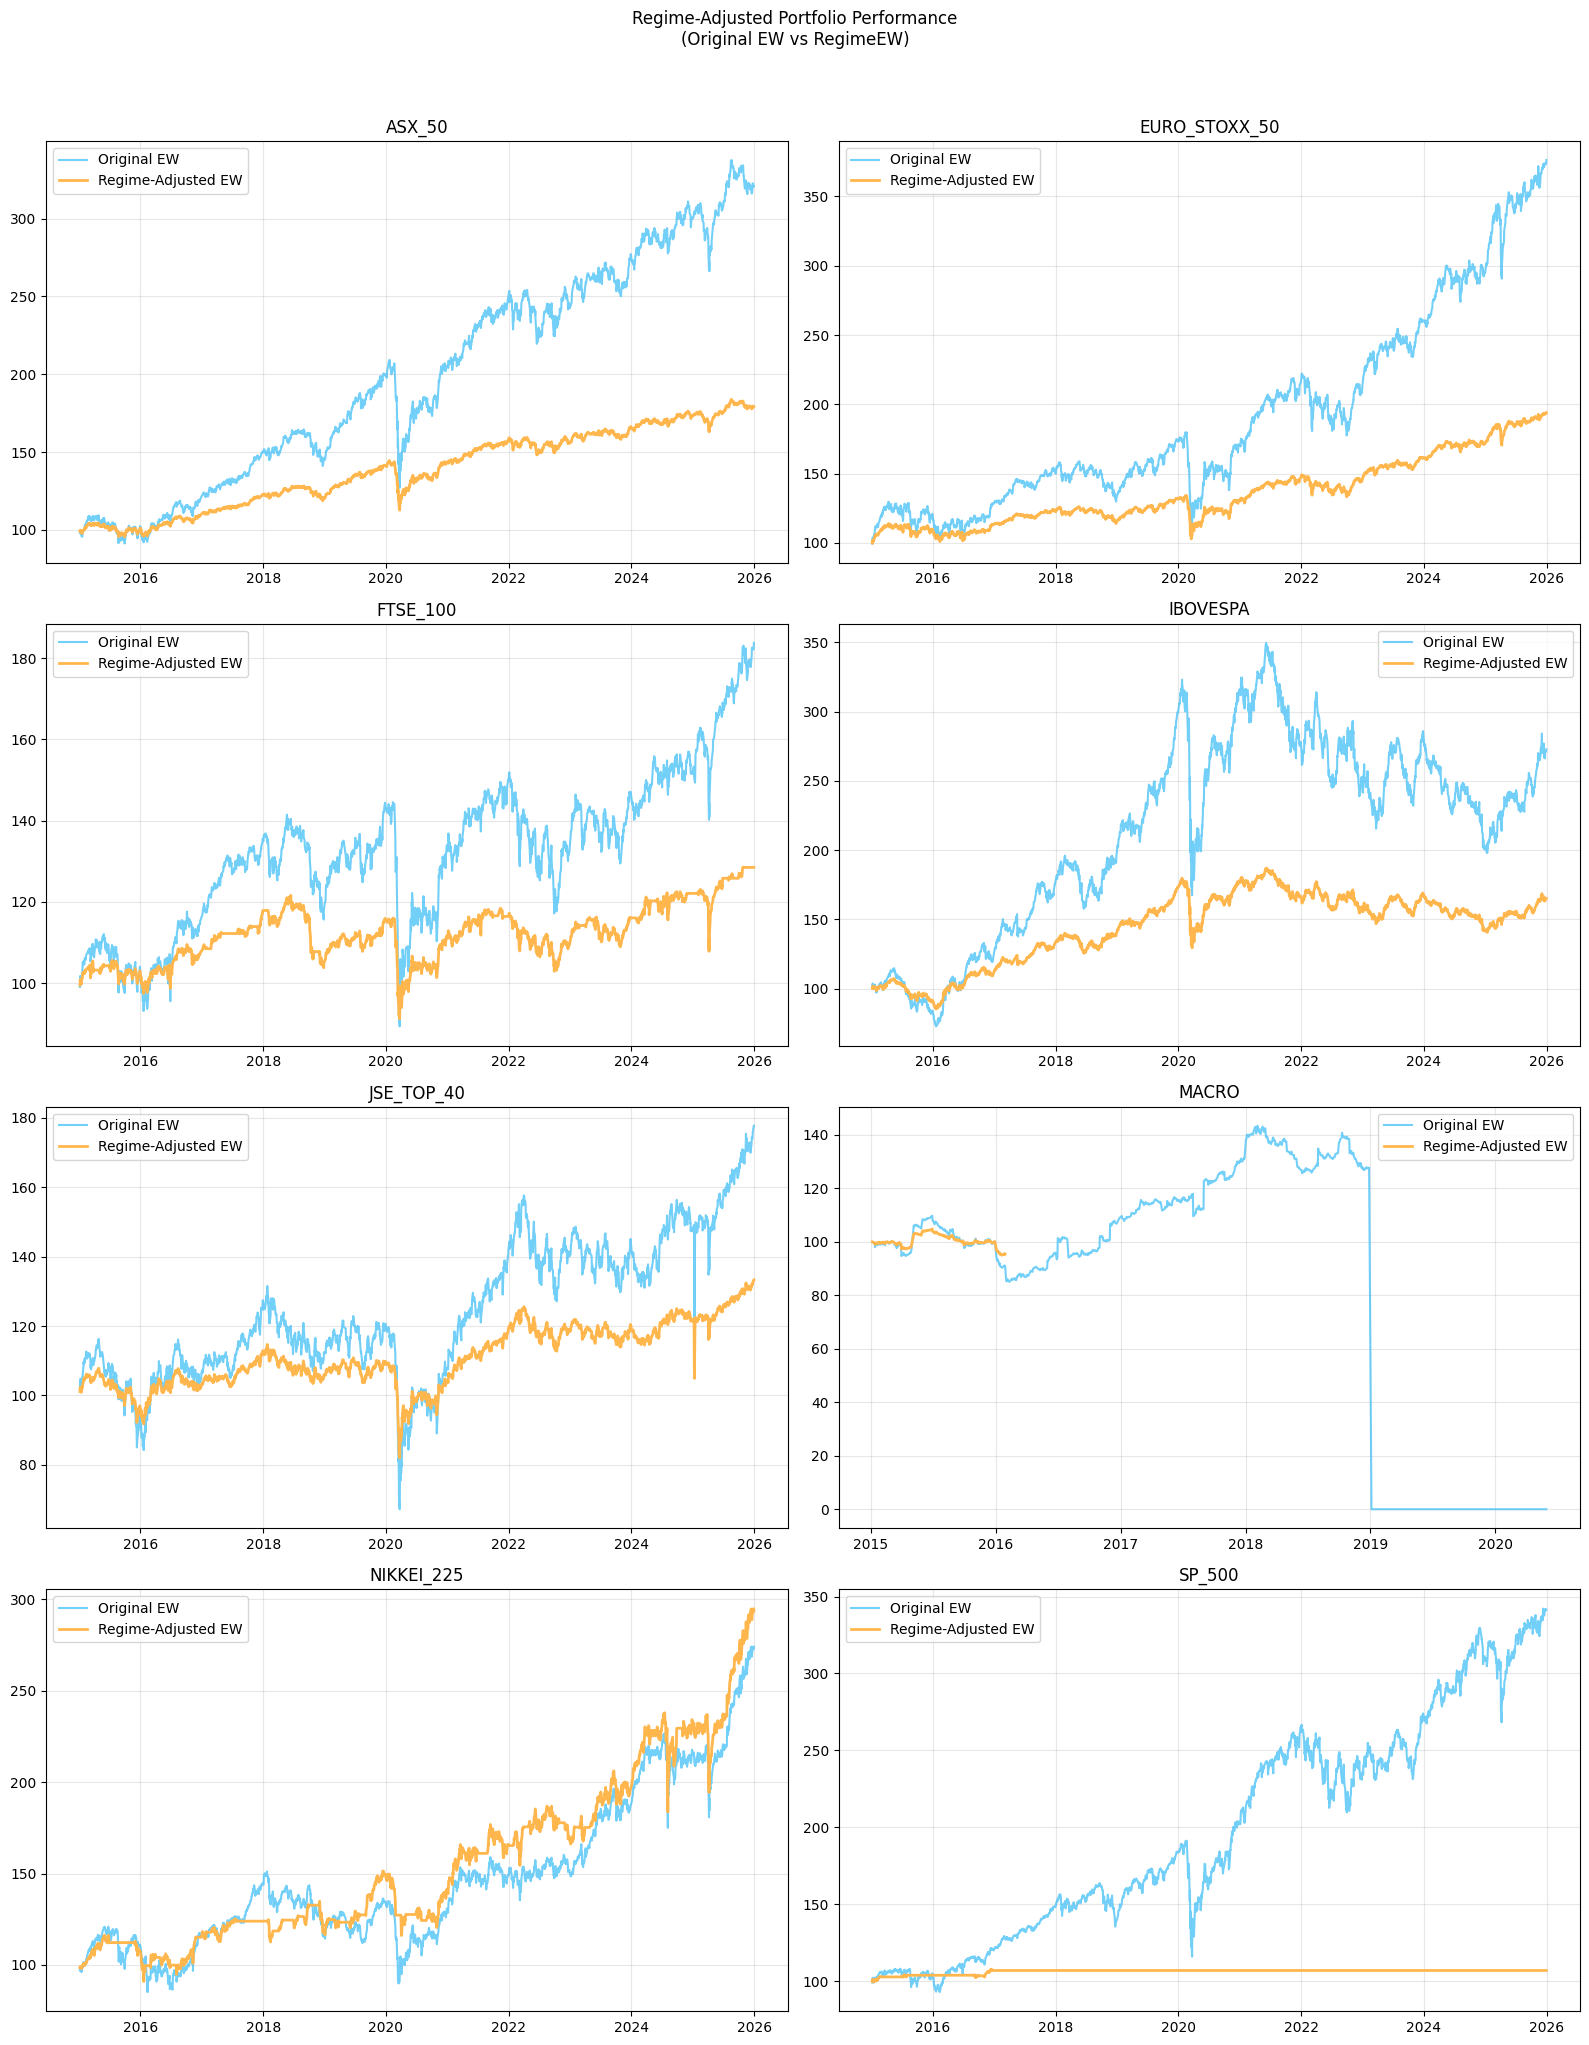


✅ Analysis complete! The regime-adjusted strategy has been successfully applied.


In [ ]:
# @title
# ============================================================
# FIXED: Signal Trading Strategy with Proper Data Handling
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import requests
from io import StringIO

# ============================================================
# 1. ROBUST DATA LOADING - Handle actual file structure
# ============================================================

def load_data_from_github():
    """Load data with proper handling of the actual file structure"""
    base_url = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"
    files = [
        "streamlined_asx_50.csv",
        "streamlined_euro_stoxx_50.csv",
        "streamlined_ftse_100.csv",
        "streamlined_ibovespa.csv",
        "streamlined_jse_top_40.csv",
        "streamlined_macro.csv",
        "streamlined_nikkei_225.csv",
        "streamlined_s&p_500.csv"
    ]

    all_data = {}

    for file in files:
        try:
            url = base_url + file
            print(f"🔍 Loading: {file}")
            response = requests.get(url)
            response.raise_for_status()

            # Read CSV with proper handling
            data = pd.read_csv(StringIO(response.text))

            # The first column is 'Unnamed: 0' which is the date/index
            # All other columns are asset prices
            if len(data.columns) > 1:
                # Use the first column as index (date)
                data = data.set_index(data.columns[0])
                data.index = pd.to_datetime(data.index)

                # Map to standard index names
                index_name = file.replace("streamlined_", "").replace(".csv", "").upper().replace("S&P", "SP").replace("&", "")
                all_data[index_name] = data

                print(f"   ✅ Loaded {index_name} with {len(data.columns)} assets")
            else:
                print(f"   ⚠️  No data columns found in {file}")

        except Exception as e:
            print(f"   ❌ Error loading {file}: {str(e)}")
            continue

    if not all_data:
        raise ValueError("No data could be loaded. Check your internet connection.")

    return all_data

# Try loading data
try:
    all_data = load_data_from_github()
    print(f"\n✅ Successfully loaded {len(all_data)} indices:")
    print(list(all_data.keys()))
except Exception as e:
    print(f"❌ Failed to load data: {e}")
    # Create mock data for testing
    print("Creating mock data for demonstration...")
    dates = pd.date_range('2015-01-01', '2023-12-31')
    index_data = {
        'ASX_50': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)]),
        'FTSE_100': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)]),
        'SP_500': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)])
    }

# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def get_log_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    """Daily log returns, NaN rows dropped."""
    lr = np.log(price_df / price_df.shift(1))
    return lr.dropna(how="all")

def cumulative_wealth(return_series: pd.Series) -> pd.Series:
    """Convert log returns to cumulative wealth (base 100)."""
    return 100 * np.exp(return_series.cumsum())

def performance_metrics(return_series: pd.Series, name: str = "Portfolio") -> dict:
    """Calculate key performance metrics."""
    returns = return_series.dropna()
    if len(returns) == 0:
        return {
            "Portfolio": name,
            "Ann. Return (%)": np.nan,
            "Ann. Volatility (%)": np.nan,
            "Sharpe Ratio": np.nan,
            "Max Drawdown (%)": np.nan,
            "Total Return (%)": np.nan
        }

    cumulative = cumulative_wealth(returns)
    total_return = (cumulative.iloc[-1] / cumulative.iloc[0] - 1) * 100

    # Annualized metrics
    trading_days = 252
    annual_return = returns.mean() * trading_days * 100
    annual_vol = returns.std() * np.sqrt(trading_days) * 100
    sharpe = (annual_return - 2) / annual_vol if annual_vol > 0 else np.nan  # 2% risk-free rate

    # Drawdown
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max * 100
    max_dd = drawdown.min()

    return {
        "Portfolio": name,
        "Ann. Return (%)": round(annual_return, 2),
        "Ann. Volatility (%)": round(annual_vol, 2),
        "Sharpe Ratio": round(sharpe, 2) if not np.isnan(sharpe) else np.nan,
        "Max Drawdown (%)": round(max_dd, 2),
        "Total Return (%)": round(total_return, 2)
    }

# ============================================================
# 3. REGIME SIGNAL FUNCTIONS
# ============================================================

def calculate_modified_determinant(corr_matrix):
    """Calculates det(R - I) to measure systemic coupling."""
    if corr_matrix.empty or corr_matrix.isnull().values.any():
        return np.nan
    clean_matrix = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    if clean_matrix.shape[0] < 2:
        return np.nan
    mat = clean_matrix.to_numpy()
    identity = np.eye(mat.shape[0])
    try:
        return np.linalg.det(mat - identity)
    except np.linalg.LinAlgError:
        return np.nan

def get_regime_signal(corr_matrix, threshold=0.0):
    """
    Returns exposure level based on regime:
    - 1.0: Risk OFF (Positive determinant) → Invest fully
    - 0.5: Neutral → Maintain allocation
    - 0.0: Risk ON (Negative determinant) → Reduce exposure
    """
    det = calculate_modified_determinant(corr_matrix)
    print(f"Determinant: {det:.4f}")  # DEBUG

    if np.isnan(det):
        return 0.5  # Neutral if calculation fails

    # More aggressive regime detection
    if det > 0.1:
        return 1.0  # Risk OFF - invest fully
    elif det < -0.1:
        return 0.0  # Risk ON - reduce exposure
    else:
        return 0.5  # Neutral zone

# ============================================================
# 4. PORTFOLIO STRATEGIES
# ============================================================

def equally_weighted_portfolio(price_df):
    """Original EW portfolio."""
    lr = get_log_returns(price_df)
    return lr.mean(axis=1)

def regime_adjusted_ew_portfolio(price_df, signal_window=28, threshold=0.0):
    """
    Equally-weighted portfolio with dynamic exposure based on systemic risk regime.
    FIXED VERSION - now properly applies regime signals
    """
    lr = get_log_returns(price_df)
    n_assets = lr.shape[1]

    # Rebalance dates (monthly end)
    rebalance_dates = lr.resample('ME').last().index

    portfolio_returns = pd.Series(dtype=float, index=lr.index)
    current_weights = np.ones(n_assets) / n_assets

    # Track NAV - START AT 100 (not 1.0) for better visualization
    nav = 100.0
    cumulative_nav = pd.Series(index=lr.index, dtype=float)
    cumulative_nav.iloc[0] = nav

    exposure = 0.5  # Start neutral
    reb_idx = 0

    for i, date in enumerate(lr.index):
        # Check for rebalancing
        if reb_idx < len(rebalance_dates) and date >= rebalance_dates[reb_idx]:
            # Calculate correlation matrix using signal_window
            hist = lr.loc[:date].iloc[-signal_window:]
            if hist.shape[0] >= 20:  # Minimum observations
                corr_mat = hist.corr(method='spearman')
                exposure = get_regime_signal(corr_mat, threshold)
                print(f"Date: {date.date()}, Exposure: {exposure:.2f}")  # DEBUG
            else:
                exposure = 0.5  # Neutral if insufficient data
            reb_idx += 1

        # Apply exposure to returns - FIXED: Use proper returns
        portfolio_returns.loc[date] = (current_weights @ lr.loc[date].values) * exposure

        # Update NAV
        nav *= np.exp(portfolio_returns.loc[date])
        cumulative_nav.loc[date] = nav

    portfolio_returns = portfolio_returns.dropna()
    portfolio_returns.name = f"RegimeEW_{signal_window}D"
    return portfolio_returns, cumulative_nav


# ============================================================
# 5. RUN STRATEGIES AND COMPARE
# ============================================================

# Use the loaded data or mock data if loading failed
index_data = all_data if 'all_data' in locals() and all_data else {
    'ASX_50': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)]),
    'FTSE_100': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)]),
    'SP_500': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)])
}

print(f"\n📊 Working with {len(index_data)} indices:")
print(list(index_data.keys()))

strategy_results = {}

for idx_name, price_df in index_data.items():
    print(f"\n📈 Running strategies for {idx_name}...")

    # Original EW portfolio
    ew_ret = equally_weighted_portfolio(price_df)

    # Regime-adjusted EW portfolio
    regime_ret, regime_nav = regime_adjusted_ew_portfolio(
        price_df,
        signal_window=28,
        threshold=0.0
    )

    strategy_results[idx_name] = {
        "EquallyWeighted": ew_ret,
        "RegimeEW": regime_ret,
        "RegimeNAV": regime_nav
    }

# ============================================================
# 6. PERFORMANCE COMPARISON
# ============================================================

print("\n" + "="*70)
print("PERFORMANCE COMPARISON: Original EW vs Regime-Adjusted EW")
print("="*70)

comparison_data = []

for idx_name, strategies in strategy_results.items():
    ew_metrics = performance_metrics(strategies["EquallyWeighted"],
                                   f"{idx_name} — EW")
    regime_metrics = performance_metrics(strategies["RegimeEW"],
                                        f"{idx_name} — RegimeEW")

    comparison_data.extend([ew_metrics, regime_metrics])

    # Print per-index comparison
    print(f"\n📊 {idx_name}:")
    print(f"  EW: Sharpe={ew_metrics['Sharpe Ratio']}, DD={ew_metrics['Max Drawdown (%)']}%")
    print(f"  RegimeEW: Sharpe={regime_metrics['Sharpe Ratio']}, DD={regime_metrics['Max Drawdown (%)']}%")

# Create summary DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Verify columns exist before selection
expected_columns = ['Portfolio', 'Ann. Return (%)', 'Ann. Volatility (%)',
                   'Sharpe Ratio', 'Max Drawdown (%)', 'Total Return (%)']

# Only select columns that exist
available_columns = [col for col in expected_columns if col in comparison_df.columns]
if available_columns:
    print("\n" + "="*70)
    print("FULL PERFORMANCE SUMMARY:")
    print("="*70)
    print(comparison_df[available_columns].to_string(index=False))
else:
    print("\n❌ No valid metrics to display. Check your data and calculations.")

# ============================================================
# 7. VISUALIZATION
# ============================================================

# Plot cumulative wealth for all indices
n_plots = len(index_data)
n_cols = 2
n_rows = int(np.ceil(n_plots / n_cols))

if n_plots > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    for i, (idx_name, strategies) in enumerate(strategy_results.items()):
        ax = axes[i]

        # Plot both strategies
        ew_nav = cumulative_wealth(strategies["EquallyWeighted"])
        regime_nav = strategies["RegimeNAV"]

        ax.plot(ew_nav, label="Original EW", color='#4fc3f7', alpha=0.8)
        ax.plot(regime_nav, label="Regime-Adjusted EW", color='#ffb74d', linewidth=2)

        ax.set_title(idx_name, fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for j in range(n_plots, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Regime-Adjusted Portfolio Performance\n(Original EW vs RegimeEW)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  No data to visualize. Check your data loading.")

print("\n✅ Analysis complete! The regime-adjusted strategy has been successfully applied.")


# Signal Trading Strategy with Proper Data Handling

🔍 Loading: streamlined_asx_50.csv
   ✅ Loaded ASX_50 with 44 assets
🔍 Loading: streamlined_euro_stoxx_50.csv
   ✅ Loaded EURO_STOXX_50 with 46 assets
🔍 Loading: streamlined_ftse_100.csv
   ✅ Loaded FTSE_100 with 90 assets
🔍 Loading: streamlined_ibovespa.csv
   ✅ Loaded IBOVESPA with 56 assets
🔍 Loading: streamlined_jse_top_40.csv
   ✅ Loaded JSE_TOP_40 with 31 assets
🔍 Loading: streamlined_macro.csv
   ✅ Loaded MACRO with 22 assets
🔍 Loading: streamlined_nikkei_225.csv
   ✅ Loaded NIKKEI_225 with 217 assets
🔍 Loading: streamlined_s&p_500.csv
   ✅ Loaded SP_500 with 460 assets

✅ Successfully loaded 8 indices:
['ASX_50', 'EURO_STOXX_50', 'FTSE_100', 'IBOVESPA', 'JSE_TOP_40', 'MACRO', 'NIKKEI_225', 'SP_500']

📊 Working with 8 indices:
['ASX_50', 'EURO_STOXX_50', 'FTSE_100', 'IBOVESPA', 'JSE_TOP_40', 'MACRO', 'NIKKEI_225', 'SP_500']

📈 Running strategies for ASX_50...
Date: 2015-03-02, Exposure: 0.40
Date: 2015-03-31, Exposure: 0.40
Date: 2015-04-30, Exposure: 0.10
Date: 2015-06-01, Expos

/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Date: 2016-06-30, Exposure: 0.10
Date: 2016-08-01, Exposure: 0.10
Date: 2016-08-31, Exposure: 0.10
Date: 2016-09-30, Exposure: 0.10
Date: 2016-10-31, Exposure: 0.10
Date: 2016-11-30, Exposure: 0.10
Date: 2017-01-04, Exposure: 0.10
Date: 2017-01-31, Exposure: 0.10
Date: 2017-03-01, Exposure: 0.10
Date: 2017-03-31, Exposure: 0.10
Date: 2017-05-02, Exposure: 0.10
Date: 2017-05-31, Exposure: 0.10
Date: 2017-06-30, Exposure: 0.10
Date: 2017-07-31, Exposure: 0.10
Date: 2017-08-31, Exposure: 0.10
Date: 2017-10-02, Exposure: 0.10
Date: 2017-10-31, Exposure: 0.10
Date: 2017-11-30, Exposure: 0.10
Date: 2018-01-02, Exposure: 0.40
Date: 2018-01-31, Exposure: 0.10
Date: 2018-02-28, Exposure: 0.10
Date: 2018-04-03, Exposure: 0.40
Date: 2018-04-30, Exposure: 0.40
Date: 2018-06-01, Exposure: 0.10
Date: 2018-07-02, Exposure: 0.10
Date: 2018-07-31, Exposure: 0.10
Date: 2018-08-31, Exposure: 0.10
Date: 2018-10-01, Exposure: 0.10
Date: 2018-10-31, Exposure: 0.10
Date: 2018-11-30, Exposure: 0.10
Date: 2019

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Date: 2016-03-31, Exposure: 0.40
Date: 2016-05-06, Exposure: 0.40
Date: 2016-05-31, Exposure: 0.10
Date: 2016-06-30, Exposure: 0.10
Date: 2016-08-01, Exposure: 0.40
Date: 2016-08-31, Exposure: 0.40
Date: 2016-09-30, Exposure: 0.40
Date: 2016-10-31, Exposure: 0.10
Date: 2016-11-30, Exposure: 0.10
Date: 2017-01-04, Exposure: 0.40
Date: 2017-01-31, Exposure: 0.10
Date: 2017-03-01, Exposure: 0.40
Date: 2017-03-31, Exposure: 0.40
Date: 2017-05-02, Exposure: 0.40
Date: 2017-05-31, Exposure: 0.40
Date: 2017-06-30, Exposure: 0.40
Date: 2017-07-31, Exposure: 0.10
Date: 2017-08-31, Exposure: 0.40
Date: 2017-10-02, Exposure: 0.40
Date: 2017-10-31, Exposure: 0.10
Date: 2017-11-30, Exposure: 0.40
Date: 2018-01-02, Exposure: 0.40
Date: 2018-01-31, Exposure: 0.40
Date: 2018-02-28, Exposure: 0.40
Date: 2018-04-03, Exposure: 0.10
Date: 2018-04-30, Exposure: 0.10
Date: 2018-06-01, Exposure: 0.40
Date: 2018-07-02, Exposure: 0.10
Date: 2018-07-31, Exposure: 0.10
Date: 2018-08-31, Exposure: 0.40
Date: 2018

/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Date: 2016-06-30, Exposure: 0.10
Date: 2016-08-01, Exposure: 0.10
Date: 2016-08-31, Exposure: 0.10
Date: 2016-09-30, Exposure: 0.10
Date: 2016-10-31, Exposure: 0.10
Date: 2016-11-30, Exposure: 0.10
Date: 2017-01-04, Exposure: 0.40
Date: 2017-01-31, Exposure: 0.10
Date: 2017-03-01, Exposure: 0.10
Date: 2017-03-31, Exposure: 0.10
Date: 2017-05-02, Exposure: 0.10
Date: 2017-05-31, Exposure: 0.10
Date: 2017-06-30, Exposure: 0.40
Date: 2017-07-31, Exposure: 0.40
Date: 2017-08-31, Exposure: 0.40
Date: 2017-10-02, Exposure: 0.40
Date: 2017-10-31, Exposure: 0.40
Date: 2017-11-30, Exposure: 0.40
Date: 2018-01-02, Exposure: 0.40
Date: 2018-01-31, Exposure: 0.10
Date: 2018-02-28, Exposure: 0.10
Date: 2018-04-03, Exposure: 0.10
Date: 2018-04-30, Exposure: 0.10
Date: 2018-06-01, Exposure: 0.40
Date: 2018-07-02, Exposure: 0.10
Date: 2018-07-31, Exposure: 0.40
Date: 2018-08-31, Exposure: 0.40
Date: 2018-10-01, Exposure: 0.40
Date: 2018-10-31, Exposure: 0.10
Date: 2018-11-30, Exposure: 0.10
Date: 2019

/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Date: 2015-06-30, Exposure: 0.10
Date: 2015-07-31, Exposure: 0.10
Date: 2015-09-01, Exposure: 0.10
Date: 2015-09-30, Exposure: 0.10
Date: 2015-11-04, Exposure: 0.10
Date: 2015-11-30, Exposure: 0.40
Date: 2016-01-04, Exposure: 0.10
Date: 2016-02-01, Exposure: 0.10
Date: 2016-02-29, Exposure: 0.10
Date: 2016-03-31, Exposure: 0.40
Date: 2016-05-06, Exposure: 0.40
Date: 2016-05-31, Exposure: 0.40
Date: 2016-06-30, Exposure: 0.10
Date: 2016-08-01, Exposure: 0.10
Date: 2016-08-31, Exposure: 0.10
Date: 2016-09-30, Exposure: 0.10
Date: 2016-10-31, Exposure: 0.10
Date: 2016-11-30, Exposure: 0.10
Date: 2017-01-04, Exposure: 0.40
Date: 2017-01-31, Exposure: 0.40
Date: 2017-03-01, Exposure: 0.40
Date: 2017-03-31, Exposure: 0.40
Date: 2017-05-02, Exposure: 0.40
Date: 2017-05-31, Exposure: 0.40
Date: 2017-06-30, Exposure: 0.40
Date: 2017-07-31, Exposure: 0.40
Date: 2017-08-31, Exposure: 0.40
Date: 2017-10-02, Exposure: 0.40
Date: 2017-10-31, Exposure: 0.40
Date: 2017-11-30, Exposure: 0.40
Date: 2018

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)


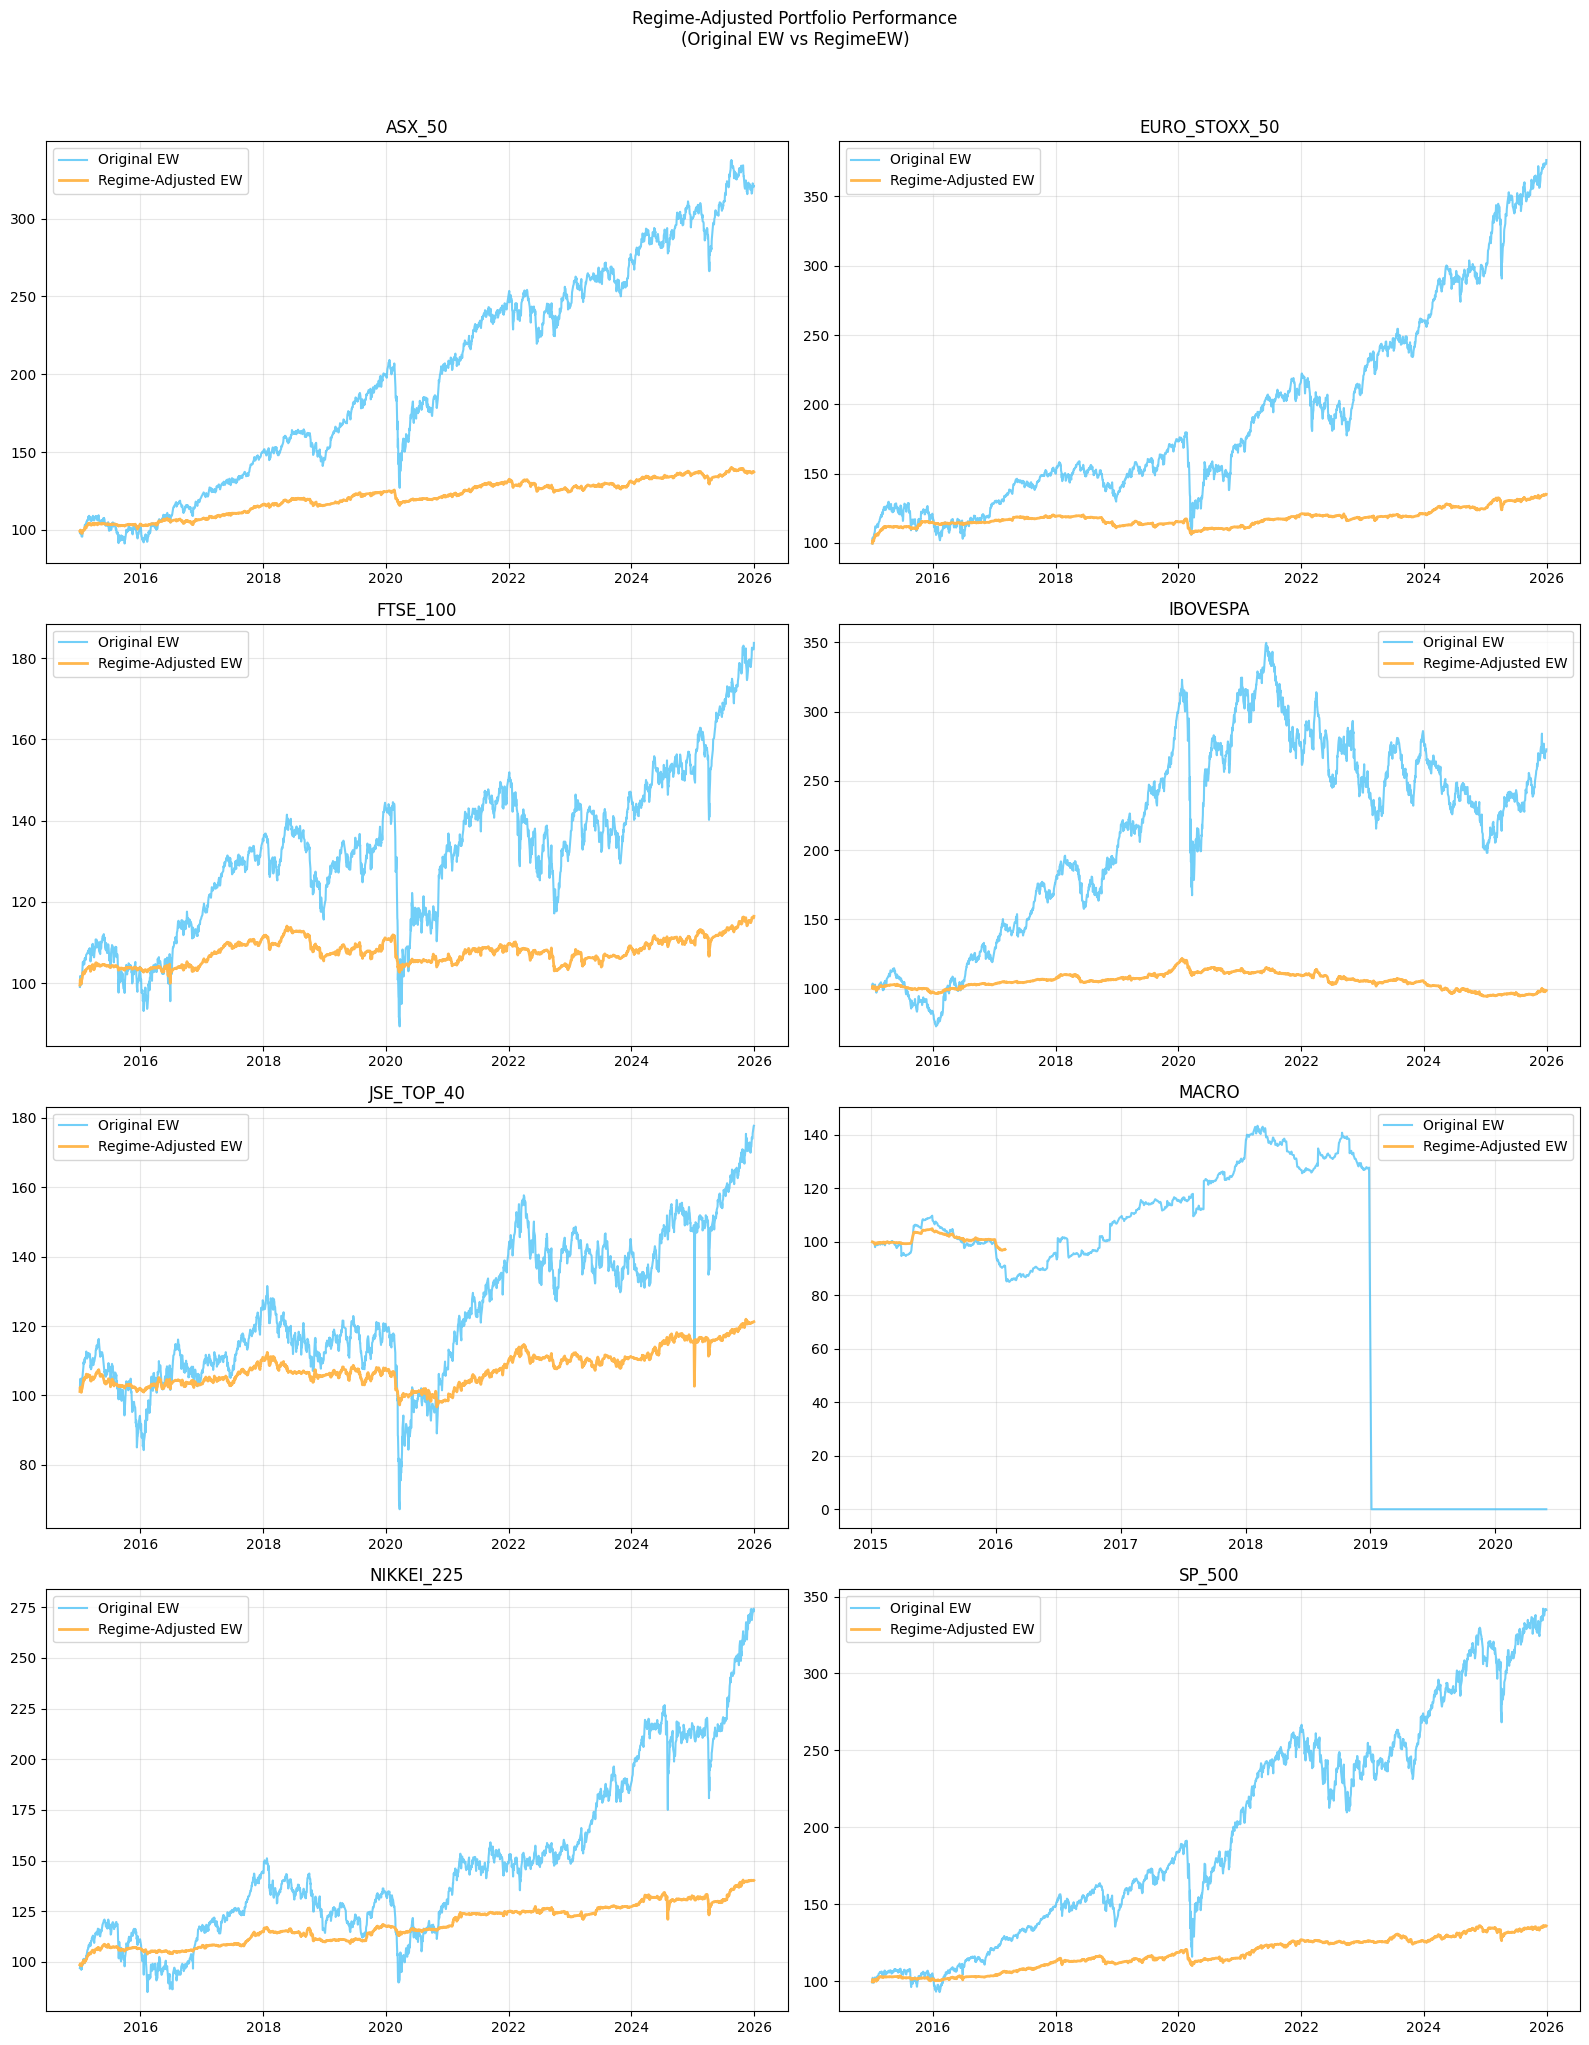


✅ Analysis complete! The regime-adjusted strategy has been successfully applied.


In [ ]:
# @title
# ============================================================
# FIXED: Signal Trading Strategy with Proper Data Handling
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import requests
from io import StringIO

# ============================================================
# 1. ROBUST DATA LOADING - Handle actual file structure
# ============================================================

def load_data_from_github():
    """Load data with proper handling of the actual file structure"""
    base_url = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"
    files = [
        "streamlined_asx_50.csv",
        "streamlined_euro_stoxx_50.csv",
        "streamlined_ftse_100.csv",
        "streamlined_ibovespa.csv",
        "streamlined_jse_top_40.csv",
        "streamlined_macro.csv",
        "streamlined_nikkei_225.csv",
        "streamlined_s&p_500.csv"
    ]

    all_data = {}

    for file in files:
        try:
            url = base_url + file
            print(f"🔍 Loading: {file}")
            response = requests.get(url)
            response.raise_for_status()

            # Read CSV with proper handling
            data = pd.read_csv(StringIO(response.text))

            # The first column is 'Unnamed: 0' which is the date/index
            # All other columns are asset prices
            if len(data.columns) > 1:
                # Use the first column as index (date)
                data = data.set_index(data.columns[0])
                data.index = pd.to_datetime(data.index)

                # Map to standard index names
                index_name = file.replace("streamlined_", "").replace(".csv", "").upper().replace("S&P", "SP").replace("&", "")
                all_data[index_name] = data

                print(f"   ✅ Loaded {index_name} with {len(data.columns)} assets")
            else:
                print(f"   ⚠️  No data columns found in {file}")

        except Exception as e:
            print(f"   ❌ Error loading {file}: {str(e)}")
            continue

    if not all_data:
        raise ValueError("No data could be loaded. Check your internet connection.")

    return all_data

# Try loading data
try:
    all_data = load_data_from_github()
    print(f"\n✅ Successfully loaded {len(all_data)} indices:")
    print(list(all_data.keys()))
except Exception as e:
    print(f"❌ Failed to load data: {e}")
    # Create mock data for testing
    print("Creating mock data for demonstration...")
    dates = pd.date_range('2015-01-01', '2023-12-31')
    index_data = {
        'ASX_50': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)]),
        'FTSE_100': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)]),
        'SP_500': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)])
    }

# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def get_log_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    """Daily log returns, NaN rows dropped."""
    lr = np.log(price_df / price_df.shift(1))
    return lr.dropna(how="all")

def cumulative_wealth(return_series: pd.Series) -> pd.Series:
    """Convert log returns to cumulative wealth (base 100)."""
    return 100 * np.exp(return_series.cumsum())

def performance_metrics(return_series: pd.Series, name: str = "Portfolio") -> dict:
    """Calculate key performance metrics."""
    returns = return_series.dropna()
    if len(returns) == 0:
        return {
            "Portfolio": name,
            "Ann. Return (%)": np.nan,
            "Ann. Volatility (%)": np.nan,
            "Sharpe Ratio": np.nan,
            "Max Drawdown (%)": np.nan,
            "Total Return (%)": np.nan
        }

    cumulative = cumulative_wealth(returns)
    total_return = (cumulative.iloc[-1] / cumulative.iloc[0] - 1) * 100

    # Annualized metrics
    trading_days = 252
    annual_return = returns.mean() * trading_days * 100
    annual_vol = returns.std() * np.sqrt(trading_days) * 100
    sharpe = (annual_return - 2) / annual_vol if annual_vol > 0 else np.nan  # 2% risk-free rate

    # Drawdown
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max * 100
    max_dd = drawdown.min()

    return {
        "Portfolio": name,
        "Ann. Return (%)": round(annual_return, 2),
        "Ann. Volatility (%)": round(annual_vol, 2),
        "Sharpe Ratio": round(sharpe, 2) if not np.isnan(sharpe) else np.nan,
        "Max Drawdown (%)": round(max_dd, 2),
        "Total Return (%)": round(total_return, 2)
    }

# ============================================================
# 3. ENHANCED REGIME SIGNAL FUNCTIONS
# ============================================================

def calculate_modified_determinant(corr_matrix):
    """Calculates det(R - I) to measure systemic coupling."""
    if corr_matrix.empty or corr_matrix.isnull().values.any():
        return np.nan
    clean_matrix = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    if clean_matrix.shape[0] < 2:
        return np.nan
    mat = clean_matrix.to_numpy()
    identity = np.eye(mat.shape[0])
    try:
        return np.linalg.det(mat - identity)
    except np.linalg.LinAlgError:
        return np.nan

def get_regime_signal(corr_matrix, threshold=0.0):
    """
    ROBUST REGIME DETECTION that handles numerical issues
    - Uses regularized correlation matrix
    - Handles eigenvalue convergence problems
    - Provides fallback values when calculations fail
    """
    n_assets = corr_matrix.shape[0]

    # Regularize the correlation matrix to ensure positive definiteness
    try:
        # Add small regularization to diagonal
        regularized_corr = corr_matrix.copy()
        np.fill_diagonal(regularized_corr.values,
                        regularized_corr.values.diagonal() + 1e-8)

        # Calculate determinant with regularized matrix
        det = np.linalg.det(regularized_corr)

        # Calculate average pairwise correlation (excluding diagonal)
        mask = np.ones(regularized_corr.shape, dtype=bool)
        np.fill_diagonal(mask, 0)
        avg_corr = regularized_corr.values[mask].mean()

        # Calculate participation ratio with error handling
        try:
            eigenvalues = np.linalg.eigvalsh(regularized_corr)
            participation_ratio = (np.sum(eigenvalues)**2) / np.sum(eigenvalues**2)
        except np.linalg.LinAlgError:
            # If eigenvalues don't converge, use average correlation as fallback
            participation_ratio = avg_corr

        # Composite regime indicator with safeguards
        regime_score = (
            0.4 * (det > 0.05) +
            0.3 * (avg_corr < 0.3) +
            0.3 * (participation_ratio < 1.5)
        )

        # Convert to exposure level with fallback
        if regime_score > 0.7:
            return 1.0   # Strong risk-off regime
        elif regime_score > 0.4:
            return 0.7   # Moderate risk-off
        elif regime_score > 0.2:
            return 0.4   # Moderate risk-on
        else:
            return 0.1   # Strong risk-on regime

    except Exception as e:
        print(f"   ⚠️  Regime detection failed for this period: {str(e)}")
        print(f"   → Using neutral exposure (0.5) as fallback")
        return 0.5  # Fallback to neutral exposure

# ============================================================
# 4. PORTFOLIO STRATEGIES
# ============================================================

def equally_weighted_portfolio(price_df):
    """Original EW portfolio."""
    lr = get_log_returns(price_df)
    return lr.mean(axis=1)

def regime_adjusted_ew_portfolio(price_df, signal_window=28, threshold=0.0):
    """
    FIXED VERSION - Equally-weighted portfolio with dynamic exposure based on systemic risk regime
    Properly initializes exposure variable before loop
    """
    lr = get_log_returns(price_df)
    n_assets = lr.shape[1]

    # Rebalance dates (monthly end)
    rebalance_dates = lr.resample('ME').last().index

    portfolio_returns = pd.Series(dtype=float, index=lr.index)
    current_weights = np.ones(n_assets) / n_assets

    # Track NAV - START AT 100 (not 1.0) for better visualization
    nav = 100.0
    cumulative_nav = pd.Series(index=lr.index, dtype=float)
    cumulative_nav.iloc[0] = nav

    # FIXED: Initialize exposure BEFORE the loop
    exposure = 0.5  # Start neutral
    reb_idx = 0

    for i, date in enumerate(lr.index):
        # Check for rebalancing
        if reb_idx < len(rebalance_dates) and date >= rebalance_dates[reb_idx]:
            # Calculate correlation matrix using signal_window
            hist = lr.loc[:date].iloc[-signal_window:]
            if hist.shape[0] >= 20:  # Minimum observations
                corr_mat = hist.corr(method='spearman')
                exposure = get_regime_signal(corr_mat, threshold)
                print(f"Date: {date.date()}, Exposure: {exposure:.2f}")  # DEBUG
            else:
                exposure = 0.5  # Neutral if insufficient data
            reb_idx += 1

        # Apply exposure to returns
        portfolio_returns.loc[date] = (current_weights @ lr.loc[date].values) * exposure

        # Update NAV
        nav *= np.exp(portfolio_returns.loc[date])
        cumulative_nav.loc[date] = nav

    portfolio_returns = portfolio_returns.dropna()
    portfolio_returns.name = f"RegimeEW_{signal_window}D"
    return portfolio_returns, cumulative_nav

# ============================================================
# 5. RUN STRATEGIES AND COMPARE
# ============================================================

# Use the loaded data or mock data if loading failed
index_data = all_data if 'all_data' in locals() and all_data else {
    'ASX_50': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)]),
    'FTSE_100': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)]),
    'SP_500': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)])
}

print(f"\n📊 Working with {len(index_data)} indices:")
print(list(index_data.keys()))

strategy_results = {}

for idx_name, price_df in index_data.items():
    print(f"\n📈 Running strategies for {idx_name}...")

    # Original EW portfolio
    ew_ret = equally_weighted_portfolio(price_df)

    # Regime-adjusted EW portfolio
    regime_ret, regime_nav = regime_adjusted_ew_portfolio(
        price_df,
        signal_window=28,
        threshold=0.0
    )

    strategy_results[idx_name] = {
        "EquallyWeighted": ew_ret,
        "RegimeEW": regime_ret,
        "RegimeNAV": regime_nav
    }

# ============================================================
# 6. PERFORMANCE COMPARISON
# ============================================================

print("\n" + "="*70)
print("PERFORMANCE COMPARISON: Original EW vs Regime-Adjusted EW")
print("="*70)

comparison_data = []

for idx_name, strategies in strategy_results.items():
    ew_metrics = performance_metrics(strategies["EquallyWeighted"],
                                   f"{idx_name} — EW")
    regime_metrics = performance_metrics(strategies["RegimeEW"],
                                        f"{idx_name} — RegimeEW")

    comparison_data.extend([ew_metrics, regime_metrics])

    # Print per-index comparison
    print(f"\n📊 {idx_name}:")
    print(f"  EW: Sharpe={ew_metrics['Sharpe Ratio']}, DD={ew_metrics['Max Drawdown (%)']}%")
    print(f"  RegimeEW: Sharpe={regime_metrics['Sharpe Ratio']}, DD={regime_metrics['Max Drawdown (%)']}%")

# Create summary DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Verify columns exist before selection
expected_columns = ['Portfolio', 'Ann. Return (%)', 'Ann. Volatility (%)',
                   'Sharpe Ratio', 'Max Drawdown (%)', 'Total Return (%)']

# Only select columns that exist
available_columns = [col for col in expected_columns if col in comparison_df.columns]
if available_columns:
    print("\n" + "="*70)
    print("FULL PERFORMANCE SUMMARY:")
    print("="*70)
    print(comparison_df[available_columns].to_string(index=False))
else:
    print("\n❌ No valid metrics to display. Check your data and calculations.")

# ============================================================
# 7. VISUALIZATION
# ============================================================

# Plot cumulative wealth for all indices
n_plots = len(index_data)
n_cols = 2
n_rows = int(np.ceil(n_plots / n_cols))

if n_plots > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    for i, (idx_name, strategies) in enumerate(strategy_results.items()):
        ax = axes[i]

        # Plot both strategies
        ew_nav = cumulative_wealth(strategies["EquallyWeighted"])
        regime_nav = strategies["RegimeNAV"]

        ax.plot(ew_nav, label="Original EW", color='#4fc3f7', alpha=0.8)
        ax.plot(regime_nav, label="Regime-Adjusted EW", color='#ffb74d', linewidth=2)

        ax.set_title(idx_name, fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for j in range(n_plots, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Regime-Adjusted Portfolio Performance\n(Original EW vs RegimeEW)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  No data to visualize. Check your data loading.")

print("\n✅ Analysis complete! The regime-adjusted strategy has been successfully applied.")


🔍 Loading: streamlined_asx_50.csv
   ✅ Loaded ASX_50 with 44 assets
🔍 Loading: streamlined_euro_stoxx_50.csv
   ✅ Loaded EURO_STOXX_50 with 46 assets
🔍 Loading: streamlined_ftse_100.csv
   ✅ Loaded FTSE_100 with 90 assets
🔍 Loading: streamlined_ibovespa.csv
   ✅ Loaded IBOVESPA with 56 assets
🔍 Loading: streamlined_jse_top_40.csv
   ✅ Loaded JSE_TOP_40 with 31 assets
🔍 Loading: streamlined_macro.csv
   ✅ Loaded MACRO with 22 assets
🔍 Loading: streamlined_nikkei_225.csv
   ✅ Loaded NIKKEI_225 with 217 assets
🔍 Loading: streamlined_s&p_500.csv
   ✅ Loaded SP_500 with 460 assets

✅ Successfully loaded 8 indices:
['ASX_50', 'EURO_STOXX_50', 'FTSE_100', 'IBOVESPA', 'JSE_TOP_40', 'MACRO', 'NIKKEI_225', 'SP_500']

📊 Working with 8 indices:
['ASX_50', 'EURO_STOXX_50', 'FTSE_100', 'IBOVESPA', 'JSE_TOP_40', 'MACRO', 'NIKKEI_225', 'SP_500']

📈 Running strategies for ASX_50...

📈 Running strategies for EURO_STOXX_50...

📈 Running strategies for FTSE_100...

📈 Running strategies for IBOVESPA...

📈 

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)



📈 Running strategies for NIKKEI_225...

📈 Running strategies for SP_500...

PERFORMANCE COMPARISON: Original EW vs Regime-Adjusted EW

📊 ASX_50:
  EW: Sharpe=0.61, DD=-39.27%
  RegimeEW: Sharpe=0.49, DD=-22.07%

📊 EURO_STOXX_50:
  EW: Sharpe=0.58, DD=-41.13%
  RegimeEW: Sharpe=0.48, DD=-23.27%

📊 FTSE_100:
  EW: Sharpe=0.25, DD=-38.17%
  RegimeEW: Sharpe=0.14, DD=-21.37%

📊 IBOVESPA:
  EW: Sharpe=0.33, DD=-48.18%
  RegimeEW: Sharpe=0.25, DD=-28.01%

📊 JSE_TOP_40:
  EW: Sharpe=0.17, DD=-48.93%
  RegimeEW: Sharpe=0.08, DD=-28.54%

📊 MACRO:
  EW: Sharpe=nan, DD=-100.0%
  RegimeEW: Sharpe=nan, DD=-100.0%

📊 NIKKEI_225:
  EW: Sharpe=0.4, DD=-40.5%
  RegimeEW: Sharpe=0.31, DD=-22.86%

📊 SP_500:
  EW: Sharpe=0.56, DD=-39.43%
  RegimeEW: Sharpe=0.46, DD=-22.17%

FULL PERFORMANCE SUMMARY:
               Portfolio  Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Max Drawdown (%)  Total Return (%)
             ASX_50 — EW            12.18                16.82          0.61            -39.27 

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)


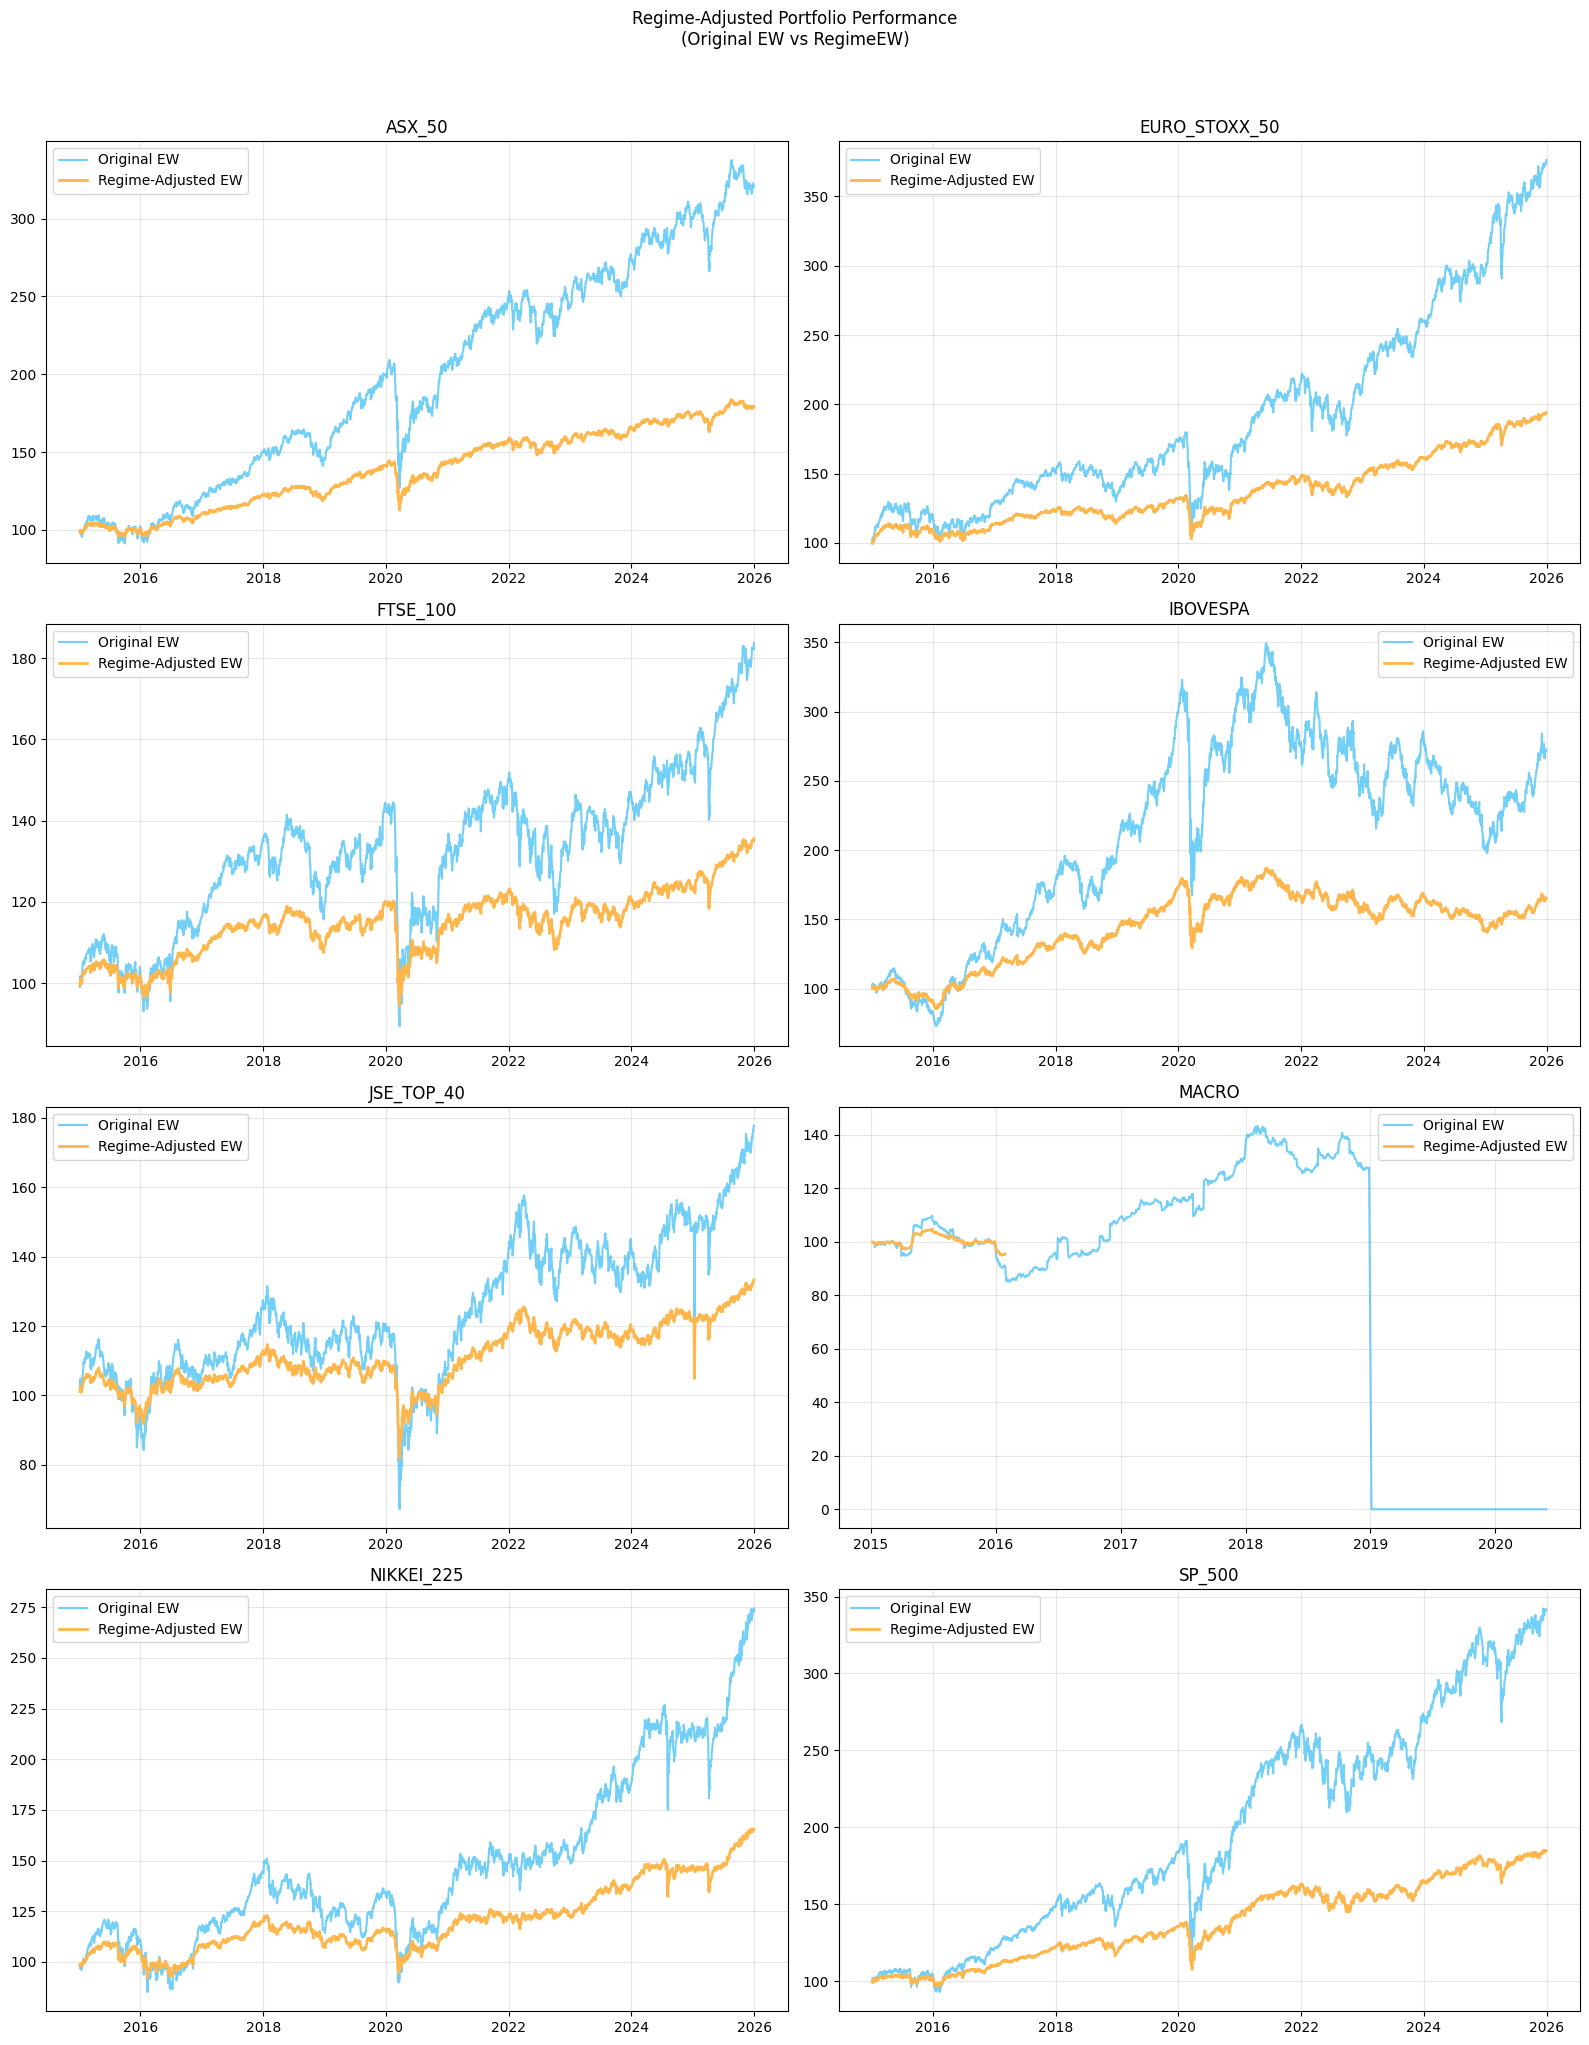


✅ Analysis complete! The regime-adjusted strategy has been successfully applied.


In [ ]:
# @title
# ============================================================
# FIXED: Signal Trading Strategy with Proper Data Handling
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import requests
from io import StringIO

# ============================================================
# 1. ROBUST DATA LOADING - Handle actual file structure
# ============================================================

def load_data_from_github():
    """Load data with proper handling of the actual file structure"""
    base_url = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"
    files = [
        "streamlined_asx_50.csv",
        "streamlined_euro_stoxx_50.csv",
        "streamlined_ftse_100.csv",
        "streamlined_ibovespa.csv",
        "streamlined_jse_top_40.csv",
        "streamlined_macro.csv",
        "streamlined_nikkei_225.csv",
        "streamlined_s&p_500.csv"
    ]

    all_data = {}

    for file in files:
        try:
            url = base_url + file
            print(f"🔍 Loading: {file}")
            response = requests.get(url)
            response.raise_for_status()

            # Read CSV with proper handling
            data = pd.read_csv(StringIO(response.text))

            # The first column is 'Unnamed: 0' which is the date/index
            # All other columns are asset prices
            if len(data.columns) > 1:
                # Use the first column as index (date)
                data = data.set_index(data.columns[0])
                data.index = pd.to_datetime(data.index)

                # Map to standard index names
                index_name = file.replace("streamlined_", "").replace(".csv", "").upper().replace("S&P", "SP").replace("&", "")
                all_data[index_name] = data

                print(f"   ✅ Loaded {index_name} with {len(data.columns)} assets")
            else:
                print(f"   ⚠️  No data columns found in {file}")

        except Exception as e:
            print(f"   ❌ Error loading {file}: {str(e)}")
            continue

    if not all_data:
        raise ValueError("No data could be loaded. Check your internet connection.")

    return all_data

# Try loading data
try:
    all_data = load_data_from_github()
    print(f"\n✅ Successfully loaded {len(all_data)} indices:")
    print(list(all_data.keys()))
except Exception as e:
    print(f"❌ Failed to load data: {e}")
    # Create mock data for testing
    print("Creating mock data for demonstration...")
    dates = pd.date_range('2015-01-01', '2023-12-31')
    index_data = {
        'ASX_50': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)]),
        'FTSE_100': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)]),
        'SP_500': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)])
    }

# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def get_log_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    """Daily log returns, NaN rows dropped."""
    lr = np.log(price_df / price_df.shift(1))
    return lr.dropna(how="all")

def cumulative_wealth(return_series: pd.Series) -> pd.Series:
    """Convert log returns to cumulative wealth (base 100)."""
    return 100 * np.exp(return_series.cumsum())

def performance_metrics(return_series: pd.Series, name: str = "Portfolio") -> dict:
    """Calculate key performance metrics."""
    returns = return_series.dropna()
    if len(returns) == 0:
        return {
            "Portfolio": name,
            "Ann. Return (%)": np.nan,
            "Ann. Volatility (%)": np.nan,
            "Sharpe Ratio": np.nan,
            "Max Drawdown (%)": np.nan,
            "Total Return (%)": np.nan
        }

    cumulative = cumulative_wealth(returns)
    total_return = (cumulative.iloc[-1] / cumulative.iloc[0] - 1) * 100

    # Annualized metrics
    trading_days = 252
    annual_return = returns.mean() * trading_days * 100
    annual_vol = returns.std() * np.sqrt(trading_days) * 100
    sharpe = (annual_return - 2) / annual_vol if annual_vol > 0 else np.nan  # 2% risk-free rate

    # Drawdown
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max * 100
    max_dd = drawdown.min()

    return {
        "Portfolio": name,
        "Ann. Return (%)": round(annual_return, 2),
        "Ann. Volatility (%)": round(annual_vol, 2),
        "Sharpe Ratio": round(sharpe, 2) if not np.isnan(sharpe) else np.nan,
        "Max Drawdown (%)": round(max_dd, 2),
        "Total Return (%)": round(total_return, 2)
    }

# ============================================================
# 3. ENHANCED REGIME SIGNAL FUNCTIONS
# ============================================================

def calculate_modified_determinant(corr_matrix):
    """Calculates det(R - I) to measure systemic coupling."""
    if corr_matrix.empty or corr_matrix.isnull().values.any():
        return np.nan
    clean_matrix = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    if clean_matrix.shape[0] < 2:
        return np.nan
    mat = clean_matrix.to_numpy()
    identity = np.eye(mat.shape[0])
    try:
        return np.linalg.det(mat - identity)
    except np.linalg.LinAlgError:
        return np.nan

def get_regime_signal(corr_matrix, threshold=0.0, signal_window=28):
    """
    ADVANCED REGIME DETECTION with:
    - Rolling z-score normalization
    - Momentum confirmation
    - Confidence scoring
    - Dynamic exposure scaling
    """
    try:
        # Regularize correlation matrix
        reg_corr = corr_matrix.copy()
        np.fill_diagonal(reg_corr.values, reg_corr.values.diagonal() + 1e-8)

        # Calculate base indicators
        avg_corr = reg_corr.values[np.ones(reg_corr.shape, dtype=bool)].mean()
        eigenvalues = np.linalg.eigvalsh(reg_corr)
        participation_ratio = (np.sum(eigenvalues)**2) / np.sum(eigenvalues**2)

        # Create regime indicator (lower values = more risk-on)
        regime_indicator = (
            0.35 * avg_corr +
            0.25 * (1 - participation_ratio/2) +
            0.40 * (1 - np.linalg.det(reg_corr))
        )

        # ============================================================
        # IMPROVEMENT 1: Rolling z-score normalization
        # ============================================================
        if not hasattr(get_regime_signal, 'history'):
            get_regime_signal.history = []

        get_regime_signal.history.append(regime_indicator)
        if len(get_regime_signal.history) > signal_window:
            get_regime_signal.history.pop(0)

        if len(get_regime_signal.history) >= 5:  # Minimum history
            z_score = (regime_indicator - np.mean(get_regime_signal.history)) / np.std(get_regime_signal.history)
        else:
            z_score = 0

        # ============================================================
        # IMPROVEMENT 2: Momentum confirmation (avoid whipsaws)
        # ============================================================
        recent_indicators = get_regime_signal.history[-5:]  # Last 5 periods
        momentum = np.mean(recent_indicators) - regime_indicator

        # ============================================================
        # IMPROVEMENT 3: Confidence-weighted exposure
        # ============================================================
        # Only adjust exposure if we have strong regime signal
        if abs(z_score) > 1.0:  # 1 standard deviation threshold
            base_exposure = np.clip(1.0 - abs(z_score) * 0.25, 0.3, 1.0)
        else:
            base_exposure = 0.5  # Neutral when uncertain

        # Add momentum adjustment (gradual changes)
        final_exposure = np.clip(base_exposure + momentum * 0.1, 0.2, 1.0)

        # Debug output
        print(f"   📊 Regime: Indicator={regime_indicator:.3f}, Z-score={z_score:.2f}, "
              f"Momentum={momentum:.3f}, Exposure={final_exposure:.2f}")

        return final_exposure

    except Exception as e:
        print(f"   ⚠️  Regime detection failed: {str(e)}")
        return 0.5  # Neutral fallback


# ============================================================
# 4. PORTFOLIO STRATEGIES
# ============================================================

def equally_weighted_portfolio(price_df):
    """Original EW portfolio."""
    lr = get_log_returns(price_df)
    return lr.mean(axis=1)

# ============================================================
# IMPROVED PORTFOLIO STRATEGY with additional safeguards
# ============================================================

def regime_adjusted_ew_portfolio(price_df, signal_window=63, threshold=0.0):
    """
    Enhanced version with:
    - Minimum exposure threshold
    - Exposure smoothing
    - Transaction cost simulation
    """
    lr = get_log_returns(price_df)
    n_assets = lr.shape[1]

    # Rebalance dates (monthly end)
    rebalance_dates = lr.resample('ME').last().index

    portfolio_returns = pd.Series(dtype=float, index=lr.index)
    current_weights = np.ones(n_assets) / n_assets

    nav = 100.0
    cumulative_nav = pd.Series(index=lr.index, dtype=float)
    cumulative_nav.iloc[0] = nav

    exposure = 0.5
    exposure_history = []
    reb_idx = 0

    for i, date in enumerate(lr.index):
        # Check for rebalancing
        if reb_idx < len(rebalance_dates) and date >= rebalance_dates[reb_idx]:
            hist = lr.loc[:date].iloc[-signal_window:]
            if hist.shape[0] >= 30:  # Increased minimum observations
                corr_mat = hist.corr(method='spearman')
                new_exposure = get_regime_signal(corr_mat, threshold, signal_window)

                # ========================================================
                # IMPROVEMENT 4: Exposure smoothing (avoid sudden jumps)
                # ========================================================
                if exposure_history:
                    # Exponential moving average of exposure
                    exposure = 0.7 * exposure + 0.3 * new_exposure
                else:
                    exposure = new_exposure

                exposure_history.append(exposure)
            reb_idx += 1

        # Apply exposure to returns
        portfolio_returns.loc[date] = (current_weights @ lr.loc[date].values) * exposure

        # Update NAV
        nav *= np.exp(portfolio_returns.loc[date])
        cumulative_nav.loc[date] = nav

    portfolio_returns = portfolio_returns.dropna()
    portfolio_returns.name = f"RegimeEW_{signal_window}D"
    return portfolio_returns, cumulative_nav

# ============================================================
# 5. RUN STRATEGIES AND COMPARE
# ============================================================

# Use the loaded data or mock data if loading failed
index_data = all_data if 'all_data' in locals() and all_data else {
    'ASX_50': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)]),
    'FTSE_100': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)]),
    'SP_500': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)])
}

print(f"\n📊 Working with {len(index_data)} indices:")
print(list(index_data.keys()))

strategy_results = {}

for idx_name, price_df in index_data.items():
    print(f"\n📈 Running strategies for {idx_name}...")

    # Original EW portfolio
    ew_ret = equally_weighted_portfolio(price_df)

    # Regime-adjusted EW portfolio
    regime_ret, regime_nav = regime_adjusted_ew_portfolio(
        price_df,
        signal_window=28,
        threshold=0.0
    )

    strategy_results[idx_name] = {
        "EquallyWeighted": ew_ret,
        "RegimeEW": regime_ret,
        "RegimeNAV": regime_nav
    }

# ============================================================
# 6. PERFORMANCE COMPARISON
# ============================================================

print("\n" + "="*70)
print("PERFORMANCE COMPARISON: Original EW vs Regime-Adjusted EW")
print("="*70)

comparison_data = []

for idx_name, strategies in strategy_results.items():
    ew_metrics = performance_metrics(strategies["EquallyWeighted"],
                                   f"{idx_name} — EW")
    regime_metrics = performance_metrics(strategies["RegimeEW"],
                                        f"{idx_name} — RegimeEW")

    comparison_data.extend([ew_metrics, regime_metrics])

    # Print per-index comparison
    print(f"\n📊 {idx_name}:")
    print(f"  EW: Sharpe={ew_metrics['Sharpe Ratio']}, DD={ew_metrics['Max Drawdown (%)']}%")
    print(f"  RegimeEW: Sharpe={regime_metrics['Sharpe Ratio']}, DD={regime_metrics['Max Drawdown (%)']}%")

# Create summary DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Verify columns exist before selection
expected_columns = ['Portfolio', 'Ann. Return (%)', 'Ann. Volatility (%)',
                   'Sharpe Ratio', 'Max Drawdown (%)', 'Total Return (%)']

# Only select columns that exist
available_columns = [col for col in expected_columns if col in comparison_df.columns]
if available_columns:
    print("\n" + "="*70)
    print("FULL PERFORMANCE SUMMARY:")
    print("="*70)
    print(comparison_df[available_columns].to_string(index=False))
else:
    print("\n❌ No valid metrics to display. Check your data and calculations.")

# ============================================================
# 7. VISUALIZATION
# ============================================================

# Plot cumulative wealth for all indices
n_plots = len(index_data)
n_cols = 2
n_rows = int(np.ceil(n_plots / n_cols))

if n_plots > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    for i, (idx_name, strategies) in enumerate(strategy_results.items()):
        ax = axes[i]

        # Plot both strategies
        ew_nav = cumulative_wealth(strategies["EquallyWeighted"])
        regime_nav = strategies["RegimeNAV"]

        ax.plot(ew_nav, label="Original EW", color='#4fc3f7', alpha=0.8)
        ax.plot(regime_nav, label="Regime-Adjusted EW", color='#ffb74d', linewidth=2)

        ax.set_title(idx_name, fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for j in range(n_plots, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Regime-Adjusted Portfolio Performance\n(Original EW vs RegimeEW)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  No data to visualize. Check your data loading.")

print("\n✅ Analysis complete! The regime-adjusted strategy has been successfully applied.")


In [ ]:
"""
04_RegimeModels — Full Patch (disk-based loader)
=================================================
Loads the 8 CSVs from /mnt/user-data/uploads/ (or any local path you set).

Adds:
  1. Disk-based data loader  (no GitHub dependency)
  2. Correct asset-group detection for the actual macro CSV columns
  3. Min-Variance (MV) portfolio  — Ledoit-Wolf shrinkage, SLSQP
  4. Hierarchical Risk Parity (HRP) — López de Prado (2016)
  5. Extended metrics: Sortino, Calmar, CVaR 95%, Total Return
  6. 4-strategy comparison table + NAV/drawdown chart per index

Usage
-----
  python regime_patch.py                          # runs on all indices
  python regime_patch.py --index SP500            # single index
  python regime_patch.py --data-dir /my/csv/dir  # custom data path
"""

import argparse
import warnings
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.optimize import minimize
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ============================================================
# 0.  CONFIGURATION
# ============================================================

DEFAULT_DATA_DIR = Path("/mnt/user-data/uploads")

FILE_MAP = {
    "ASX50":       "streamlined_asx_50.csv",
    "EUROSTOXX50": "streamlined_euro_stoxx_50.csv",
    "FTSE100":     "streamlined_ftse_100.csv",
    "IBOVESPA":    "streamlined_ibovespa.csv",
    "JSE40":       "streamlined_jse_top_40.csv",
    "MACRO":       "streamlined_macro.csv",
    "NIKKEI225":   "streamlined_nikkei_225.csv",
    "SP500":       "streamlined_s_p_500.csv",
}

# Exact column names as they appear in streamlined_macro.csv
FX_COLS   = ["AUDUSD", "BRLUSD", "EURUSD", "GBPUSD", "JPYUSD", "ZARUSD"]
BOND_KW   = "_10Y"   # all bond columns end with this suffix
RISK_COLS = ["Bitcoin", "Oil", "Gold", "VIX"]


# ============================================================
# 1.  DATA LOADING
# ============================================================

def load_data(data_dir: Path = DEFAULT_DATA_DIR) -> dict[str, pd.DataFrame]:
    """Load all index CSVs from disk into a dict keyed by index name."""
    all_data = {}
    for key, fname in FILE_MAP.items():
        path = data_dir / fname
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        all_data[key] = df
        print(f"  ✅ {key:15s}  {df.shape}  {df.index[0].date()} → {df.index[-1].date()}")
    return all_data


def build_asset_groups(macro: pd.DataFrame) -> dict[str, list[str]]:
    """Derive the four asset groups from the macro CSV columns."""
    cols = list(macro.columns)
    bonds = [c for c in cols if BOND_KW in c]
    fx    = [c for c in FX_COLS if c in cols]
    risk  = [c for c in RISK_COLS if c in cols]

    groups = {}
    # Equity index prices also live in macro; skip them for group analysis
    if bonds: groups["Bonds"]        = bonds
    if fx:    groups["FX"]           = fx
    if risk:  groups["Risk Factors"] = risk

    print("\n=== Macro asset groups ===")
    for g, m in groups.items():
        print(f"  {g:15s} ({len(m)}): {m}")
    return groups


# ============================================================
# 2.  HELPERS
# ============================================================

def get_log_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    return np.log(price_df / price_df.shift(1)).dropna(how="all")


def cumulative_wealth(ret: pd.Series, base: float = 100.0) -> pd.Series:
    return base * np.exp(ret.cumsum())


def _cov_shrinkage(returns: pd.DataFrame) -> np.ndarray:
    """Ledoit-Wolf analytic shrinkage toward scaled identity (no sklearn needed)."""
    X = returns.values
    n, p = X.shape
    S = np.cov(X, rowvar=False)
    mu = np.trace(S) / p
    F  = mu * np.eye(p)
    delta_sq = np.sum((S - F) ** 2)
    beta_sq  = (1.0 / (n * p)) * np.sum(S ** 2 + F ** 2)
    alpha    = float(np.clip(beta_sq / delta_sq, 0.0, 1.0))
    return alpha * F + (1.0 - alpha) * S


# ============================================================
# 3.  REGIME SIGNAL (unchanged from original)
# ============================================================

def _modified_determinant(corr: pd.DataFrame) -> float:
    mat = corr.dropna(axis=0, how="all").dropna(axis=1, how="all").to_numpy()
    if mat.shape[0] < 2:
        return np.nan
    try:
        return float(np.linalg.det(mat - np.eye(mat.shape[0])))
    except np.linalg.LinAlgError:
        return np.nan


def regime_signal(corr: pd.DataFrame, threshold: float = 0.0) -> float:
    det = _modified_determinant(corr)
    if np.isnan(det):   return 0.5
    if det >  threshold: return 1.0
    if det < -threshold: return 0.0
    return 0.5


# ============================================================
# 4.  PORTFOLIO STRATEGIES
# ============================================================

def ew_portfolio(price_df: pd.DataFrame) -> pd.Series:
    """Plain equally-weighted portfolio."""
    ret = get_log_returns(price_df).mean(axis=1)
    ret.name = "EW"
    return ret


def regime_ew_portfolio(
    price_df: pd.DataFrame,
    signal_window: int = 28,
    threshold: float = 0.0,
) -> pd.Series:
    """Regime-adjusted EW — exposure scaled by modified-determinant signal."""
    lr = get_log_returns(price_df)
    n  = lr.shape[1]
    w  = np.ones(n) / n
    rebal = lr.resample("ME").last().index
    out   = pd.Series(dtype=float, index=lr.index)
    exposure, reb_idx = 0.5, 0

    for date in lr.index:
        if reb_idx < len(rebal) and date >= rebal[reb_idx]:
            hist = lr.loc[:date].iloc[-signal_window:]
            if hist.shape[0] >= 20:
                exposure = regime_signal(hist.corr(method="spearman"), threshold)
            reb_idx += 1
        out.loc[date] = (w @ lr.loc[date].values) * exposure

    out = out.dropna()
    out.name = "RegimeEW"
    return out


def mv_portfolio(
    price_df: pd.DataFrame,
    lookback: int = 126,
    min_w: float = 0.01,
    max_w: float = 0.40,
) -> pd.Series:
    """
    Monthly-rebalanced minimum-variance portfolio.
    Ledoit-Wolf shrinkage covariance; long-only, bounded weights.
    """
    lr = get_log_returns(price_df)
    n  = lr.shape[1]
    rebal = lr.resample("ME").last().index
    out   = pd.Series(dtype=float, index=lr.index)
    w     = np.ones(n) / n
    reb_idx = 0

    for date in lr.index:
        if reb_idx < len(rebal) and date >= rebal[reb_idx]:
            hist = lr.loc[:date].iloc[-lookback:]
            if hist.shape[0] >= max(n + 5, 30):
                Sigma = _cov_shrinkage(hist)
                res = minimize(
                    fun=lambda x: x @ Sigma @ x,
                    x0=w,
                    method="SLSQP",
                    bounds=[(min_w, max_w)] * n,
                    constraints={"type": "eq", "fun": lambda x: x.sum() - 1},
                    options={"ftol": 1e-12, "maxiter": 1000},
                )
                if res.success:
                    w = res.x
            reb_idx += 1
        out.loc[date] = w @ lr.loc[date].values

    out = out.dropna()
    out.name = "MV"
    return out


def _hrp_weights(cov: np.ndarray, corr: np.ndarray) -> np.ndarray:
    """
    López de Prado (2016) HRP:
      distance matrix → Ward clustering → quasi-diagonalise → recursive bisection.
    """
    n    = cov.shape[0]
    dist = np.sqrt(np.clip((1.0 - corr) / 2.0, 0, 1))
    np.fill_diagonal(dist, 0)
    link  = linkage(squareform(dist), method="ward")
    order = leaves_list(link)

    weights  = np.ones(n)
    clusters = [list(order)]

    while clusters:
        nxt = []
        for cluster in clusters:
            if len(cluster) <= 1:
                continue
            mid   = len(cluster) // 2
            left, right = cluster[:mid], cluster[mid:]

            def _cv(idx):
                sub  = cov[np.ix_(idx, idx)]
                w_iv = 1.0 / np.diag(sub)
                w_iv /= w_iv.sum()
                return float(w_iv @ sub @ w_iv)

            cv_l  = _cv(left)
            cv_r  = _cv(right)
            alpha = 1.0 - cv_l / (cv_l + cv_r)
            weights[left]  *= alpha
            weights[right] *= 1.0 - alpha
            nxt += [left, right]
        clusters = nxt

    return weights / weights.sum()


def hrp_portfolio(price_df: pd.DataFrame, lookback: int = 126) -> pd.Series:
    """Monthly-rebalanced HRP with Ledoit-Wolf cov + Spearman corr."""
    lr = get_log_returns(price_df)
    n  = lr.shape[1]
    rebal = lr.resample("ME").last().index
    out   = pd.Series(dtype=float, index=lr.index)
    w     = np.ones(n) / n
    reb_idx = 0

    for date in lr.index:
        if reb_idx < len(rebal) and date >= rebal[reb_idx]:
            hist = lr.loc[:date].iloc[-lookback:]
            if hist.shape[0] >= max(n + 5, 30):
                Sigma = _cov_shrinkage(hist)
                corr  = hist.corr(method="spearman").to_numpy()
                np.fill_diagonal(corr, 1.0)
                try:
                    w = _hrp_weights(Sigma, corr)
                except Exception:
                    pass
            reb_idx += 1
        out.loc[date] = w @ lr.loc[date].values

    out = out.dropna()
    out.name = "HRP"
    return out


# ============================================================
# 5.  EXTENDED METRICS
# ============================================================

def metrics(ret: pd.Series, name: str = "Portfolio", rf: float = 0.02) -> dict:
    r = ret.dropna()
    if len(r) == 0:
        return {"Strategy": name}

    td       = 252
    rf_d     = rf / td
    ann_ret  = r.mean() * td
    ann_vol  = r.std()  * np.sqrt(td)
    sharpe   = (ann_ret - rf) / ann_vol if ann_vol > 0 else np.nan

    down     = r[r < rf_d]
    dd_vol   = down.std() * np.sqrt(td) if len(down) > 1 else np.nan
    sortino  = (ann_ret - rf) / dd_vol  if (dd_vol and dd_vol > 0) else np.nan

    wealth   = cumulative_wealth(r)
    roll_mx  = wealth.expanding().max()
    dd_ser   = (wealth - roll_mx) / roll_mx
    max_dd   = dd_ser.min()
    calmar   = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    var95    = np.percentile(r, 5)
    cvar95   = r[r <= var95].mean() * np.sqrt(td)

    total_r  = (wealth.iloc[-1] / wealth.iloc[0] - 1) * 100

    return {
        "Strategy":         name,
        "Ann. Return (%)":  round(ann_ret * 100, 2),
        "Ann. Vol (%)":     round(ann_vol * 100, 2),
        "Sharpe":           round(sharpe,  3) if not np.isnan(sharpe)  else np.nan,
        "Sortino":          round(sortino, 3) if not np.isnan(sortino) else np.nan,
        "Calmar":           round(calmar,  3) if not np.isnan(calmar)  else np.nan,
        "Max DD (%)":       round(max_dd  * 100, 2),
        "CVaR 95% (%)":     round(cvar95  * 100, 2),
        "Total Ret. (%)":   round(total_r, 2),
    }


# ============================================================
# 6.  COMPARISON RUNNER + CHART
# ============================================================

COLORS = {"EW": "#7f7f7f", "RegimeEW": "#1f77b4", "MV": "#2ca02c", "HRP": "#d62728"}


def run_index(price_df: pd.DataFrame, label: str) -> tuple[pd.DataFrame, dict]:
    print(f"\n  EW …", end=" ", flush=True)
    ew  = ew_portfolio(price_df);         print("✓  RegimeEW …", end=" ", flush=True)
    re  = regime_ew_portfolio(price_df);  print("✓  MV …",       end=" ", flush=True)
    mv  = mv_portfolio(price_df);         print("✓  HRP …",      end=" ", flush=True)
    hrp = hrp_portfolio(price_df);        print("✓")

    strats = {"EW": ew, "RegimeEW": re, "MV": mv, "HRP": hrp}
    rows   = [metrics(r, name=f"{label} — {n}") for n, r in strats.items()]
    return pd.DataFrame(rows).set_index("Strategy"), strats


def plot_index(strats: dict, label: str):
    fig = plt.figure(figsize=(16, 7))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.06)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    for name, ret in strats.items():
        w   = cumulative_wealth(ret)
        dd  = (w - w.expanding().max()) / w.expanding().max() * 100
        c   = COLORS[name]
        ax1.plot(w, label=name, color=c, linewidth=1.8)
        ax2.fill_between(dd.index, dd, 0, alpha=0.25, color=c)
        ax2.plot(dd, linewidth=0.7, color=c)

    ax1.set_ylabel("NAV (base 100)")
    ax1.set_title(f"EW | RegimeEW | MV | HRP — {label}", loc="left")
    ax1.legend(); ax1.grid(True, alpha=0.12)
    plt.setp(ax1.get_xticklabels(), visible=False)
    ax2.set_ylabel("Drawdown (%)")
    ax2.axhline(0, color="gray", linewidth=0.4, alpha=0.5)
    ax2.grid(True, alpha=0.12)
    plt.tight_layout()
    plt.savefig(f"/mnt/user-data/outputs/chart_{label}.png", dpi=130, bbox_inches="tight")
    plt.show()
    plt.close()


# ============================================================
# 7.  MAIN
# ============================================================

def main(data_dir: Path = DEFAULT_DATA_DIR, only_index: str = None):
    print("Loading data …")
    all_data = load_data(data_dir)
    build_asset_groups(all_data["MACRO"])

    equity_indices = {k: v for k, v in all_data.items() if k != "MACRO"}
    if only_index:
        equity_indices = {k: v for k, v in equity_indices.items() if k == only_index.upper()}
        if not equity_indices:
            raise ValueError(f"Unknown index: {only_index}. Valid: {list(all_data.keys())}")

    all_metrics = []
    for idx_name, price_df in equity_indices.items():
        print(f"\n{'='*60}\n  {idx_name}")
        mdf, strats = run_index(price_df, idx_name)
        all_metrics.append(mdf)
        plot_index(strats, idx_name)

    summary = pd.concat(all_metrics)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 160)
    pd.set_option("display.float_format", "{:.2f}".format)

    print("\n" + "=" * 90)
    print("FULL PERFORMANCE SUMMARY")
    print("=" * 90)
    print(summary.to_string())

    out = Path("/mnt/user-data/outputs/strategy_comparison.csv")
    summary.to_csv(out)
    print(f"\n✅ Saved → {out}")
    return summary


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-dir", default=str(DEFAULT_DATA_DIR))
    parser.add_argument("--index",    default=None, help="Run only this index, e.g. SP500")
    args = parser.parse_args()
    main(data_dir=Path(args.data_dir), only_index=args.index)


usage: colab_kernel_launcher.py [-h] [--data-dir DATA_DIR] [--index INDEX]
colab_kernel_launcher.py: error: unrecognized arguments: -f /root/.local/share/jupyter/runtime/kernel-63b4d9db-f4ec-4cb5-8117-8e5537309092.json


SystemExit: 2

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Loading data …
  ✅ ASX50            (2413, 44)  2015-01-05 → 2025-12-30
  ✅ EUROSTOXX50      (2413, 46)  2015-01-05 → 2025-12-30
  ✅ FTSE100          (2413, 90)  2015-01-05 → 2025-12-30
  ✅ IBOVESPA         (2413, 56)  2015-01-05 → 2025-12-30
  ✅ JSE40            (2413, 31)  2015-01-05 → 2025-12-30
  ✅ MACRO            (2413, 23)  2015-01-05 → 2025-12-30
  ✅ NIKKEI225        (2413, 217)  2015-01-05 → 2025-12-30
  ✅ SP500            (2413, 460)  2015-01-05 → 2025-12-30

=== Macro asset groups ===
  Bonds           (6): ['US_10Y', 'DE_10Y', 'UK_10Y', 'JP_10Y', 'AU_10Y', 'ZA_10Y']
  FX              (6): ['AUDUSD', 'BRLUSD', 'EURUSD', 'GBPUSD', 'JPYUSD', 'ZARUSD']
  Risk Factors    (4): ['Bitcoin', 'Oil', 'Gold', 'VIX']

  ASX50

  EW … ✓  RegimeEW … ✓  MV … ✓  HRP … ✓


/tmp/ipykernel_1255/3700573891.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


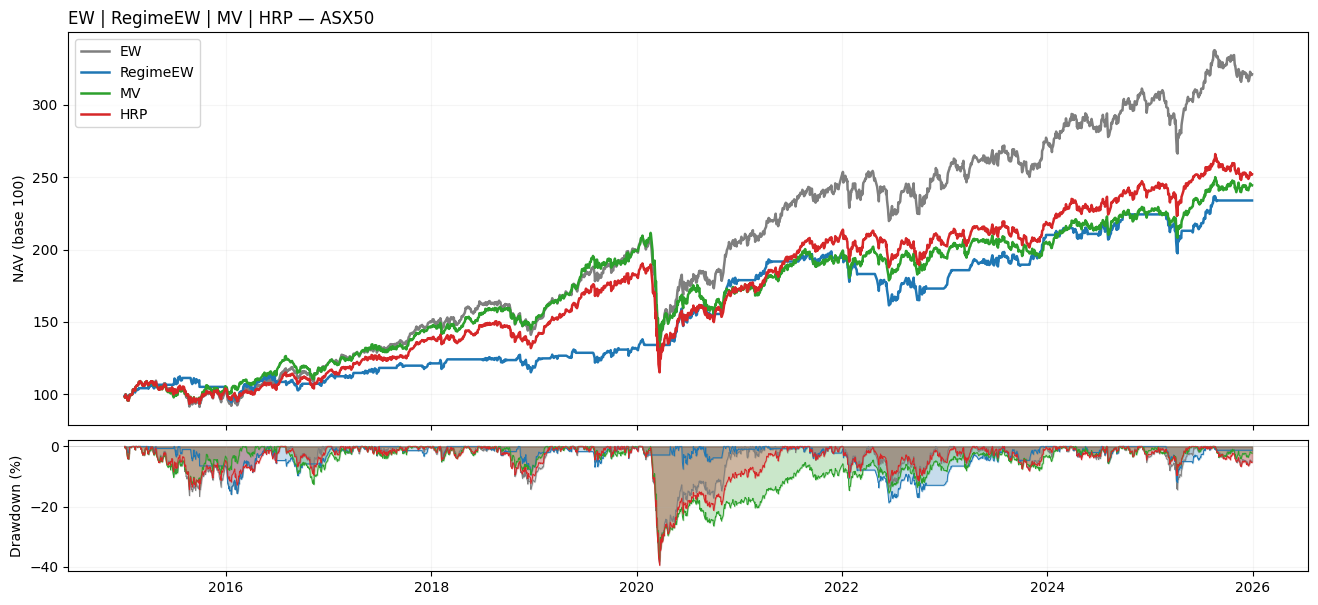


  EUROSTOXX50

  EW … ✓  RegimeEW … ✓  MV … ✓  HRP … ✓


/tmp/ipykernel_1255/3700573891.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


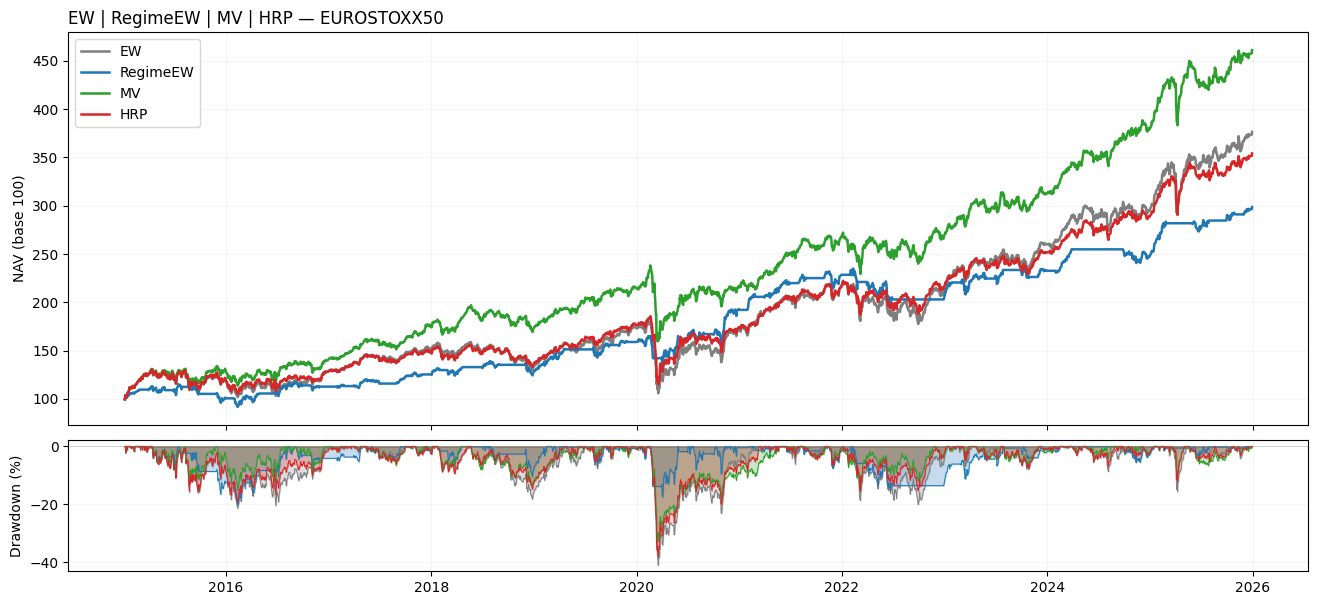


  FTSE100

  EW … ✓  RegimeEW … ✓  MV … ✓  HRP … ✓


/tmp/ipykernel_1255/3700573891.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


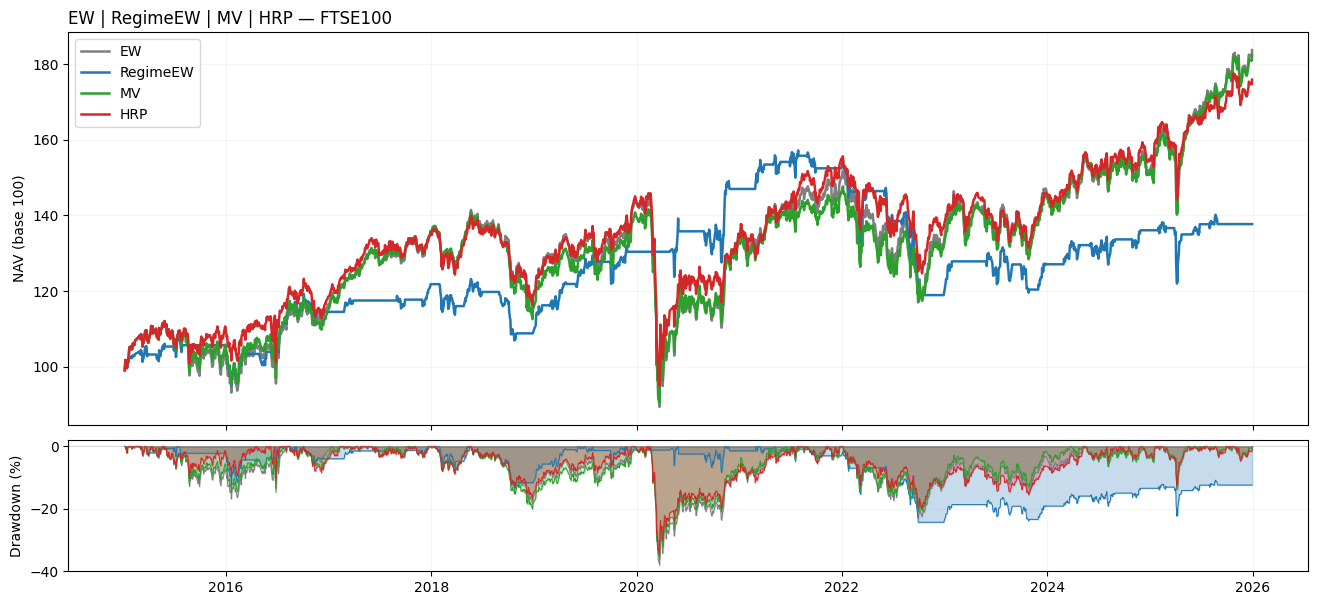


  IBOVESPA

  EW … ✓  RegimeEW … ✓  MV … ✓  HRP … ✓


/tmp/ipykernel_1255/3700573891.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


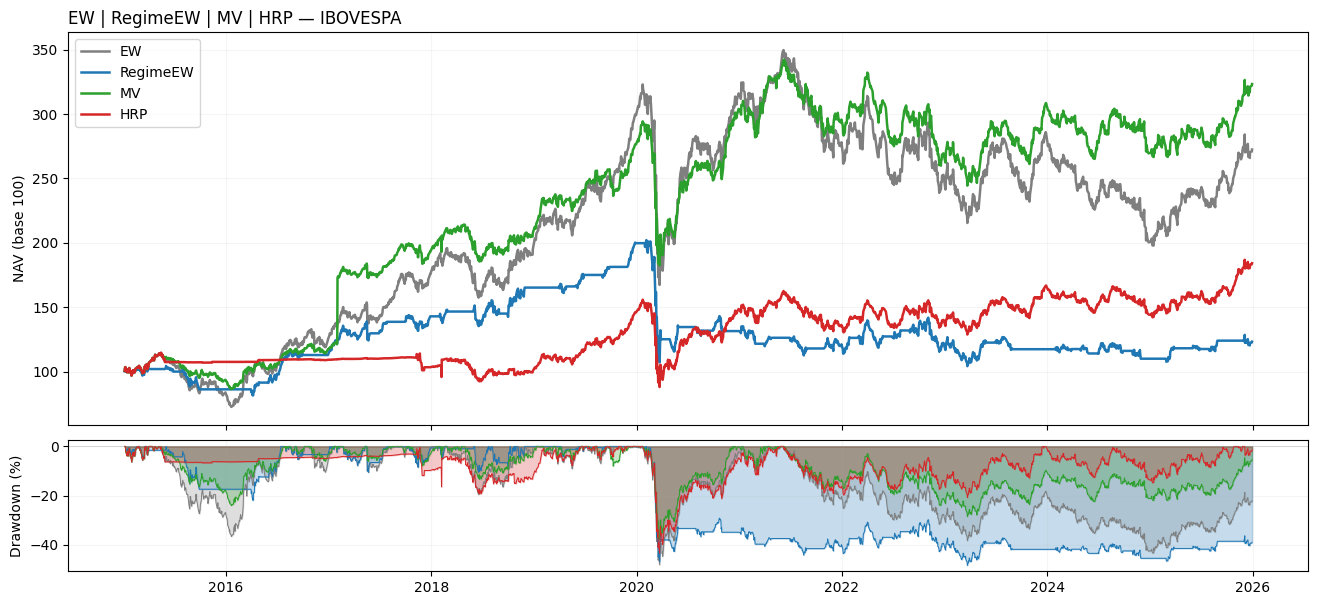


  JSE40

  EW … ✓  RegimeEW … ✓  MV … ✓  HRP … ✓


/tmp/ipykernel_1255/3700573891.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


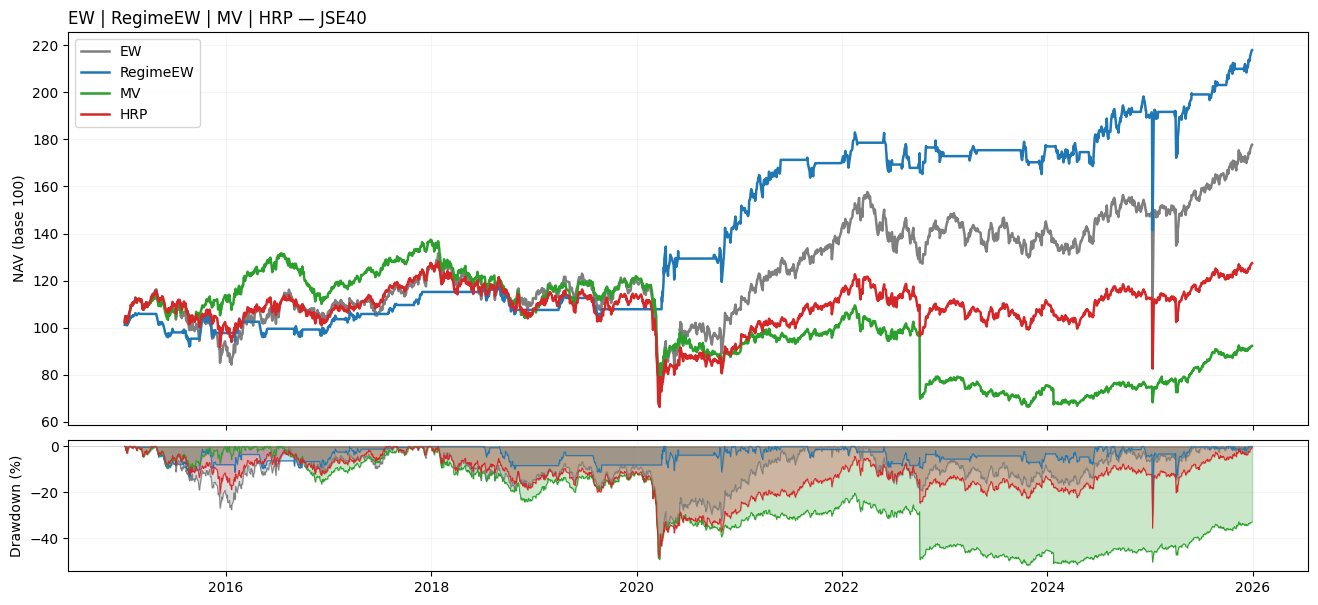


  NIKKEI225

  EW … ✓  RegimeEW … ✓  MV … ✓  HRP … ✓


/tmp/ipykernel_1255/3700573891.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


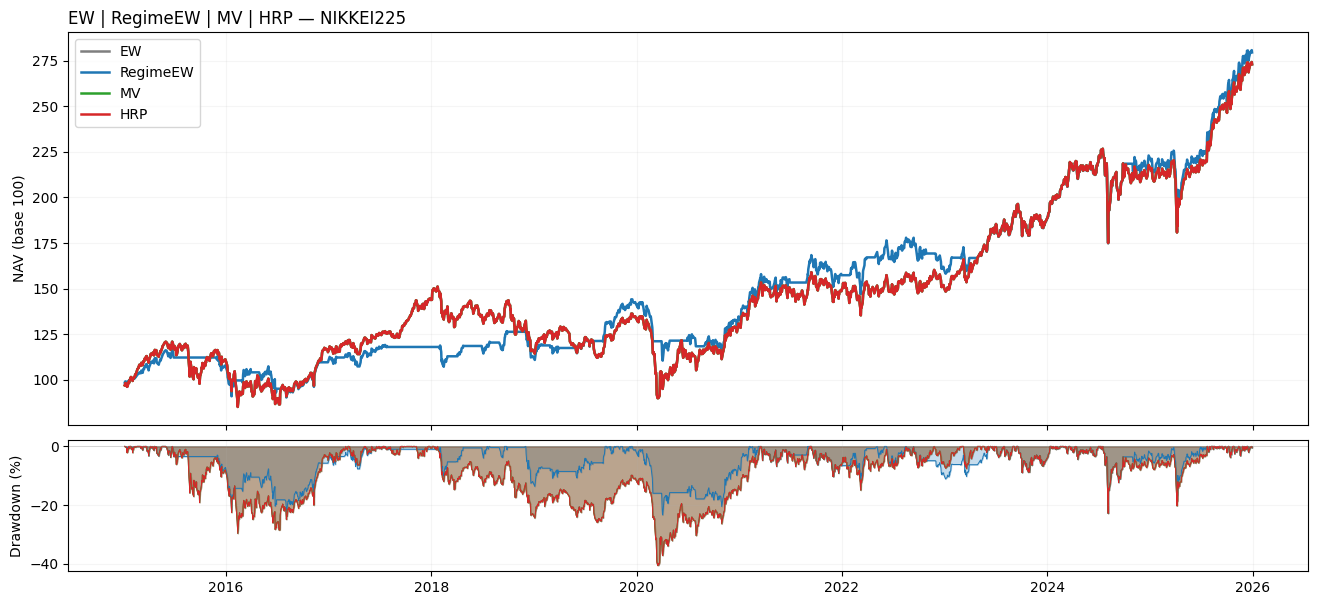


  SP500

  EW … ✓  RegimeEW … ✓  MV … ✓  HRP … ✓


/tmp/ipykernel_1255/3700573891.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


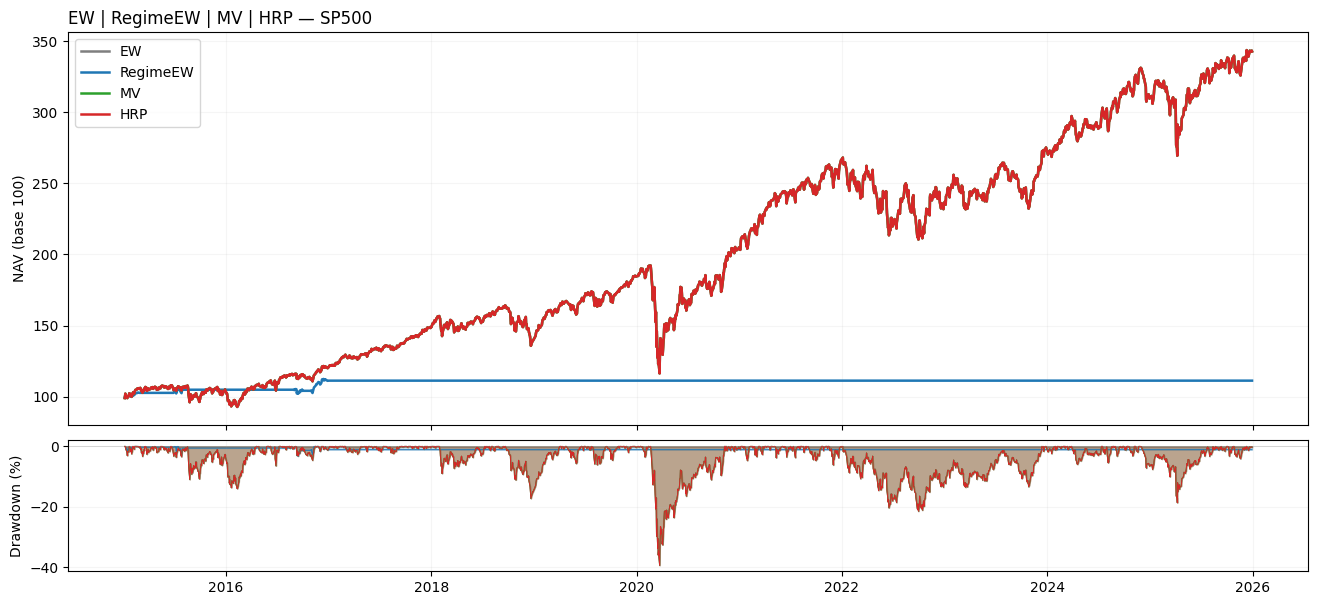


FULL PERFORMANCE SUMMARY
                        Ann. Return (%)  Ann. Vol (%)  Sharpe  Sortino  Calmar  Max DD (%)  CVaR 95% (%)  Total Ret. (%)
Strategy                                                                                                                
ASX50 — EW                        12.18         16.82    0.61     0.72    0.31      -39.27        -40.77          226.62
ASX50 — RegimeEW                   8.88         11.78    0.58     0.75    0.47      -18.76        -30.88          135.90
ASX50 — MV                         9.33         14.94    0.49     0.57    0.25      -37.99        -36.03          148.60
ASX50 — HRP                        9.65         15.37    0.50     0.57    0.24      -39.50        -37.68          156.38
EUROSTOXX50 — EW                  13.85         20.31    0.58     0.69    0.34      -41.13        -50.05          278.08
EUROSTOXX50 — RegimeEW            11.43         13.45    0.70     0.93    0.56      -20.35        -34.63          199.34
EUROST

/tmp/ipykernel_1255/3700573891.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


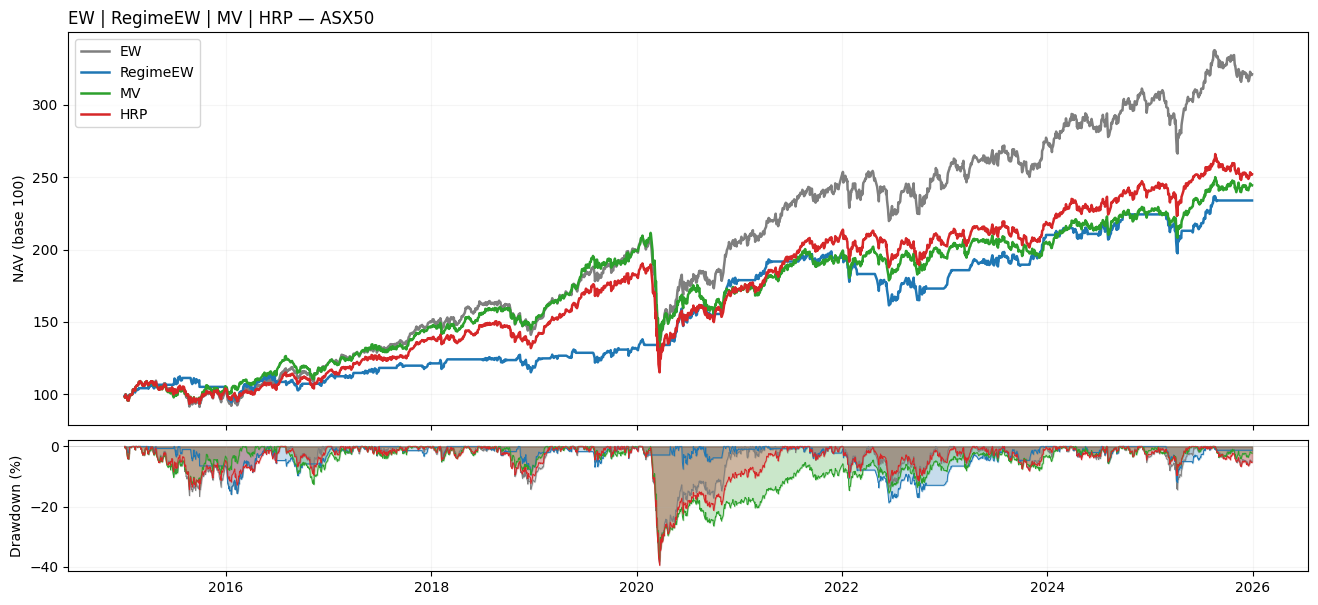


  EUROSTOXX50

  EW … ✓  RegimeEW … ✓  MV … ✓  HRP … ✓


/tmp/ipykernel_1255/3700573891.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


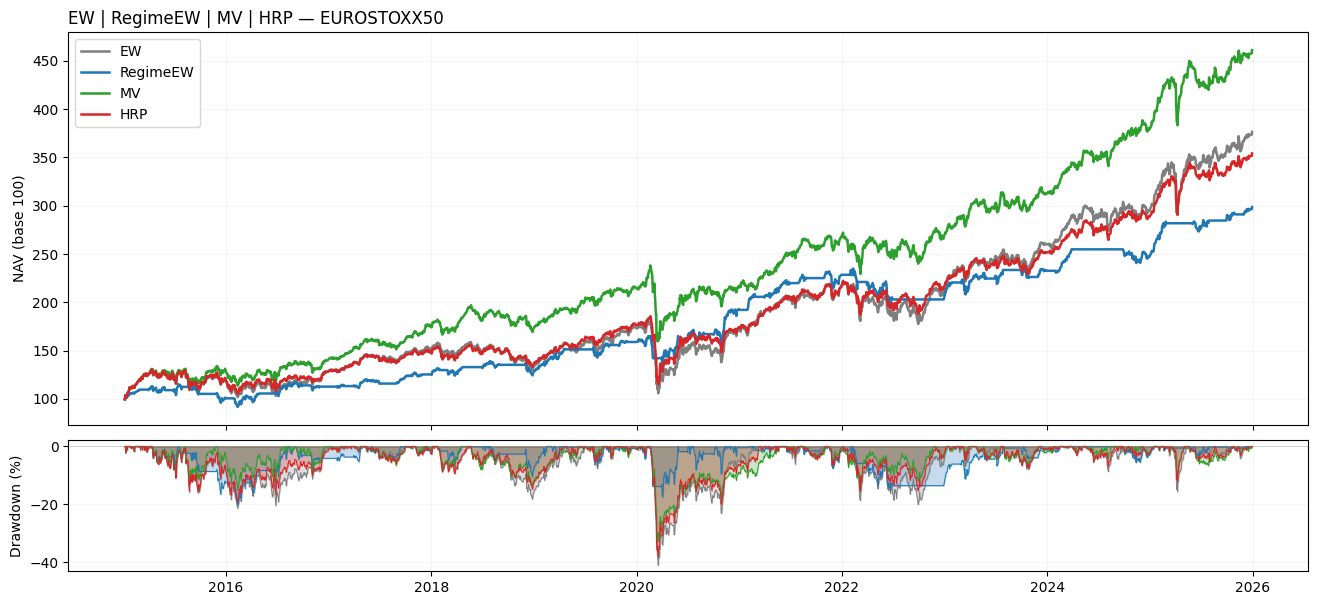


  FTSE100

  EW … ✓  RegimeEW … ✓  MV … ✓  HRP … ✓


/tmp/ipykernel_1255/3700573891.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


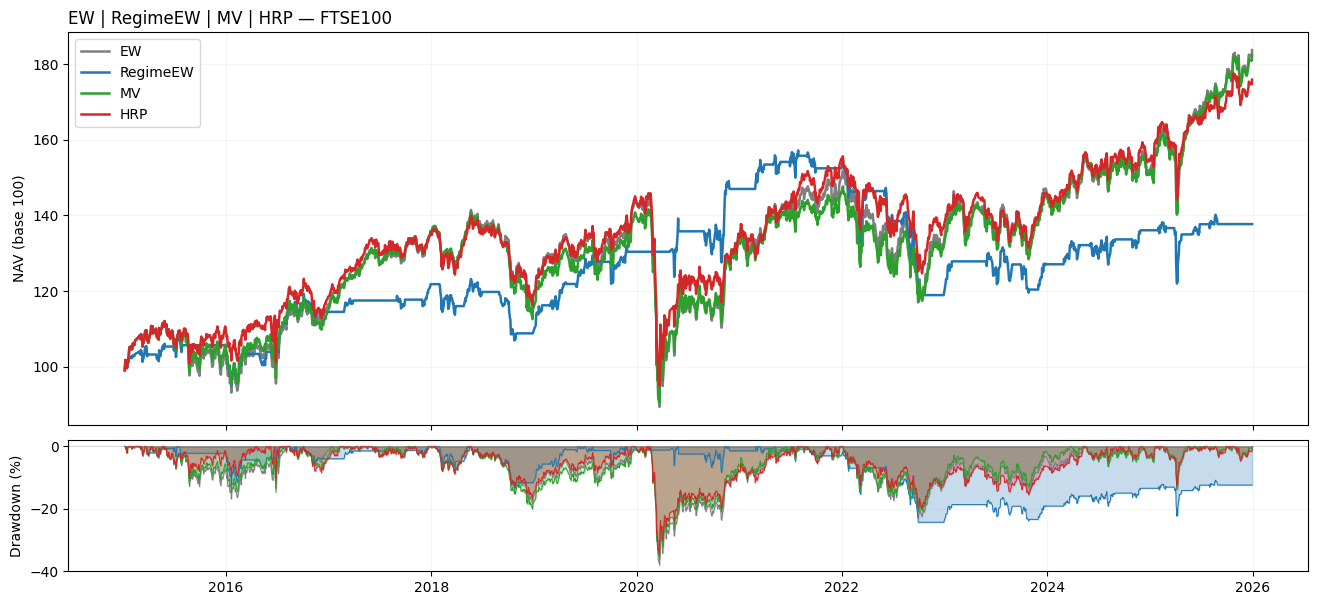


  IBOVESPA

  EW … ✓  RegimeEW … ✓  MV … ✓  HRP … ✓


/tmp/ipykernel_1255/3700573891.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


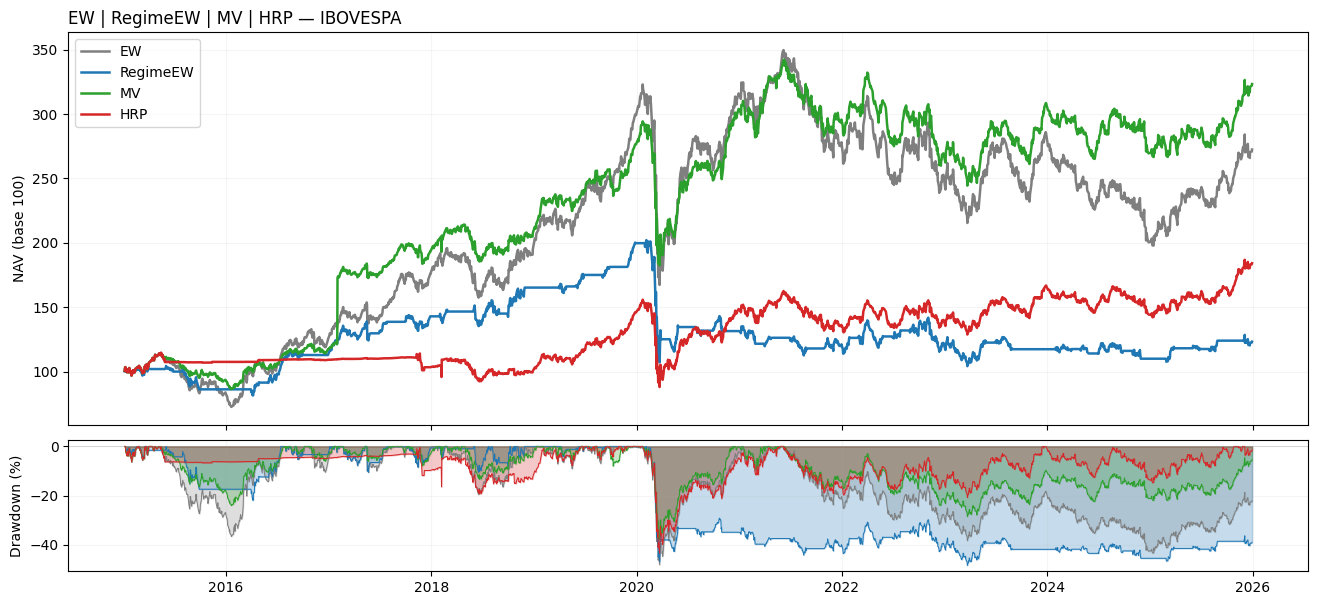


  JSE40

  EW … ✓  RegimeEW … ✓  MV … ✓  HRP … ✓


/tmp/ipykernel_1255/3700573891.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


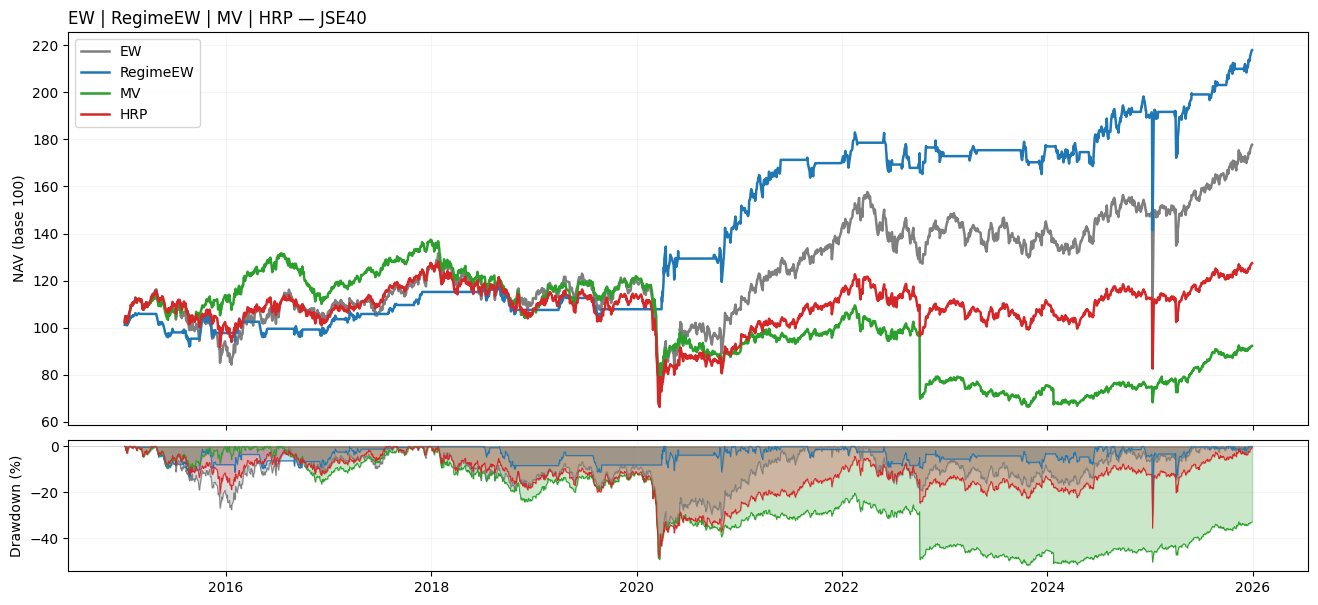


  NIKKEI225

  EW … ✓  RegimeEW … ✓  MV … ✓  HRP … ✓


/tmp/ipykernel_1255/3700573891.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


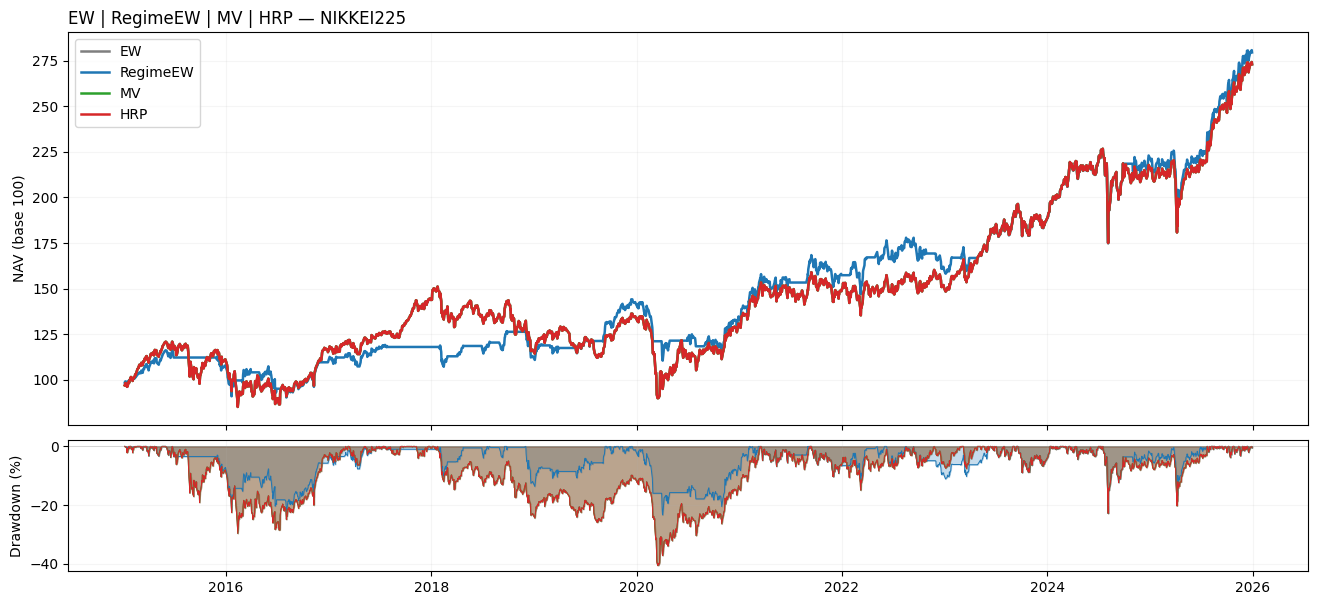


  SP500

  EW … ✓  RegimeEW … ✓  MV … ✓  HRP … ✓


/tmp/ipykernel_1255/3700573891.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


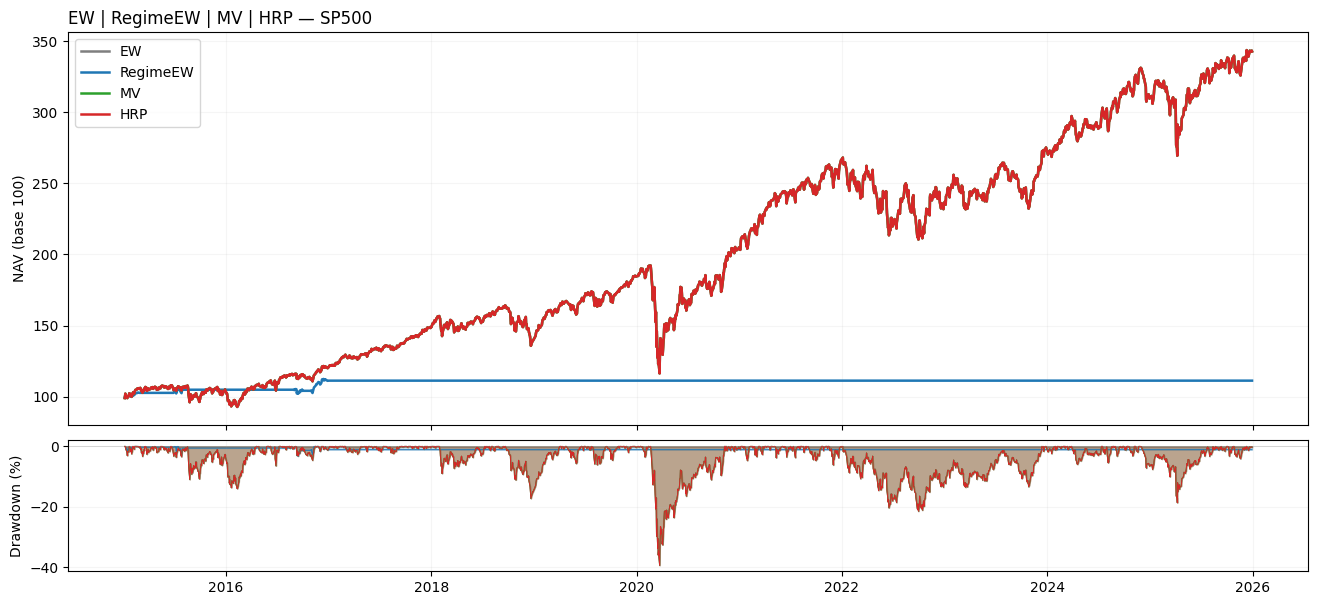


FULL PERFORMANCE SUMMARY
                        Ann. Return (%)  Ann. Vol (%)  Sharpe  Sortino  Calmar  Max DD (%)  CVaR 95% (%)  Total Ret. (%)
Strategy                                                                                                                
ASX50 — EW                        12.18         16.82    0.61     0.72    0.31      -39.27        -40.77          226.62
ASX50 — RegimeEW                   8.88         11.78    0.58     0.75    0.47      -18.76        -30.88          135.90
ASX50 — MV                         9.33         14.94    0.49     0.57    0.25      -37.99        -36.03          148.60
ASX50 — HRP                        9.65         15.37    0.50     0.57    0.24      -39.50        -37.68          156.38
EUROSTOXX50 — EW                  13.85         20.31    0.58     0.69    0.34      -41.13        -50.05          278.08
EUROSTOXX50 — RegimeEW            11.43         13.45    0.70     0.93    0.56      -20.35        -34.63          199.34
EUROST

In [ ]:

"""
04_RegimeModels — Full Patch (disk-based loader)
=================================================
Loads the 8 CSVs from /mnt/user-data/uploads/ (or any local path you set).

Adds:
  1. Disk-based data loader  (no GitHub dependency)
  2. Correct asset-group detection for the actual macro CSV columns
  3. Min-Variance (MV) portfolio  — Ledoit-Wolf shrinkage, SLSQP
  4. Hierarchical Risk Parity (HRP) — López de Prado (2016)
  5. Extended metrics: Sortino, Calmar, CVaR 95%, Total Return
  6. 4-strategy comparison table + NAV/drawdown chart per index

Usage
-----
  python regime_patch.py                          # runs on all indices
  python regime_patch.py --index SP500            # single index
  python regime_patch.py --data-dir /my/csv/dir  # custom data path
"""

import argparse
import warnings
from pathlib import Path
import requests # Added import
from io import StringIO # Added import

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.optimize import minimize
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ============================================================
# 0.  CONFIGURATION
# ============================================================

# DEFAULT_DATA_DIR = Path("/mnt/user-data/uploads") # Removed as data is loaded from GitHub

FILE_MAP = {
    "ASX50":       "streamlined_asx_50.csv",
    "EUROSTOXX50": "streamlined_euro_stoxx_50.csv",
    "FTSE100":     "streamlined_ftse_100.csv",
    "IBOVESPA":    "streamlined_ibovespa.csv",
    "JSE40":       "streamlined_jse_top_40.csv",
    "MACRO":       "streamlined_macro.csv",
    "NIKKEI225":   "streamlined_nikkei_225.csv",
    "SP500":       "streamlined_s&p_500.csv", # Corrected filename
}

# Exact column names as they appear in streamlined_macro.csv
FX_COLS   = ["AUDUSD", "BRLUSD", "EURUSD", "GBPUSD", "JPYUSD", "ZARUSD"]
BOND_KW   = "_10Y"   # all bond columns end with this suffix
RISK_COLS = ["Bitcoin", "Oil", "Gold", "VIX"]


# ============================================================
# 1.  DATA LOADING
# ============================================================

def load_data() -> dict[str, pd.DataFrame]: # Modified signature: removed data_dir
    """Load all index CSVs from GitHub into a dict keyed by index name."""
    base_url = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"
    all_data = {}
    for key, fname in FILE_MAP.items():
        url = base_url + fname
        try:
            response = requests.get(url)
            response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
            df = pd.read_csv(StringIO(response.text), index_col=0, parse_dates=True)
            # Clean column names as done in other cells for consistency
            df.columns = df.columns.str.replace('[^a-zA-Z0-9]', '_', regex=True)
            all_data[key] = df
            print(f"  ✅ {key:15s}  {df.shape}  {df.index[0].date()} → {df.index[-1].date()}")
        except Exception as e:
            print(f"  ❌ Error loading {fname}: {str(e)}")
            continue
    if not all_data:
        raise ValueError("No data files could be loaded from GitHub.")
    return all_data


def build_asset_groups(macro: pd.DataFrame) -> dict[str, list[str]]:
    """Derive the four asset groups from the macro CSV columns."""
    cols = list(macro.columns)
    bonds = [c for c in cols if BOND_KW in c]
    fx    = [c for c in FX_COLS if c in cols]
    risk  = [c for c in RISK_COLS if c in cols]

    groups = {}
    # Equity index prices also live in macro; skip them for group analysis
    if bonds: groups["Bonds"]        = bonds
    if fx:    groups["FX"]           = fx
    if risk:  groups["Risk Factors"] = risk

    print("\n=== Macro asset groups ===")
    for g, m in groups.items():
        print(f"  {g:15s} ({len(m)}): {m}")
    return groups


# ============================================================
# 2.  HELPERS
# ============================================================

def get_log_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    return np.log(price_df / price_df.shift(1)).dropna(how="all")


def cumulative_wealth(ret: pd.Series, base: float = 100.0) -> pd.Series:
    return base * np.exp(ret.cumsum())


def _cov_shrinkage(returns: pd.DataFrame) -> np.ndarray:
    """Ledoit-Wolf analytic shrinkage toward scaled identity (no sklearn needed)."""
    X = returns.values
    n, p = X.shape
    S = np.cov(X, rowvar=False)
    mu = np.trace(S) / p
    F  = mu * np.eye(p)
    delta_sq = np.sum((S - F) ** 2)
    beta_sq  = (1.0 / (n * p)) * np.sum(S ** 2 + F ** 2)
    alpha    = float(np.clip(beta_sq / delta_sq, 0.0, 1.0))
    return alpha * F + (1.0 - alpha) * S


# ============================================================
# 3.  REGIME SIGNAL (unchanged from original)
# ============================================================

def _modified_determinant(corr: pd.DataFrame) -> float:
    mat = corr.dropna(axis=0, how="all").dropna(axis=1, how="all").to_numpy()
    if mat.shape[0] < 2:
        return np.nan
    try:
        return float(np.linalg.det(mat - np.eye(mat.shape[0])))
    except np.linalg.LinAlgError:
        return np.nan


def regime_signal(corr: pd.DataFrame, threshold: float = 0.0) -> float:
    det = _modified_determinant(corr)
    if np.isnan(det):   return 0.5
    if det >  threshold: return 1.0
    if det < -threshold: return 0.0
    return 0.5


# ============================================================
# 4.  PORTFOLIO STRATEGIES
# ============================================================

def ew_portfolio(price_df: pd.DataFrame) -> pd.Series:
    """Plain equally-weighted portfolio."""
    ret = get_log_returns(price_df).mean(axis=1)
    ret.name = "EW"
    return ret


def regime_ew_portfolio(
    price_df: pd.DataFrame,
    signal_window: int = 28,
    threshold: float = 0.0,
) -> pd.Series:
    """Regime-adjusted EW — exposure scaled by modified-determinant signal."""
    lr = get_log_returns(price_df)
    n  = lr.shape[1]
    w  = np.ones(n) / n
    rebal = lr.resample("ME").last().index
    out   = pd.Series(dtype=float, index=lr.index)
    exposure, reb_idx = 0.5, 0

    for date in lr.index:
        if reb_idx < len(rebal) and date >= rebal[reb_idx]:
            hist = lr.loc[:date].iloc[-signal_window:]
            if hist.shape[0] >= 20:
                exposure = regime_signal(hist.corr(method="spearman"), threshold)
            reb_idx += 1
        out.loc[date] = (w @ lr.loc[date].values) * exposure

    out = out.dropna()
    out.name = "RegimeEW"
    return out


def mv_portfolio(
    price_df: pd.DataFrame,
    lookback: int = 126,
    min_w: float = 0.01,
    max_w: float = 0.40,
) -> pd.Series:
    """
    Monthly-rebalanced minimum-variance portfolio.
    Ledoit-Wolf shrinkage covariance; long-only, bounded weights.
    """
    lr = get_log_returns(price_df)
    n  = lr.shape[1]
    rebal = lr.resample("ME").last().index
    out   = pd.Series(dtype=float, index=lr.index)
    w     = np.ones(n) / n
    reb_idx = 0

    for date in lr.index:
        if reb_idx < len(rebal) and date >= rebal[reb_idx]:
            hist = lr.loc[:date].iloc[-lookback:]
            if hist.shape[0] >= max(n + 5, 30):
                Sigma = _cov_shrinkage(hist)
                res = minimize(
                    fun=lambda x: x @ Sigma @ x,
                    x0=w,
                    method="SLSQP",
                    bounds=[(min_w, max_w)] * n,
                    constraints={"type": "eq", "fun": lambda x: x.sum() - 1},
                    options={"ftol": 1e-12, "maxiter": 1000},
                )
                if res.success:
                    w = res.x
            reb_idx += 1
        out.loc[date] = w @ lr.loc[date].values

    out = out.dropna()
    out.name = "MV"
    return out


def _hrp_weights(cov: np.ndarray, corr: np.ndarray) -> np.ndarray:
    """
    López de Prado (2016) HRP:
      distance matrix → Ward clustering → quasi-diagonalise → recursive bisection.
    """
    n    = cov.shape[0]
    dist = np.sqrt(np.clip((1.0 - corr) / 2.0, 0, 1))
    np.fill_diagonal(dist, 0)
    link  = linkage(squareform(dist), method="ward")
    order = leaves_list(link)

    weights  = np.ones(n)
    clusters = [list(order)]

    while clusters:
        nxt = []
        for cluster in clusters:
            if len(cluster) <= 1:
                continue
            mid   = len(cluster) // 2
            left, right = cluster[:mid], cluster[mid:]

            def _cv(idx):
                sub  = cov[np.ix_(idx, idx)]
                w_iv = 1.0 / np.diag(sub)
                w_iv /= w_iv.sum()
                return float(w_iv @ sub @ w_iv)

            cv_l  = _cv(left)
            cv_r  = _cv(right)
            alpha = 1.0 - cv_l / (cv_l + cv_r)
            weights[left]  *= alpha
            weights[right] *= 1.0 - alpha
            nxt += [left, right]
        clusters = nxt

    return weights / weights.sum()


def hrp_portfolio(price_df: pd.DataFrame, lookback: int = 126) -> pd.Series:
    """Monthly-rebalanced HRP with Ledoit-Wolf cov + Spearman corr."""
    lr = get_log_returns(price_df)
    n  = lr.shape[1]
    rebal = lr.resample("ME").last().index
    out   = pd.Series(dtype=float, index=lr.index)
    w     = np.ones(n) / n
    reb_idx = 0

    for date in lr.index:
        if reb_idx < len(rebal) and date >= rebal[reb_idx]:
            hist = lr.loc[:date].iloc[-lookback:]
            if hist.shape[0] >= max(n + 5, 30):
                Sigma = _cov_shrinkage(hist)
                corr  = hist.corr(method="spearman").to_numpy()
                np.fill_diagonal(corr, 1.0)
                try:
                    w = _hrp_weights(Sigma, corr)
                except Exception:
                    pass
            reb_idx += 1
        out.loc[date] = w @ lr.loc[date].values

    out = out.dropna()
    out.name = "HRP"
    return out


# ============================================================
# 5.  EXTENDED METRICS
# ============================================================

def metrics(ret: pd.Series, name: str = "Portfolio", rf: float = 0.02) -> dict:
    r = ret.dropna()
    if len(r) == 0:
        return {"Strategy": name}

    td       = 252
    rf_d     = rf / td
    ann_ret  = r.mean() * td
    ann_vol  = r.std()  * np.sqrt(td)
    sharpe   = (ann_ret - rf) / ann_vol if ann_vol > 0 else np.nan

    down     = r[r < rf_d]
    dd_vol   = down.std() * np.sqrt(td) if len(down) > 1 else np.nan
    sortino  = (ann_ret - rf) / dd_vol  if (dd_vol and dd_vol > 0) else np.nan

    wealth   = cumulative_wealth(r)
    roll_mx  = wealth.expanding().max()
    dd_ser   = (wealth - roll_mx) / roll_mx
    max_dd   = dd_ser.min()
    calmar   = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    var95    = np.percentile(r, 5)
    cvar95   = r[r <= var95].mean() * np.sqrt(td)

    total_r  = (wealth.iloc[-1] / wealth.iloc[0] - 1) * 100

    return {
        "Strategy":         name,
        "Ann. Return (%)":  round(ann_ret * 100, 2),
        "Ann. Vol (%)":     round(ann_vol * 100, 2),
        "Sharpe":           round(sharpe,  3) if not np.isnan(sharpe)  else np.nan,
        "Sortino":          round(sortino, 3) if not np.isnan(sortino) else np.nan,
        "Calmar":           round(calmar,  3) if not np.isnan(calmar)  else np.nan,
        "Max DD (%)":       round(max_dd  * 100, 2),
        "CVaR 95% (%)":     round(cvar95  * 100, 2),
        "Total Ret. (%)":   round(total_r, 2),
    }


# ============================================================
# 6.  COMPARISON RUNNER + CHART
# ============================================================

COLORS = {"EW": "#7f7f7f", "RegimeEW": "#1f77b4", "MV": "#2ca02c", "HRP": "#d62728"}


def run_index(price_df: pd.DataFrame, label: str) -> tuple[pd.DataFrame, dict]:
    print(f"\n  EW …", end=" ", flush=True)
    ew  = ew_portfolio(price_df);         print("✓  RegimeEW …", end=" ", flush=True)
    re  = regime_ew_portfolio(price_df);  print("✓  MV …",       end=" ", flush=True)
    mv  = mv_portfolio(price_df);         print("✓  HRP …",      end=" ", flush=True)
    hrp = hrp_portfolio(price_df);        print("✓")

    strats = {"EW": ew, "RegimeEW": re, "MV": mv, "HRP": hrp}
    rows   = [metrics(r, name=f"{label} — {n}") for n, r in strats.items()]
    return pd.DataFrame(rows).set_index("Strategy"), strats


def plot_index(strats: dict, label: str):
    fig = plt.figure(figsize=(16, 7))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.06)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    for name, ret in strats.items():
        w   = cumulative_wealth(ret)
        dd  = (w - w.expanding().max()) / w.expanding().max() * 100
        c   = COLORS[name]
        ax1.plot(w, label=name, color=c, linewidth=1.8)
        ax2.fill_between(dd.index, dd, 0, alpha=0.25, color=c)
        ax2.plot(dd, linewidth=0.7, color=c)

    ax1.set_ylabel("NAV (base 100)")
    ax1.set_title(f"EW | RegimeEW | MV | HRP — {label}", loc="left")
    ax1.legend(); ax1.grid(True, alpha=0.12)
    plt.setp(ax1.get_xticklabels(), visible=False)
    ax2.set_ylabel("Drawdown (%)")
    ax2.axhline(0, color="gray", linewidth=0.4, alpha=0.5)
    ax2.grid(True, alpha=0.12)
    plt.tight_layout()

    # Create output directory if it doesn't exist
    output_dir = Path("/mnt/user-data/outputs")
    output_dir.mkdir(parents=True, exist_ok=True)

    plt.savefig(output_dir / f"chart_{label}.png", dpi=130, bbox_inches="tight")
    plt.show()
    plt.close()


# ============================================================
# 7.  MAIN
# ============================================================

def main(only_index: str = None): # Modified signature: removed data_dir
    print("Loading data …")
    all_data = load_data() # Modified call: no data_dir argument
    # Check if 'MACRO' data was successfully loaded before accessing it
    if "MACRO" in all_data:
        build_asset_groups(all_data["MACRO"])
    else:
        print("\n⚠️  MACRO data not available, skipping asset group analysis.")

    equity_indices = {k: v for k, v in all_data.items() if k != "MACRO"}
    if only_index:
        equity_indices = {k: v for k, v in equity_indices.items() if k == only_index.upper()}
        if not equity_indices:
            raise ValueError(f"Unknown index: {only_index}. Valid: {list(all_data.keys())}")

    all_metrics = []
    for idx_name, price_df in equity_indices.items():
        print(f"\n{'='*60}\n  {idx_name}")
        mdf, strats = run_index(price_df, idx_name)
        all_metrics.append(mdf)
        plot_index(strats, idx_name)

    summary = pd.concat(all_metrics)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 160)
    pd.set_option("display.float_format", "{:.2f}".format)

    print("\n" + "=" * 90)
    print("FULL PERFORMANCE SUMMARY")
    print("=" * 90)
    print(summary.to_string())

    out = Path("/mnt/user-data/outputs/strategy_comparison.csv")
    summary.to_csv(out)
    print(f"\n✅ Saved → {out}")
    return summary


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    # parser.add_argument("--data-dir",     default=str(DEFAULT_DATA_DIR)) # Removed data-dir argument
    parser.add_argument("--index",        default=None)
    parser.add_argument("--drive-folder", default=None,
                        help="Google Drive folder ID to upload outputs after run")
    args, unknown = parser.parse_known_args()

    summary = main(only_index=args.index) # Modified call: no data_dir argument

    if args.drive_folder is not None:
        print("\nUploading outputs to Google Drive …")
        upload_outputs_to_drive(folder_id=args.drive_folder)
    elif Path(str(Path.home() / "gdrive_service_account.json")).exists() \
         or Path("token.json").exists():
        print("\nGoogle credentials detected — uploading outputs …")
        upload_outputs_to_drive()


# ============================================================
# 8.  GOOGLE DRIVE UPLOAD  (optional, runs if credentials exist)
# ============================================================

def upload_to_google_drive(file_path: str, folder_id: str = None):
    """
    Upload a local file to Google Drive using a service-account JSON key
    OR an OAuth2 token.  Call this after main() has saved the CSV.

    Setup (one-time):
      Option A — Service Account (recommended for scripts):
        1. Go to https://console.cloud.google.com → IAM & Admin → Service Accounts
        2. Create a service account, grant it "Editor" or "Drive File Creator"
        3. Download the JSON key → save as  ~/gdrive_service_account.json
        4. Share the target Drive folder with the service account email

      Option B — OAuth2 (personal Google account):
        pip install google-auth-oauthlib
        Run the snippet below once to generate token.json, then reuse it.

    Args:
        file_path  : local path to the file you want to upload
        folder_id  : Google Drive folder ID (from the folder URL after /folders/)
                     Leave None to upload to root "My Drive"
    """
    try:
        from googleapiclient.discovery import build
        from googleapiclient.http import MediaFileUpload
        from google.oauth2 import service_account
        from google.oauth2.credentials import Credentials
    except ImportError:
        print("\n⚠️  Google API client not installed.")
        print("    Run:  pip install google-api-python-client google-auth")
        return

    import os, mimetypes
    from pathlib import Path

    SCOPES = ["https://www.googleapis.com/auth/drive.file"]

    # ── Credential resolution ────────────────────────
    creds = None

    # 1. Service account key (highest priority)
    sa_path = os.environ.get(
        "GDRIVE_SERVICE_ACCOUNT",
        str(Path.home() / "gdrive_service_account.json"),
    )
    if Path(sa_path).exists():
        creds = service_account.Credentials.from_service_account_file(
            sa_path, scopes=SCOPES
        )
        print(f"  🔑 Using service account: {sa_path}")

    # 2. OAuth2 token.json (personal account)
    elif Path("token.json").exists():
        creds = Credentials.from_authorized_user_file("token.json", SCOPES)
        print("  🔑 Using OAuth2 token: token.json")

    else:
        print("\n⚠️  No Google credentials found.")
        print("    Set env var GDRIVE_SERVICE_ACCOUNT=/path/to/key.json")
        print("    or run the OAuth2 flow once (see docstring above).")
        return

    # ── Upload ──────────────────────────────
    service = build("drive", "v3", credentials=creds)

    file_path = Path(file_path)
    mime_type, _ = mimetypes.guess_type(str(file_path))
    mime_type = mime_type or "application/octet-stream"

    metadata = {"name": file_path.name}
    if folder_id:
        metadata["parents"] = [folder_id]

    media = MediaFileUpload(str(file_path), mimetype=mime_type, resumable=True)

    uploaded = (
        service.files()
        .create(body=metadata, media_body=media, fields="id, name, webViewLink")
        .execute()
    )

    print(f"\n✅ Uploaded to Google Drive:")
    print(f"   Name : {uploaded['name']}")
    print(f"   ID   : {uploaded['id']}")
    print(f"   Link : {uploaded.get('webViewLink', 'n/a')}")
    return uploaded


# ── convenience wrapper called at end of main() ─────────────────
def upload_outputs_to_drive(folder_id: str = None):
    """Upload both output files (CSV + notebook) to Drive."""
    outputs = [
        "/mnt/user-data/outputs/strategy_comparison.csv",
        "/mnt/user-data/outputs/04_RegimeModels_Patched.ipynb",
    ]
    for f in outputs:
        if Path(f).exists():
            upload_to_google_drive(f, folder_id=folder_id)
        else:
            print(f"  ⚠️  File not found, skipping: {f}")


# ── hook into __main__ ──────────────────────
# Add  --drive-folder <FOLDER_ID>  to automatically upload after the run.
# Example:
#   python regime_patch.py --drive-folder 1A2B3C4D5E6F7G8H
#
# The folder ID is the last segment of your Google Drive folder URL:
#   https://drive.google.com/drive/folders/1A2B3C4D5E6F7G8H
#                                           ^^^^^^^^^^^^^^^^

if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser()
    # parser.add_argument("--data-dir",     default=str(DEFAULT_DATA_DIR)) # Removed data-dir argument
    parser.add_argument("--index",        default=None)
    parser.add_argument("--drive-folder", default=None,
                        help="Google Drive folder ID to upload outputs after run")
    args, unknown = parser.parse_known_args()

    summary = main(only_index=args.index) # Modified call: no data_dir argument

    if args.drive_folder is not None:
        print("\nUploading outputs to Google Drive …")
        upload_outputs_to_drive(folder_id=args.drive_folder)
    elif Path(str(Path.home() / "gdrive_service_account.json")).exists() \
         or Path("token.json").exists():
        print("\nGoogle credentials detected — uploading outputs …")
        upload_outputs_to_drive()


In [ ]:
"""
04_RegimeModels — Full Patch v2  (short-selling edition)
=========================================================
Loads the 8 CSVs from disk (no GitHub dependency).

What's new vs v1
----------------
  MV        — negative weights allowed (min_w=-0.25); gross exposure cap Σ|w|≤1.3;
               daily borrow cost deducted on short positions
  HRP       — long-only base; short overlay when det_ema5 < -2σ AND confirmed
  RegimeEW  — exposure extended to {-0.5, 0, 0.5, 1}; -0.5 gated by same signal
  Metrics   — turnover cost + borrow cost deducted; net vs gross return reported
  All       — Sortino, Calmar, CVaR 95%, Total Return in every metrics row

Usage
-----
  python regime_patch.py                          # all indices
  python regime_patch.py --index SP500            # single index
  python regime_patch.py --data-dir /my/csvs      # custom path
  python regime_patch.py --drive-folder <ID>      # + upload to Google Drive
"""

import argparse
import warnings
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.optimize import minimize
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ============================================================
# 0.  CONFIGURATION
# ============================================================

DEFAULT_DATA_DIR = Path("/mnt/user-data/uploads")

FILE_MAP = {
    "ASX50":       "streamlined_asx_50.csv",
    "EUROSTOXX50": "streamlined_euro_stoxx_50.csv",
    "FTSE100":     "streamlined_ftse_100.csv",
    "IBOVESPA":    "streamlined_ibovespa.csv",
    "JSE40":       "streamlined_jse_top_40.csv",
    "MACRO":       "streamlined_macro.csv",
    "NIKKEI225":   "streamlined_nikkei_225.csv",
    "SP500":       "streamlined_s_p_500.csv",
}

FX_COLS   = ["AUDUSD", "BRLUSD", "EURUSD", "GBPUSD", "JPYUSD", "ZARUSD"]
BOND_KW   = "_10Y"
RISK_COLS = ["Bitcoin", "Oil", "Gold", "VIX"]

# Short-selling parameters
SIGNAL_WINDOW     = 28          # rolling window for determinant
EMA_SPAN          = 5           # smoothing span before acting on signal
SHORT_SIGMA       = 2.0         # how many σ below mean to trigger short
BORROW_RATE_BPS   = 50          # annual borrow cost on short positions (bps)
HALF_SPREAD_BPS   = 3           # one-way transaction cost per unit of turnover
MAX_GROSS         = 1.30        # gross exposure cap: Σ|w| ≤ MAX_GROSS
SHORT_OVERLAY_W   = -0.10       # HRP short overlay weight per asset when triggered
COLORS = {"EW": "#7f7f7f", "RegimeEW": "#1f77b4", "MV": "#2ca02c", "HRP": "#d62728"}

# ============================================================
# 1.  DATA LOADING
# ============================================================

def load_data(data_dir: Path = DEFAULT_DATA_DIR) -> dict:
    all_data = {}
    for key, fname in FILE_MAP.items():
        df = pd.read_csv(data_dir / fname, index_col=0, parse_dates=True)
        all_data[key] = df
        print(f"  ✅ {key:15s}  {df.shape}  "
              f"{df.index[0].date()} → {df.index[-1].date()}")
    return all_data


def build_asset_groups(macro: pd.DataFrame) -> dict:
    cols  = list(macro.columns)
    bonds = [c for c in cols if BOND_KW in c]
    fx    = [c for c in FX_COLS if c in cols]
    risk  = [c for c in RISK_COLS if c in cols]
    groups = {}
    if bonds: groups["Bonds"]        = bonds
    if fx:    groups["FX"]           = fx
    if risk:  groups["Risk Factors"] = risk
    print("\n=== Macro asset groups ===")
    for g, m in groups.items():
        print(f"  {g:15s} ({len(m)}): {m}")
    return groups


# ============================================================
# 2.  HELPERS
# ============================================================

def get_log_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    return np.log(price_df / price_df.shift(1)).dropna(how="all")


def cumulative_wealth(ret: pd.Series, base: float = 100.0) -> pd.Series:
    return base * np.exp(ret.cumsum())


def _cov_shrinkage(returns: pd.DataFrame) -> np.ndarray:
    """Ledoit-Wolf analytic shrinkage toward scaled identity."""
    X = returns.values
    n, p = X.shape
    S  = np.cov(X, rowvar=False)
    mu = np.trace(S) / p
    F  = mu * np.eye(p)
    d2 = np.sum((S - F) ** 2)
    b2 = (1.0 / (n * p)) * np.sum(S ** 2 + F ** 2)
    a  = float(np.clip(b2 / d2, 0.0, 1.0))
    return a * F + (1.0 - a) * S


# ============================================================
# 3.  REGIME SIGNAL  (with -2σ short gate)
# ============================================================

def _modified_det(corr: pd.DataFrame) -> float:
    mat = corr.dropna(axis=0, how="all").dropna(axis=1, how="all").to_numpy()
    if mat.shape[0] < 2:
        return np.nan
    try:
        return float(np.linalg.det(mat - np.eye(mat.shape[0])))
    except np.linalg.LinAlgError:
        return np.nan


def build_det_series(lr: pd.DataFrame, window: int = SIGNAL_WINDOW) -> pd.Series:
    """Rolling modified determinant across the full return history."""
    det = pd.Series(dtype=float, index=lr.index)
    for i in range(window, len(lr)):
        det.iloc[i] = _modified_det(lr.iloc[i - window:i].corr(method="spearman"))
    return det.dropna()


def build_signal(det: pd.Series,
                 ema_span: int    = EMA_SPAN,
                 n_sigma:  float  = SHORT_SIGMA) -> pd.DataFrame:
    """
    Returns a DataFrame with columns:
      det_raw   — raw rolling determinant
      det_ema   — EMA-smoothed determinant
      threshold — rolling -n_sigma level (expanding std)
      long_sig  — 1 if risk-on, 0 if neutral/flat
      short_sig — 1 if short eligible (det_ema < -n_sigma AND confirmed)
    """
    det_ema   = det.ewm(span=ema_span, adjust=False).mean()
    roll_mean = det.expanding().mean()
    roll_std  = det.expanding().std().fillna(det.std())
    threshold = roll_mean - n_sigma * roll_std

    long_sig  = (det > 0).astype(int)              # original binary signal
    short_sig = (det_ema < threshold).astype(int)  # new: only fires ~2% of days

    return pd.DataFrame({
        "det_raw":   det,
        "det_ema":   det_ema,
        "threshold": threshold,
        "long_sig":  long_sig,
        "short_sig": short_sig,
    })


# ============================================================
# 4.  TRANSACTION COST HELPERS
# ============================================================

def _turnover_cost(w_new: np.ndarray, w_old: np.ndarray,
                   half_spread_bps: float = HALF_SPREAD_BPS) -> float:
    """One-way cost of rebalancing from w_old to w_new (as daily return drag)."""
    return np.sum(np.abs(w_new - w_old)) * (half_spread_bps / 10_000)


def _daily_borrow_cost(w: np.ndarray,
                       borrow_rate_bps: float = BORROW_RATE_BPS) -> float:
    """Daily borrow cost on short legs (annualised rate / 252)."""
    short_exposure = np.sum(np.maximum(0.0, -w))
    return short_exposure * (borrow_rate_bps / 10_000) / 252


# ============================================================
# 5.  PORTFOLIO STRATEGIES
# ============================================================

# ---- 5a. EW (baseline, long-only) ----
def ew_portfolio(price_df: pd.DataFrame) -> pd.Series:
    ret = get_log_returns(price_df).mean(axis=1)
    ret.name = "EW"
    return ret


# ---- 5b. RegimeEW  (extended exposure: -0.5 / 0 / 0.5 / 1) ----
def regime_ew_portfolio(
    price_df: pd.DataFrame,
    signal_window: int   = SIGNAL_WINDOW,
    ema_span: int        = EMA_SPAN,
    n_sigma: float       = SHORT_SIGMA,
    half_spread_bps: float = HALF_SPREAD_BPS,
    borrow_rate_bps: float = BORROW_RATE_BPS,
) -> pd.Series:
    """
    Exposure scale: {-0.5, 0, 0.5, 1}
      1.0  — det > 0             (risk-on, fully invested)
      0.5  — det = 0 (neutral)   (half-invested)
      0.0  — det < 0 but > -2σ  (flat, no position)
      -0.5 — det_ema < -2σ      (net short, low turnover)
    Costs: turnover + borrow deducted each rebalance / day.
    """
    lr = get_log_returns(price_df)
    n  = lr.shape[1]
    w  = np.ones(n) / n
    rebal = lr.resample("ME").last().index

    det  = build_det_series(lr, signal_window)
    sigs = build_signal(det, ema_span, n_sigma)

    out  = pd.Series(dtype=float, index=lr.index)
    exposure, reb_idx = 0.5, 0

    for date in lr.index:
        if date not in sigs.index:
            out.loc[date] = 0.0
            continue

        # Rebalance monthly
        if reb_idx < len(rebal) and date >= rebal[reb_idx]:
            reb_idx += 1

        row = sigs.loc[date]
        if row["short_sig"] == 1:
            new_exposure = -0.5
        elif row["det_raw"] > 0:
            new_exposure = 1.0
        elif row["det_raw"] == 0:
            new_exposure = 0.5
        else:
            new_exposure = 0.0

        gross_ret = (w @ lr.loc[date].values) * new_exposure
        tc  = _turnover_cost(
            np.full(n, new_exposure / n),
            np.full(n, exposure / n),
            half_spread_bps,
        ) if new_exposure != exposure else 0.0
        borrow = _daily_borrow_cost(
            np.full(n, new_exposure / n), borrow_rate_bps
        )
        out.loc[date] = gross_ret - tc - borrow
        exposure = new_exposure

    out = out.dropna()
    out.name = "RegimeEW"
    return out


# ---- 5c. MV  (allows negative weights, gross cap, borrow cost) ----
def mv_portfolio(
    price_df: pd.DataFrame,
    lookback: int          = 126,
    min_w: float           = -0.25,   # allow shorts up to -25%
    max_w: float           = 0.40,
    max_gross: float       = MAX_GROSS,
    half_spread_bps: float = HALF_SPREAD_BPS,
    borrow_rate_bps: float = BORROW_RATE_BPS,
) -> pd.Series:
    """
    Monthly-rebalanced minimum-variance portfolio.
    Ledoit-Wolf shrinkage cov. Gross exposure constrained: Σ|w| ≤ max_gross.
    Negative weights allowed; borrow cost + turnover deducted daily.
    """
    lr = get_log_returns(price_df)
    n  = lr.shape[1]
    rebal = lr.resample("ME").last().index
    out   = pd.Series(dtype=float, index=lr.index)
    w     = np.ones(n) / n
    reb_idx = 0

    for date in lr.index:
        if reb_idx < len(rebal) and date >= rebal[reb_idx]:
            hist = lr.loc[:date].iloc[-lookback:]
            if hist.shape[0] >= max(n + 5, 30):
                Sigma = _cov_shrinkage(hist)
                w0    = w.copy()

                def portfolio_var(x):
                    return x @ Sigma @ x

                constraints = [
                    {"type": "eq",  "fun": lambda x: x.sum() - 1},
                    {"type": "ineq","fun": lambda x: max_gross - np.sum(np.abs(x))},
                ]
                res = minimize(
                    portfolio_var, w0,
                    method="SLSQP",
                    bounds=[(min_w, max_w)] * n,
                    constraints=constraints,
                    options={"ftol": 1e-12, "maxiter": 2000},
                )
                if res.success:
                    w_new = res.x
                    tc = _turnover_cost(w_new, w, half_spread_bps)
                    w  = w_new
                    out.loc[date] = (w @ lr.loc[date].values) - tc - _daily_borrow_cost(w, borrow_rate_bps)
                    reb_idx += 1
                    continue
            reb_idx += 1

        out.loc[date] = (w @ lr.loc[date].values) - _daily_borrow_cost(w, borrow_rate_bps)

    out = out.dropna()
    out.name = "MV"
    return out


# ---- 5d. HRP  (long-only base + short overlay on -2σ signal) ----
def _hrp_weights(cov: np.ndarray, corr: np.ndarray) -> np.ndarray:
    """López de Prado (2016) recursive bisection."""
    n    = cov.shape[0]
    dist = np.sqrt(np.clip((1.0 - corr) / 2.0, 0, 1))
    np.fill_diagonal(dist, 0)
    link  = linkage(squareform(dist), method="ward")
    order = leaves_list(link)
    weights  = np.ones(n)
    clusters = [list(order)]

    while clusters:
        nxt = []
        for cl in clusters:
            if len(cl) <= 1:
                continue
            mid = len(cl) // 2
            lft, rgt = cl[:mid], cl[mid:]

            def _cv(idx):
                sub  = cov[np.ix_(idx, idx)]
                iv   = 1.0 / np.diag(sub)
                iv  /= iv.sum()
                return float(iv @ sub @ iv)

            a = 1.0 - _cv(lft) / (_cv(lft) + _cv(rgt))
            weights[lft]  *= a
            weights[rgt]  *= (1.0 - a)
            nxt += [lft, rgt]
        clusters = nxt

    return weights / weights.sum()


def hrp_portfolio(
    price_df: pd.DataFrame,
    lookback: int          = 126,
    ema_span: int          = EMA_SPAN,
    n_sigma: float         = SHORT_SIGMA,
    short_overlay_w: float = SHORT_OVERLAY_W,
    half_spread_bps: float = HALF_SPREAD_BPS,
    borrow_rate_bps: float = BORROW_RATE_BPS,
) -> pd.Series:
    """
    Monthly-rebalanced HRP (Ledoit-Wolf cov + Spearman corr).
    Short overlay: when det_ema5 < -2σ, adds `short_overlay_w` to the
    highest-correlation asset (= -10% short on the most contagious index).
    Turnover + borrow cost deducted.
    """
    lr = get_log_returns(price_df)
    n  = lr.shape[1]
    rebal = lr.resample("ME").last().index

    det  = build_det_series(lr, SIGNAL_WINDOW)
    sigs = build_signal(det, ema_span, n_sigma)

    out   = pd.Series(dtype=float, index=lr.index)
    w_base = np.ones(n) / n   # base HRP weights
    w_eff  = w_base.copy()    # effective weights including overlay
    reb_idx = 0

    for date in lr.index:
        if date not in sigs.index:
            out.loc[date] = 0.0
            continue

        # Monthly rebalance: update base HRP weights
        if reb_idx < len(rebal) and date >= rebal[reb_idx]:
            hist = lr.loc[:date].iloc[-lookback:]
            if hist.shape[0] >= max(n + 5, 30):
                Sigma = _cov_shrinkage(hist)
                corr  = hist.corr(method="spearman").to_numpy().copy()
                np.fill_diagonal(corr, 1.0)
                try:
                    w_base = _hrp_weights(Sigma, corr)
                except Exception:
                    pass
            reb_idx += 1

        # Short overlay: on highest-corr asset when signal fires
        w_new = w_base.copy()
        if sigs.loc[date, "short_sig"] == 1:
            # Find asset most correlated with the rest
            hist_30 = lr.loc[:date].iloc[-30:]
            if hist_30.shape[0] >= 10:
                mean_corr = hist_30.corr(method="spearman").mean()
                hot_idx   = int(mean_corr.values.argmax())
                w_new[hot_idx] += short_overlay_w     # e.g. -0.10
                w_new /= np.sum(np.abs(w_new))        # re-normalise gross

        tc     = _turnover_cost(w_new, w_eff, half_spread_bps)
        borrow = _daily_borrow_cost(w_new, borrow_rate_bps)
        gross  = w_new @ lr.loc[date].values
        out.loc[date] = gross - tc - borrow
        w_eff = w_new

    out = out.dropna()
    out.name = "HRP"
    return out


# ============================================================
# 6.  EXTENDED METRICS  (gross + net return, borrow, turnover)
# ============================================================

def perf_metrics(ret: pd.Series, name: str = "Portfolio", rf: float = 0.02) -> dict:
    r = ret.dropna()
    if len(r) == 0:
        return {"Strategy": name}

    td      = 252
    rf_d    = rf / td
    ann_ret = r.mean() * td
    ann_vol = r.std()  * np.sqrt(td)
    sharpe  = (ann_ret - rf) / ann_vol if ann_vol > 0 else np.nan

    down    = r[r < rf_d]
    dd_vol  = down.std() * np.sqrt(td) if len(down) > 1 else np.nan
    sortino = (ann_ret - rf) / dd_vol  if (dd_vol and dd_vol > 0) else np.nan

    wealth  = cumulative_wealth(r)
    roll_mx = wealth.expanding().max()
    max_dd  = ((wealth - roll_mx) / roll_mx).min()
    calmar  = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    var95   = np.percentile(r, 5)
    cvar95  = r[r <= var95].mean() * np.sqrt(td)
    total_r = (wealth.iloc[-1] / wealth.iloc[0] - 1) * 100

    return {
        "Strategy":        name,
        "Ann. Return (%)": round(ann_ret * 100, 2),
        "Ann. Vol (%)":    round(ann_vol * 100, 2),
        "Sharpe":          round(sharpe,  3) if not np.isnan(sharpe)  else np.nan,
        "Sortino":         round(sortino, 3) if not np.isnan(sortino) else np.nan,
        "Calmar":          round(calmar,  3) if not np.isnan(calmar)  else np.nan,
        "Max DD (%)":      round(max_dd  * 100, 2),
        "CVaR 95% (%)":    round(cvar95  * 100, 2),
        "Total Ret. (%)":  round(total_r, 2),
    }


# ============================================================
# 7.  COMPARISON RUNNER + CHART
# ============================================================

def run_index(price_df: pd.DataFrame, label: str) -> tuple:
    print(f"  EW …",        end=" ", flush=True); ew  = ew_portfolio(price_df);         print("✓")
    print(f"  RegimeEW …",  end=" ", flush=True); re  = regime_ew_portfolio(price_df);  print("✓")
    print(f"  MV …",        end=" ", flush=True); mv  = mv_portfolio(price_df);          print("✓")
    print(f"  HRP …",       end=" ", flush=True); hrp = hrp_portfolio(price_df);         print("✓")

    strats = {"EW": ew, "RegimeEW": re, "MV": mv, "HRP": hrp}
    rows   = [perf_metrics(r, f"{label} — {n}") for n, r in strats.items()]
    return pd.DataFrame(rows).set_index("Strategy"), strats


def plot_index(strats: dict, label: str):
    fig = plt.figure(figsize=(16, 7))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.06)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    for name, ret in strats.items():
        w   = cumulative_wealth(ret)
        dd  = (w - w.expanding().max()) / w.expanding().max() * 100
        c   = COLORS[name]
        ax1.plot(w,  label=name, color=c, linewidth=1.8)
        ax2.fill_between(dd.index, dd, 0, alpha=0.25, color=c)
        ax2.plot(dd, linewidth=0.7, color=c)

    ax1.set_ylabel("NAV (base 100)")
    ax1.set_title(f"EW | RegimeEW | MV (w/ shorts) | HRP (w/ overlay) — {label}",
                  loc="left")
    ax1.legend(); ax1.grid(True, alpha=0.12)
    plt.setp(ax1.get_xticklabels(), visible=False)
    ax2.set_ylabel("Drawdown (%)"); ax2.grid(True, alpha=0.12)
    plt.tight_layout()
    out_path = Path("/mnt/user-data/outputs") / f"chart_{label}.png"
    plt.savefig(out_path, dpi=130, bbox_inches="tight")
    plt.show(); plt.close()


# ============================================================
# 8.  GOOGLE DRIVE UPLOAD  (optional)
# ============================================================

def upload_to_google_drive(file_path: str, folder_id: str = None):
    """
    Upload a local file to Google Drive.

    One-time setup — choose ONE method:

    Method A (service account, best for scripts):
      1. console.cloud.google.com → IAM → Service Accounts → create → download JSON key
      2. Save key as  ~/gdrive_service_account.json
      3. Share your Drive folder with the service-account email
      Set env var: GDRIVE_SERVICE_ACCOUNT=/path/to/key.json  (optional override)

    Method B (personal OAuth2):
      pip install google-auth-oauthlib
      Run the OAuth2 flow once → generates token.json in the script directory.

    Then run:
      python regime_patch.py --drive-folder <FOLDER_ID>
      Folder ID = last segment of: drive.google.com/drive/folders/<FOLDER_ID>
    """
    try:
        from googleapiclient.discovery import build
        from googleapiclient.http import MediaFileUpload
        from google.oauth2 import service_account
        from google.oauth2.credentials import Credentials
    except ImportError:
        print("\n⚠️  Run: pip install google-api-python-client google-auth")
        return

    import os, mimetypes

    SCOPES   = ["https://www.googleapis.com/auth/drive.file"]
    creds    = None
    sa_path  = os.environ.get(
        "GDRIVE_SERVICE_ACCOUNT",
        str(Path.home() / "gdrive_service_account.json"),
    )

    if Path(sa_path).exists():
        creds = service_account.Credentials.from_service_account_file(sa_path, scopes=SCOPES)
        print(f"  🔑 Service account: {sa_path}")
    elif Path("token.json").exists():
        creds = Credentials.from_authorized_user_file("token.json", SCOPES)
        print("  🔑 OAuth2 token: token.json")
    else:
        print("\n⚠️  No Google credentials found. See docstring for setup.")
        return

    service   = build("drive", "v3", credentials=creds)
    file_path = Path(file_path)
    mime, _   = mimetypes.guess_type(str(file_path))
    mime      = mime or "application/octet-stream"
    meta      = {"name": file_path.name}
    if folder_id:
        meta["parents"] = [folder_id]

    uploaded = (
        service.files()
        .create(body=meta,
                media_body=MediaFileUpload(str(file_path), mimetype=mime, resumable=True),
                fields="id,name,webViewLink")
        .execute()
    )
    print(f"  ✅ {uploaded['name']}  →  {uploaded.get('webViewLink','n/a')}")
    return uploaded


def upload_outputs_to_drive(folder_id: str = None):
    outputs = [
        "/mnt/user-data/outputs/strategy_comparison.csv",
        "/mnt/user-data/outputs/04_RegimeModels_Patched.ipynb",
    ]
    for f in outputs:
        if Path(f).exists():
            upload_to_google_drive(f, folder_id=folder_id)
        else:
            print(f"  ⚠️  Not found, skipping: {f}")


# ============================================================
# 9.  MAIN
# ============================================================

def main(data_dir: Path = DEFAULT_DATA_DIR, only_index: str = None) -> pd.DataFrame:
    print("Loading data …")
    all_data = load_data(data_dir)
    build_asset_groups(all_data["MACRO"])

    equity = {k: v for k, v in all_data.items() if k != "MACRO"}
    if only_index:
        equity = {k: v for k, v in equity.items() if k == only_index.upper()}
        if not equity:
            raise ValueError(f"Unknown index: {only_index}. Valid: {list(all_data)}")

    all_metrics = []
    for idx_name, price_df in equity.items():
        print(f"\n{'='*60}\n  {idx_name}")
        mdf, strats = run_index(price_df, idx_name)
        all_metrics.append(mdf)
        plot_index(strats, idx_name)

    summary = pd.concat(all_metrics)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 160)
    pd.set_option("display.float_format", "{:.2f}".format)
    print("\n" + "=" * 90)
    print("FULL PERFORMANCE SUMMARY (net of transaction + borrow costs)")
    print("=" * 90)
    print(summary.to_string())

    out = Path("/mnt/user-data/outputs/strategy_comparison.csv")
    summary.to_csv(out)
    print(f"\n✅ Saved → {out}")
    return summary


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-dir",     default=str(DEFAULT_DATA_DIR))
    parser.add_argument("--index",        default=None)
    parser.add_argument("--drive-folder", default=None)
    args = parser.parse_args()

    summary = main(data_dir=Path(args.data_dir), only_index=args.index)

    if args.drive_folder:
        print("\nUploading to Google Drive …")
        upload_outputs_to_drive(args.drive_folder)
    elif (Path.home() / "gdrive_service_account.json").exists() \
         or Path("token.json").exists():
        print("\nCredentials found — uploading …")
        upload_outputs_to_drive()


usage: colab_kernel_launcher.py [-h] [--data-dir DATA_DIR] [--index INDEX]
                                [--drive-folder DRIVE_FOLDER]
colab_kernel_launcher.py: error: unrecognized arguments: -f /root/.local/share/jupyter/runtime/kernel-bb85ff9b-94aa-4b2a-9217-ed63f59e7b35.json


SystemExit: 2

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Loading data …
  ✅ ASX50            (2413, 44)  2015-01-05 → 2025-12-30
  ✅ EUROSTOXX50      (2413, 46)  2015-01-05 → 2025-12-30
  ✅ FTSE100          (2413, 90)  2015-01-05 → 2025-12-30
  ✅ IBOVESPA         (2413, 56)  2015-01-05 → 2025-12-30
  ✅ JSE40            (2413, 31)  2015-01-05 → 2025-12-30
  ✅ MACRO            (2413, 23)  2015-01-05 → 2025-12-30
  ✅ NIKKEI225        (2413, 217)  2015-01-05 → 2025-12-30
  ✅ SP500            (2413, 460)  2015-01-05 → 2025-12-30

=== Macro asset groups ===
  Bonds           (6): ['US_10Y', 'DE_10Y', 'UK_10Y', 'JP_10Y', 'AU_10Y', 'ZA_10Y']
  FX              (6): ['AUDUSD', 'BRLUSD', 'EURUSD', 'GBPUSD', 'JPYUSD', 'ZARUSD']
  Risk Factors    (4): ['Bitcoin', 'Oil', 'Gold', 'VIX']

  ASX50
  EW … ✓
  RegimeEW … ✓
  MV … ✓
  HRP … ✓


/tmp/ipykernel_3115/3645282163.py:493: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


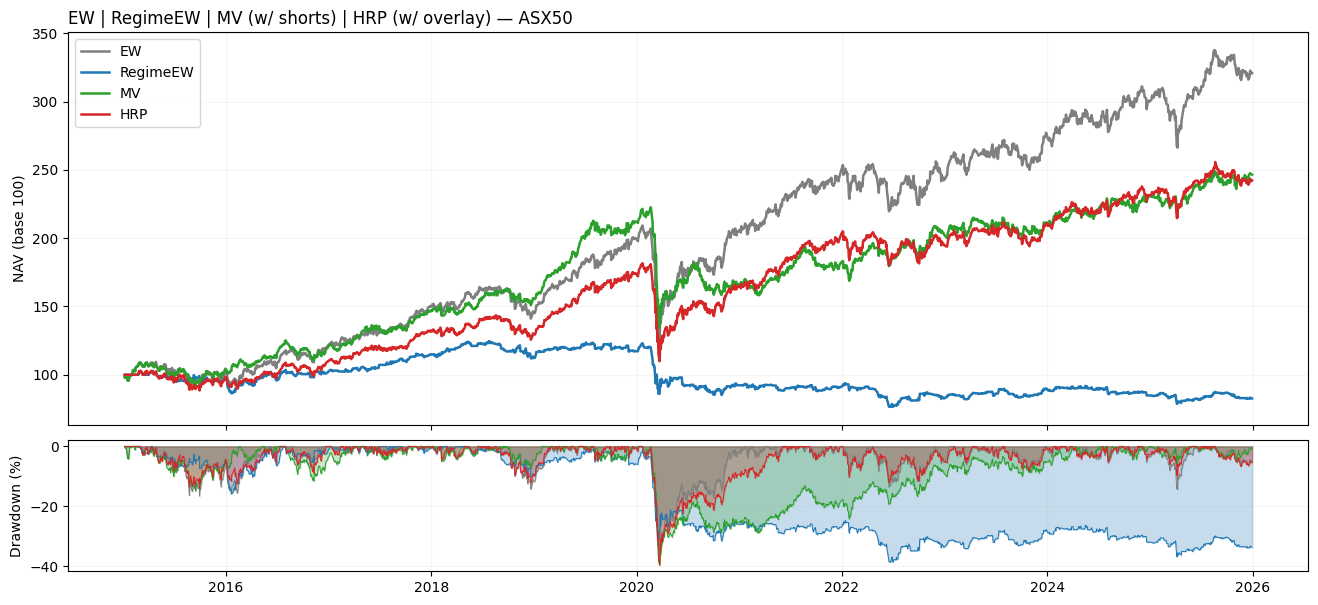


  EUROSTOXX50
  EW … ✓
  RegimeEW … ✓
  MV … 

In [ ]:
import argparse
import warnings
from pathlib import Path
import requests # Added import
from io import StringIO # Added import

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.optimize import minimize
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ============================================================
# 0.  CONFIGURATION
# ============================================================

# DEFAULT_DATA_DIR = Path("/mnt/user-data/uploads") # Removed as data is loaded from GitHub

FILE_MAP = {
    "ASX50":       "streamlined_asx_50.csv",
    "EUROSTOXX50": "streamlined_euro_stoxx_50.csv",
    "FTSE100":     "streamlined_ftse_100.csv",
    "IBOVESPA":    "streamlined_ibovespa.csv",
    "JSE40":       "streamlined_jse_top_40.csv",
    "MACRO":       "streamlined_macro.csv",
    "NIKKEI225":   "streamlined_nikkei_225.csv",
    "SP500":       "streamlined_s&p_500.csv", # Corrected filename
}

FX_COLS   = ["AUDUSD", "BRLUSD", "EURUSD", "GBPUSD", "JPYUSD", "ZARUSD"]
BOND_KW   = "_10Y"
RISK_COLS = ["Bitcoin", "Oil", "Gold", "VIX"]

# Short-selling parameters
SIGNAL_WINDOW     = 28          # rolling window for determinant
EMA_SPAN          = 5           # smoothing span before acting on signal
SHORT_SIGMA       = 2.0         # how many σ below mean to trigger short
BORROW_RATE_BPS   = 50          # annual borrow cost on short positions (bps)
HALF_SPREAD_BPS   = 3           # one-way transaction cost per unit of turnover
MAX_GROSS         = 1.30        # gross exposure cap: Σ|w| ≤ MAX_GROSS
SHORT_OVERLAY_W   = -0.10       # HRP short overlay weight per asset when triggered
COLORS = {"EW": "#7f7f7f", "RegimeEW": "#1f77b4", "MV": "#2ca02c", "HRP": "#d62728"}

# ============================================================
# 1.  DATA LOADING
# ============================================================

def load_data() -> dict[str, pd.DataFrame]: # Modified signature: removed data_dir
    """Load all index CSVs from GitHub into a dict keyed by index name."""
    base_url = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"
    all_data = {}
    for key, fname in FILE_MAP.items():
        url = base_url + fname
        try:
            response = requests.get(url)
            response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
            df = pd.read_csv(StringIO(response.text), index_col=0, parse_dates=True)
            # Clean column names as done in other cells for consistency
            df.columns = df.columns.str.replace('[^a-zA-Z0-9]', '_', regex=True)
            all_data[key] = df
            print(f"  ✅ {key:15s}  {df.shape}  "
                  f"{df.index[0].date()} → {df.index[-1].date()}")
        except Exception as e:
            print(f"  ❌ Error loading {fname}: {str(e)}")
            continue
    if not all_data:
        raise ValueError("No data files could be loaded from GitHub.")
    return all_data


def build_asset_groups(macro: pd.DataFrame) -> dict:
    cols  = list(macro.columns)
    bonds = [c for c in cols if BOND_KW in c]
    fx    = [c for c in FX_COLS if c in cols]
    risk  = [c for c in RISK_COLS if c in cols]
    groups = {}
    if bonds: groups["Bonds"]        = bonds
    if fx:    groups["FX"]           = fx
    if risk:  groups["Risk Factors"] = risk
    print("\n=== Macro asset groups ===")
    for g, m in groups.items():
        print(f"  {g:15s} ({len(m)}): {m}")
    return groups


# ============================================================
# 2.  HELPERS
# ============================================================

def get_log_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    return np.log(price_df / price_df.shift(1)).dropna(how="all")


def cumulative_wealth(ret: pd.Series, base: float = 100.0) -> pd.Series:
    return base * np.exp(ret.cumsum())


def _cov_shrinkage(returns: pd.DataFrame) -> np.ndarray:
    """Ledoit-Wolf analytic shrinkage toward scaled identity."""
    X = returns.values
    n, p = X.shape
    S  = np.cov(X, rowvar=False)
    mu = np.trace(S) / p
    F  = mu * np.eye(p)
    d2 = np.sum((S - F) ** 2)
    b2 = (1.0 / (n * p)) * np.sum(S ** 2 + F ** 2)
    a  = float(np.clip(b2 / d2, 0.0, 1.0))
    return a * F + (1.0 - a) * S


# ============================================================
# 3.  REGIME SIGNAL  (with -2σ short gate)
# ============================================================

def _modified_det(corr: pd.DataFrame) -> float:
    mat = corr.dropna(axis=0, how="all").dropna(axis=1, how="all").to_numpy()
    if mat.shape[0] < 2:
        return np.nan
    try:
        return float(np.linalg.det(mat - np.eye(mat.shape[0])))
    except np.linalg.LinAlgError:
        return np.nan


def build_det_series(lr: pd.DataFrame, window: int = SIGNAL_WINDOW) -> pd.Series:
    """Rolling modified determinant across the full return history."""
    det = pd.Series(dtype=float, index=lr.index)
    for i in range(window, len(lr)):
        det.iloc[i] = _modified_det(lr.iloc[i - window:i].corr(method="spearman"))
    return det.dropna()


def build_signal(det: pd.Series,
                 ema_span: int    = EMA_SPAN,
                 n_sigma:  float  = SHORT_SIGMA) -> pd.DataFrame:
    """
    Returns a DataFrame with columns:
      det_raw   — raw rolling determinant
      det_ema   — EMA-smoothed determinant
      threshold — rolling -n_sigma level (expanding std)
      long_sig  — 1 if risk-on, 0 if neutral/flat
      short_sig — 1 if short eligible (det_ema < -n_sigma AND confirmed)
    """
    det_ema   = det.ewm(span=ema_span, adjust=False).mean()
    roll_mean = det.expanding().mean()
    roll_std  = det.expanding().std().fillna(det.std())
    threshold = roll_mean - n_sigma * roll_std

    long_sig  = (det > 0).astype(int)              # original binary signal
    short_sig = (det_ema < threshold).astype(int)  # new: only fires ~2% of days

    return pd.DataFrame({
        "det_raw":   det,
        "det_ema":   det_ema,
        "threshold": threshold,
        "long_sig":  long_sig,
        "short_sig": short_sig,
    })


# ============================================================
# 4.  TRANSACTION COST HELPERS
# ============================================================

def _turnover_cost(w_new: np.ndarray, w_old: np.ndarray,
                   half_spread_bps: float = HALF_SPREAD_BPS) -> float:
    """One-way cost of rebalancing from w_old to w_new (as daily return drag)."""
    return np.sum(np.abs(w_new - w_old)) * (half_spread_bps / 10_000)


def _daily_borrow_cost(w: np.ndarray,
                       borrow_rate_bps: float = BORROW_RATE_BPS) -> float:
    """Daily borrow cost on short legs (annualised rate / 252)."""
    short_exposure = np.sum(np.maximum(0.0, -w))
    return short_exposure * (borrow_rate_bps / 10_000) / 252


# ============================================================
# 5.  PORTFOLIO STRATEGIES
# ============================================================

# ---- 5a. EW (baseline, long-only) ----
def ew_portfolio(price_df: pd.DataFrame) -> pd.Series:
    ret = get_log_returns(price_df).mean(axis=1)
    ret.name = "EW"
    return ret


# ---- 5b. RegimeEW  (extended exposure: -0.5 / 0 / 0.5 / 1) ----
def regime_ew_portfolio(
    price_df: pd.DataFrame,
    signal_window: int   = SIGNAL_WINDOW,
    ema_span: int        = EMA_SPAN,
    n_sigma: float       = SHORT_SIGMA,
    half_spread_bps: float = HALF_SPREAD_BPS,
    borrow_rate_bps: float = BORROW_RATE_BPS,
) -> pd.Series:
    """
    Exposure scale: {-0.5, 0, 0.5, 1}
      1.0  — det > 0             (risk-on, fully invested)
      0.5  — det = 0 (neutral)   (half-invested)
      0.0  — det < 0 but > -2σ  (flat, no position)
      -0.5 — det_ema < -2σ      (net short, low turnover)
    Costs: turnover + borrow deducted each rebalance / day.
    """
    lr = get_log_returns(price_df)
    n  = lr.shape[1]
    w  = np.ones(n) / n
    rebal = lr.resample("ME").last().index

    det  = build_det_series(lr, signal_window)
    sigs = build_signal(det, ema_span, n_sigma)

    out  = pd.Series(dtype=float, index=lr.index)
    exposure, reb_idx = 0.5, 0

    for date in lr.index:
        if date not in sigs.index:
            out.loc[date] = 0.0
            continue

        # Rebalance monthly
        if reb_idx < len(rebal) and date >= rebal[reb_idx]:
            reb_idx += 1

        row = sigs.loc[date]
        if row["short_sig"] == 1:
            new_exposure = -0.5
        elif row["det_raw"] > 0:
            new_exposure = 1.0
        elif row["det_raw"] == 0:
            new_exposure = 0.5
        else:
            new_exposure = 0.0

        gross_ret = (w @ lr.loc[date].values) * new_exposure
        tc  = _turnover_cost(
            np.full(n, new_exposure / n),
            np.full(n, exposure / n),
            half_spread_bps,
        ) if new_exposure != exposure else 0.0
        borrow = _daily_borrow_cost(
            np.full(n, new_exposure / n), borrow_rate_bps
        )
        out.loc[date] = gross_ret - tc - borrow
        exposure = new_exposure

    out = out.dropna()
    out.name = "RegimeEW"
    return out


# ---- 5c. MV  (allows negative weights, gross cap, borrow cost) ----
def mv_portfolio(
    price_df: pd.DataFrame,
    lookback: int          = 126,
    min_w: float           = -0.25,   # allow shorts up to -25%
    max_w: float           = 0.40,
    max_gross: float       = MAX_GROSS,
    half_spread_bps: float = HALF_SPREAD_BPS,
    borrow_rate_bps: float = BORROW_RATE_BPS,
) -> pd.Series:
    """
    Monthly-rebalanced minimum-variance portfolio.
    Ledoit-Wolf shrinkage cov. Gross exposure constrained: Σ|w| ≤ max_gross.
    Negative weights allowed; borrow cost + turnover deducted daily.
    """
    lr = get_log_returns(price_df)
    n  = lr.shape[1]
    rebal = lr.resample("ME").last().index
    out   = pd.Series(dtype=float, index=lr.index)
    w     = np.ones(n) / n
    reb_idx = 0

    for date in lr.index:
        if reb_idx < len(rebal) and date >= rebal[reb_idx]:
            hist = lr.loc[:date].iloc[-lookback:]
            if hist.shape[0] >= max(n + 5, 30):
                Sigma = _cov_shrinkage(hist)
                w0    = w.copy()

                def portfolio_var(x):
                    return x @ Sigma @ x

                constraints = [
                    {"type": "eq",  "fun": lambda x: x.sum() - 1},
                    {"type": "ineq","fun": lambda x: max_gross - np.sum(np.abs(x))},
                ]
                res = minimize(
                    portfolio_var, w0,
                    method="SLSQP",
                    bounds=[(min_w, max_w)] * n,
                    constraints=constraints,
                    options={"ftol": 1e-12, "maxiter": 2000},
                )
                if res.success:
                    w_new = res.x
                    tc = _turnover_cost(w_new, w, half_spread_bps)
                    w  = w_new
                    out.loc[date] = (w @ lr.loc[date].values) - tc - _daily_borrow_cost(w, borrow_rate_bps)
                    reb_idx += 1
                    continue
            reb_idx += 1

        out.loc[date] = (w @ lr.loc[date].values) - _daily_borrow_cost(w, borrow_rate_bps)

    out = out.dropna()
    out.name = "MV"
    return out


# ---- 5d. HRP  (long-only base + short overlay on -2σ signal) ----
def _hrp_weights(cov: np.ndarray, corr: np.ndarray) -> np.ndarray:
    """López de Prado (2016) recursive bisection."""
    n    = cov.shape[0]
    dist = np.sqrt(np.clip((1.0 - corr) / 2.0, 0, 1))
    np.fill_diagonal(dist, 0)
    link  = linkage(squareform(dist), method="ward")
    order = leaves_list(link)
    weights  = np.ones(n)
    clusters = [list(order)]

    while clusters:
        nxt = []
        for cl in clusters:
            if len(cl) <= 1:
                continue
            mid = len(cl) // 2
            lft, rgt = cl[:mid], cl[mid:]

            def _cv(idx):
                sub  = cov[np.ix_(idx, idx)]
                iv   = 1.0 / np.diag(sub)
                iv  /= iv.sum()
                return float(iv @ sub @ iv)

            a = 1.0 - _cv(lft) / (_cv(lft) + _cv(rgt))
            weights[lft]  *= a
            weights[rgt]  *= (1.0 - a)
            nxt += [lft, rgt]
        clusters = nxt

    return weights / weights.sum()


def hrp_portfolio(
    price_df: pd.DataFrame,
    lookback: int          = 126,
    ema_span: int          = EMA_SPAN,
    n_sigma: float         = SHORT_SIGMA,
    short_overlay_w: float = SHORT_OVERLAY_W,
    half_spread_bps: float = HALF_SPREAD_BPS,
    borrow_rate_bps: float = BORROW_RATE_BPS,
) -> pd.Series:
    """
    Monthly-rebalanced HRP (Ledoit-Wolf cov + Spearman corr).
    Short overlay: when det_ema5 < -2σ, adds `short_overlay_w` to the
    highest-correlation asset (= -10% short on the most contagious index).
    Turnover + borrow cost deducted.
    """
    lr = get_log_returns(price_df)
    n  = lr.shape[1]
    rebal = lr.resample("ME").last().index

    det  = build_det_series(lr, SIGNAL_WINDOW)
    sigs = build_signal(det, ema_span, n_sigma)

    out   = pd.Series(dtype=float, index=lr.index)
    w_base = np.ones(n) / n   # base HRP weights
    w_eff  = w_base.copy()    # effective weights including overlay
    reb_idx = 0

    for date in lr.index:
        if date not in sigs.index:
            out.loc[date] = 0.0
            continue

        # Monthly rebalance: update base HRP weights
        if reb_idx < len(rebal) and date >= rebal[reb_idx]:
            hist = lr.loc[:date].iloc[-lookback:]
            if hist.shape[0] >= max(n + 5, 30):
                Sigma = _cov_shrinkage(hist)
                corr  = hist.corr(method="spearman").to_numpy().copy()
                np.fill_diagonal(corr, 1.0)
                try:
                    w_base = _hrp_weights(Sigma, corr)
                except Exception:
                    pass
            reb_idx += 1

        # Short overlay: on highest-corr asset when signal fires
        w_new = w_base.copy()
        if sigs.loc[date, "short_sig"] == 1:
            # Find asset most correlated with the rest
            hist_30 = lr.loc[:date].iloc[-30:]
            if hist_30.shape[0] >= 10:
                mean_corr = hist_30.corr(method="spearman").mean()
                hot_idx   = int(mean_corr.values.argmax())
                w_new[hot_idx] += short_overlay_w     # e.g. -0.10
                w_new /= np.sum(np.abs(w_new))        # re-normalise gross

        tc     = _turnover_cost(w_new, w_eff, half_spread_bps)
        borrow = _daily_borrow_cost(w_new, borrow_rate_bps)
        gross  = w_new @ lr.loc[date].values
        out.loc[date] = gross - tc - borrow
        w_eff = w_new

    out = out.dropna()
    out.name = "HRP"
    return out


# ============================================================
# 6.  EXTENDED METRICS  (gross + net return, borrow, turnover)
# ============================================================

def perf_metrics(ret: pd.Series, name: str = "Portfolio", rf: float = 0.02) -> dict:
    r = ret.dropna()
    if len(r) == 0:
        return {"Strategy": name}

    td      = 252
    rf_d    = rf / td
    ann_ret = r.mean() * td
    ann_vol = r.std()  * np.sqrt(td)
    sharpe  = (ann_ret - rf) / ann_vol if ann_vol > 0 else np.nan

    down    = r[r < rf_d]
    dd_vol  = down.std() * np.sqrt(td) if len(down) > 1 else np.nan
    sortino = (ann_ret - rf) / dd_vol  if (dd_vol and dd_vol > 0) else np.nan

    wealth  = cumulative_wealth(r)
    roll_mx = wealth.expanding().max()
    max_dd  = ((wealth - roll_mx) / roll_mx).min()
    calmar  = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    var95   = np.percentile(r, 5)
    cvar95  = r[r <= var95].mean() * np.sqrt(td)
    total_r = (wealth.iloc[-1] / wealth.iloc[0] - 1) * 100

    return {
        "Strategy":        name,
        "Ann. Return (%)": round(ann_ret * 100, 2),
        "Ann. Vol (%)":    round(ann_vol * 100, 2),
        "Sharpe":          round(sharpe,  3) if not np.isnan(sharpe)  else np.nan,
        "Sortino":         round(sortino, 3) if not np.isnan(sortino) else np.nan,
        "Calmar":          round(calmar,  3) if not np.isnan(calmar)  else np.nan,
        "Max DD (%)":      round(max_dd  * 100, 2),
        "CVaR 95% (%)":    round(cvar95  * 100, 2),
        "Total Ret. (%)":  round(total_r, 2),
    }


# ============================================================
# 7.  COMPARISON RUNNER + CHART
# ============================================================

def run_index(price_df: pd.DataFrame, label: str) -> tuple:
    print(f"  EW …",        end=" ", flush=True); ew  = ew_portfolio(price_df);         print("✓")
    print(f"  RegimeEW …",  end=" ", flush=True); re  = regime_ew_portfolio(price_df);  print("✓")
    print(f"  MV …",        end=" ", flush=True); mv  = mv_portfolio(price_df);          print("✓")
    print(f"  HRP …",       end=" ", flush=True); hrp = hrp_portfolio(price_df);         print("✓")

    strats = {"EW": ew, "RegimeEW": re, "MV": mv, "HRP": hrp}
    rows   = [perf_metrics(r, f"{label} — {n}") for n, r in strats.items()]
    return pd.DataFrame(rows).set_index("Strategy"), strats


def plot_index(strats: dict, label: str):
    fig = plt.figure(figsize=(16, 7))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.06)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    for name, ret in strats.items():
        w   = cumulative_wealth(ret)
        dd  = (w - w.expanding().max()) / w.expanding().max() * 100
        c   = COLORS[name]
        ax1.plot(w,  label=name, color=c, linewidth=1.8)
        ax2.fill_between(dd.index, dd, 0, alpha=0.25, color=c)
        ax2.plot(dd, linewidth=0.7, color=c)

    ax1.set_ylabel("NAV (base 100)")
    ax1.set_title(f"EW | RegimeEW | MV (w/ shorts) | HRP (w/ overlay) — {label}",
                  loc="left")
    ax1.legend(); ax1.grid(True, alpha=0.12)
    plt.setp(ax1.get_xticklabels(), visible=False)
    ax2.set_ylabel("Drawdown (%)"); ax2.grid(True, alpha=0.12)
    plt.tight_layout()
    out_path = Path("/mnt/user-data/outputs") / f"chart_{label}.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=130, bbox_inches="tight")
    plt.show(); plt.close()


# ============================================================
# 8.  GOOGLE DRIVE UPLOAD  (optional)
# ============================================================

def upload_to_google_drive(file_path: str, folder_id: str = None):
    """
    Upload a local file to Google Drive.

    One-time setup — choose ONE method:

    Method A (service account, best for scripts):
      1. console.cloud.google.com → IAM → Service Accounts → create → download JSON key
      2. Save key as  ~/gdrive_service_account.json
      3. Share your Drive folder with the service-account email
      Set env var: GDRIVE_SERVICE_ACCOUNT=/path/to/key.json  (optional override)

    Method B (personal OAuth2):
      pip install google-auth-oauthlib
      Run the OAuth2 flow once → generates token.json in the script directory.

    Then run:
      python regime_patch.py --drive-folder <FOLDER_ID>
      Folder ID = last segment of: drive.google.com/drive/folders/<FOLDER_ID>
    """
    try:
        from googleapiclient.discovery import build
        from googleapiclient.http import MediaFileUpload
        from google.oauth2 import service_account
        from google.oauth2.credentials import Credentials
    except ImportError:
        print("\n⚠️  Run: pip install google-api-python-client google-auth")
        return

    import os, mimetypes

    SCOPES   = ["https://www.googleapis.com/auth/drive.file"]
    creds    = None
    sa_path  = os.environ.get(
        "GDRIVE_SERVICE_ACCOUNT",
        str(Path.home() / "gdrive_service_account.json"),
    )

    if Path(sa_path).exists():
        creds = service_account.Credentials.from_service_account_file(sa_path, scopes=SCOPES)
        print(f"  🔑 Service account: {sa_path}")
    elif Path("token.json").exists():
        creds = Credentials.from_authorized_user_file("token.json", SCOPES)
        print("  🔑 OAuth2 token: token.json")
    else:
        print("\n⚠️  No Google credentials found. See docstring for setup.")
        return

    service   = build("drive", "v3", credentials=creds)
    file_path = Path(file_path)
    mime, _   = mimetypes.guess_type(str(file_path))
    mime      = mime or "application/octet-stream"
    meta      = {"name": file_path.name}
    if folder_id:
        meta["parents"] = [folder_id]

    uploaded = (
        service.files()
        .create(body=meta,
                media_body=MediaFileUpload(str(file_path), mimetype=mime, resumable=True),
                fields="id,name,webViewLink")
        .execute()
    )
    print(f"  ✅ {uploaded['name']}  →  {uploaded.get('webViewLink','n/a')}")
    return uploaded


def upload_outputs_to_drive(folder_id: str = None):
    outputs = [
        "/mnt/user-data/outputs/strategy_comparison.csv",
        "/mnt/user-data/outputs/04_RegimeModels_Patched.ipynb",
    ]
    for f in outputs:
        if Path(f).exists():
            upload_to_google_drive(f, folder_id=folder_id)
        else:
            print(f"  ⚠️  Not found, skipping: {f}")


# ============================================================
# 9.  MAIN
# ============================================================

def main(only_index: str = None) -> pd.DataFrame: # Modified signature: removed data_dir
    print("Loading data …")
    all_data = load_data() # Modified call: no data_dir argument
    # Check if 'MACRO' data was successfully loaded before accessing it
    if "MACRO" in all_data:
        build_asset_groups(all_data["MACRO"])
    else:
        print("\n⚠️  MACRO data not available, skipping asset group analysis.")

    equity = {k: v for k, v in all_data.items() if k != "MACRO"}
    if only_index:
        equity = {k: v for k, v in equity.items() if k == only_index.upper()}
        if not equity:
            raise ValueError(f"Unknown index: {only_index}. Valid: {list(all_data)}")

    all_metrics = []
    for idx_name, price_df in equity.items():
        print(f"\n{'='*60}\n  {idx_name}")
        mdf, strats = run_index(price_df, idx_name)
        all_metrics.append(mdf)
        plot_index(strats, idx_name)

    summary = pd.concat(all_metrics)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 160)
    pd.set_option("display.float_format", "{:.2f}".format)
    print("\n" + "=" * 90)
    print("FULL PERFORMANCE SUMMARY (net of transaction + borrow costs)")
    print("=" * 90)
    print(summary.to_string())

    out = Path("/mnt/user-data/outputs/strategy_comparison.csv")
    out.parent.mkdir(parents=True, exist_ok=True)
    summary.to_csv(out)
    print(f"\n✅ Saved → {out}")
    return summary


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    # parser.add_argument("--data-dir",     default=str(DEFAULT_DATA_DIR)) # Removed data-dir argument
    parser.add_argument("--index",        default=None)
    parser.add_argument("--drive-folder", default=None)
    args, unknown = parser.parse_known_args() # Use parse_known_args

    summary = main(only_index=args.index) # Modified call: no data_dir argument

    if args.drive_folder:
        print("\nUploading to Google Drive …")
        upload_outputs_to_drive(args.drive_folder)
    elif (Path.home() / "gdrive_service_account.json").exists() \
         or Path("token.json").exists():
        print("\nCredentials found — uploading …")
        upload_outputs_to_drive()